# 01 — Validation & Scaling (v4, v8)
*Self-contained. Run all cells to regenerate scripts and CSVs. 2026-07-25.*

**Contents:** CRN validation of F1–F6 (30 seeds, baking-order factor, cliff
linearity, IR-mask null correction) and the 4-size scaling study (boundary
tracking, per-neuron slope growth, cost frontier).
Runtimes: validation ~3.5 min, scaling ~3 min (CPU).
Key findings: F1(rev), F2(retracted-pending), F7, F8, F9 — see 10_findings_v2.md.

In [ ]:
%%writefile validation_v4.py
"""
validation_v4.py — validation & mechanism sweep for the partial-baking study.

Changes vs v1 (all methodological, same physics/noise models):
 1. COMMON RANDOM NUMBERS. Every (seed, config) draws its fab/programming/
    fine-tune randomness from a SeedSequence spawned deterministically from
    (seed, order, ratio_index). Conditions that should be compared (r_seg
    levels, compensation on/off) therefore see *identical* noise draws and
    differ only in the physics under test. In v1 a single rng was threaded
    through configs in sequence, so every condition got different draws and
    the baseline-vs-IR contrast was unpaired in noise.
 2. 30 seeds (was 5).
 3. Dense ratio grid across the knee (0.86 -> 1.00) plus exact layer
    boundaries, so the cliff location is resolved rather than bracketed.
 4. BAKING ORDER as an experimental factor: forward (L1->L2->L3, v1's
    default), reverse (L3->L2->L1), and random columns across all layers.
    This is the decisive test of *why* the cliff exists:
      - if the cliff is a %-of-weights effect, all three orders cliff at the
        same frozen fraction;
      - if it is an output-layer-coverage effect, reverse order cliffs
        immediately and random order degrades gradually.
 5. Per-sample correctness vectors kept in memory so key contrasts can be
    tested with McNemar (same 629 test images) instead of only across seeds.
"""
import numpy as np, csv, json, time
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

SIGMA_FAB, SIGMA_PROG, N_LEVELS, G_MAX = 0.05, 0.04, 16, 1.0
PROG_OVERHEAD = 2.0
EPOCHS_BASE, EPOCHS_FT, LR = 300, 120, 0.05
SIZES = [64, 48, 24, 10]
LAYER_PARAMS = [SIZES[i] * SIZES[i + 1] for i in range(3)]
TOTAL = sum(LAYER_PARAMS)
N_SEEDS = 30

relu = lambda x: np.maximum(0, x)
def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True)); return e / e.sum(axis=1, keepdims=True)

class MLP:
    def __init__(self, sizes, rng):
        self.W = [rng.normal(0, np.sqrt(2 / sizes[i]), (sizes[i], sizes[i + 1]))
                  for i in range(len(sizes) - 1)]
        self.b = [np.zeros(sizes[i + 1]) for i in range(len(sizes) - 1)]
    def forward(self, X):
        a = [X]
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            z = a[-1] @ W + b
            a.append(relu(z) if i < len(self.W) - 1 else z)
        return a
    def train(self, X, y, epochs, lr, rng, col_masks=None):
        n = len(X)
        for _ in range(epochs):
            idx = rng.permutation(n)
            for s in range(0, n, 32):
                bi = idx[s:s + 32]
                a = self.forward(X[bi]); out = a[-1]
                p = softmax(out); Y = np.eye(p.shape[1])[y[bi]]
                delta = (p - Y) / len(bi)
                for i in reversed(range(len(self.W))):
                    gW = a[i].T @ delta; gb = delta.sum(axis=0)
                    if col_masks is not None:
                        gW = gW * col_masks[i][None, :]; gb = gb * col_masks[i]
                    if i > 0:
                        delta = (delta @ self.W[i].T) * (a[i] > 0)
                    self.W[i] -= lr * gW; self.b[i] -= lr * gb
    def correct(self, X, y):
        return self.forward(X)[-1].argmax(axis=1) == y

def ir_mask(shape, r_seg):
    M, N = shape
    i = np.arange(M)[:, None]; j = np.arange(N)[None, :]
    return r_seg * ((j + 1) + (M - i))

def to_pair(W):
    s = np.abs(W).max() + 1e-12
    return np.clip(W, 0, None) / s * G_MAX, np.clip(-W, 0, None) / s * G_MAX, s

def from_pair(Gp, Gn, scale, R):
    return (Gp / (1 + Gp * R) - Gn / (1 + Gn * R)) * scale / G_MAX

def bake_cols(W, cols, rng, r_seg, comp):
    Gp, Gn, scale = to_pair(W); R = ir_mask(W.shape, r_seg)
    op, on = Gp.copy(), Gn.copy()
    for G, O in ((Gp, op), (Gn, on)):
        tgt = G[:, cols]
        if comp and r_seg > 0:
            tgt = np.clip(tgt / np.maximum(1 - tgt * R[:, cols], 1e-6), 0, G_MAX)
        O[:, cols] = tgt * (1 + rng.normal(0, SIGMA_FAB, tgt.shape))
    return op, on, scale

def program_cols(Gp, Gn, cols, W_new, scale, rng, r_seg, comp):
    Np = np.clip(W_new, 0, None) / scale * G_MAX
    Nn = np.clip(-W_new, 0, None) / scale * G_MAX
    R = ir_mask(W_new.shape, r_seg); step = G_MAX / (N_LEVELS - 1)
    for tgt_all, O in ((Np, Gp), (Nn, Gn)):
        tgt = tgt_all[:, cols]
        if comp and r_seg > 0:
            tgt = np.clip(tgt / np.maximum(1 - tgt * R[:, cols], 1e-6), 0, G_MAX)
        q = np.round(tgt / step) * step
        O[:, cols] = np.clip(q + rng.normal(0, SIGMA_PROG * G_MAX, q.shape), 0, G_MAX)
    return Gp, Gn

# ---------- column selection: the experimental factor ----------
def plan_columns(frac, order, rng):
    """Return per-layer boolean arrays: True = BAKED (frozen)."""
    masks = [np.zeros(SIZES[i + 1], dtype=bool) for i in range(3)]
    target = int(round(frac * TOTAL))
    if order == "random":
        cols = [(i, c) for i in range(3) for c in range(SIZES[i + 1])]
        cols = [cols[k] for k in rng.permutation(len(cols))]
    elif order == "forward":
        cols = [(i, c) for i in range(3) for c in range(SIZES[i + 1])]
    elif order == "reverse":
        cols = [(i, c) for i in (2, 1, 0) for c in range(SIZES[i + 1])]
    else:
        raise ValueError(order)
    got = 0
    for (i, c) in cols:
        if got >= target:
            break
        masks[i][c] = True; got += SIZES[i]
    return masks, got

def run_config(base, data, frac, order, r_seg, comp, ss):
    """ss: SeedSequence keyed on (seed, order, ratio) — NOT on r_seg/comp,
    so IR conditions are compared under identical noise draws (CRN)."""
    Xtr, Xte, ytr, yte, Xte_s, Xad, yad = data
    rng_cols = np.random.default_rng(ss.spawn(1)[0])
    rng_dev = np.random.default_rng(ss.spawn(1)[0])
    rng_ft = np.random.default_rng(ss.spawn(1)[0])

    baked_masks, n_baked = plan_columns(frac, order, rng_cols)
    n_prog = TOTAL - n_baked
    m = MLP(SIZES, np.random.default_rng(0))
    m.b = [b.copy() for b in base.b]
    Gs, scales, train_masks = [], [], []
    for i in range(3):
        cb = baked_masks[i]
        Gp, Gn, sc = bake_cols(base.W[i], cb, rng_dev, r_seg, comp)
        Gp, Gn = program_cols(Gp, Gn, ~cb, base.W[i], sc, rng_dev, r_seg, comp)
        Gs.append((Gp, Gn)); scales.append(sc); train_masks.append(~cb)
        m.W[i] = from_pair(Gp, Gn, sc, ir_mask(base.W[i].shape, r_seg))
    c_clean = m.correct(Xte, yte); c_pre = m.correct(Xte_s, yte)
    if n_prog > 0:
        m.train(Xad, yad, EPOCHS_FT, LR, rng_ft, col_masks=train_masks)
        for i in range(3):
            if train_masks[i].any():
                Gp, Gn = program_cols(*Gs[i], train_masks[i], m.W[i], scales[i],
                                      rng_dev, r_seg, comp)
                m.W[i] = from_pair(Gp, Gn, scales[i], ir_mask(m.W[i].shape, r_seg))
    c_post = m.correct(Xte_s, yte)
    return dict(frozen_frac=round(n_baked / TOTAL, 4), n_baked=n_baked,
                n_prog=n_prog, device_cost=2 * n_baked + 2 * n_prog * (1 + PROG_OVERHEAD),
                acc_clean=round(c_clean.mean(), 4), acc_shift_pre=round(c_pre.mean(), 4),
                acc_shift_post=round(c_post.mean(), 4)), c_post

def shift(X, rng):
    im = X.reshape(-1, 8, 8); im = np.roll(im, 1, axis=2); im[:, :, 0] = 0
    im = im + rng.normal(0, 0.10, im.shape)
    return np.clip(im, 0, 1).reshape(len(X), -1)

RATIOS = [0.0, 0.15, 0.30, 0.45, 0.60, 0.688, 0.75, 0.80, 0.85, 0.86, 0.88,
          0.90, 0.92, 0.9462, 0.955, 0.9677, 0.975, 0.9785, 0.9892, 1.0]
IR_GRID = [(1e-4, True), (1e-3, True), (1e-3, False)]
IR_RATIOS = [0.0, 0.688, 0.9462]

if __name__ == "__main__":
    X, y = load_digits(return_X_y=True)
    Xtr, Xte, ytr, yte = train_test_split(X / 16.0, y, test_size=0.35,
                                          random_state=42, stratify=y)
    rows, post_vecs = [], {}
    t0 = time.time()
    for seed in range(N_SEEDS):
        root = np.random.SeedSequence(seed)
        rb = np.random.default_rng(root.spawn(1)[0])
        Xte_s = shift(Xte, np.random.default_rng(1000 + seed))
        Xad_f = shift(Xtr, np.random.default_rng(1000 + seed))
        ad = rb.choice(len(Xad_f), 200, replace=False)
        data = (Xtr, Xte, ytr, yte, Xte_s, Xad_f[ad], ytr[ad])
        base = MLP(SIZES, rb); base.train(Xtr, ytr, EPOCHS_BASE, LR, rb)
        for order in ("forward", "reverse", "random"):
            for k, f in enumerate(RATIOS):
                ss = np.random.SeedSequence([seed, hash(order) % 10**6, k])
                r, cv = run_config(base, data, f, order, 0.0, True, ss)
                r.update(kind="ratio", order=order, seed=seed, r_seg=0.0, comp=True)
                rows.append(r)
                if order == "forward":
                    post_vecs[(seed, f)] = cv.astype(np.uint8)
        for (rs, cp) in IR_GRID:
            for k, f in enumerate(IR_RATIOS):
                kk = RATIOS.index(f)
                ss = np.random.SeedSequence([seed, hash("forward") % 10**6, kk])
                r, _ = run_config(base, data, f, "forward", rs, cp, ss)
                r.update(kind="ir", order="forward", seed=seed, r_seg=rs, comp=cp)
                rows.append(r)
        if seed % 5 == 0:
            print(f"seed {seed} done, {len(rows)} rows, {time.time()-t0:.0f}s", flush=True)
    with open("results_v4.csv", "w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)
    np.savez_compressed("post_vectors_v4.npz",
                        **{f"{s}_{f}": v for (s, f), v in post_vecs.items()},
                        yte=yte)
    print("saved results_v4.csv,", len(rows), "rows,", f"{time.time()-t0:.0f}s")


In [ ]:
%%writefile scaling_study_v8.py
"""
scaling_study_v8.py — does partial baking get better or worse as the model grows?

4 model sizes on the same task (digits, forward baking order, v4 protocol,
CRN seeds). The v4 mechanism predicts:
  - the cliff sits at the OUTPUT-LAYER BOUNDARY, so its %-location moves
    right as models grow (L3 becomes a smaller fraction of total);
  - curves should collapse when plotted vs tunable output neurons.
Sizes (hidden dims): A(24,12) B(48,24)=v1 C(96,48) D(192,96).
"""
import numpy as np, csv, time
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

SIGMA_FAB, SIGMA_PROG, N_LEVELS, G_MAX, PROG_OVERHEAD = 0.05, 0.04, 16, 1.0, 2.0
EPOCHS_BASE, EPOCHS_FT, LR = 300, 120, 0.05
N_SEEDS = 8
SIZES_GRID = {"A": [64, 24, 12, 10], "B": [64, 48, 24, 10],
              "C": [64, 96, 48, 10], "D": [64, 192, 96, 10]}
relu = lambda x: np.maximum(0, x)
def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True)); return e / e.sum(axis=1, keepdims=True)

class MLP:
    def __init__(s, sizes, rng):
        s.sizes = sizes
        s.W = [rng.normal(0, np.sqrt(2 / sizes[i]), (sizes[i], sizes[i + 1]))
               for i in range(len(sizes) - 1)]
        s.b = [np.zeros(sizes[i + 1]) for i in range(len(sizes) - 1)]
    def forward(s, X):
        a = [X]
        for i, (W, b) in enumerate(zip(s.W, s.b)):
            z = a[-1] @ W + b
            a.append(relu(z) if i < len(s.W) - 1 else z)
        return a
    def train(s, X, y, ep, lr, rng, col_masks=None):
        n = len(X)
        for _ in range(ep):
            idx = rng.permutation(n)
            for st in range(0, n, 32):
                bi = idx[st:st + 32]
                a = s.forward(X[bi]); p = softmax(a[-1])
                delta = (p - np.eye(p.shape[1])[y[bi]]) / len(bi)
                for i in reversed(range(len(s.W))):
                    gW = a[i].T @ delta; gb = delta.sum(0)
                    if col_masks is not None:
                        gW *= col_masks[i][None, :]; gb *= col_masks[i]
                    if i > 0:
                        delta = (delta @ s.W[i].T) * (a[i] > 0)
                    s.W[i] -= lr * gW; s.b[i] -= lr * gb
    def acc(s, X, y): return (s.forward(X)[-1].argmax(1) == y).mean()

def noise_dev(W, rng, prog):
    if W.size == 0:
        return W
    if not prog:
        return W * (1 + rng.normal(0, SIGMA_FAB, W.shape))
    sc = np.abs(W).max() + 1e-12; st = G_MAX / (N_LEVELS - 1)
    q = lambda G: np.clip(np.round(G / st) * st + rng.normal(0, SIGMA_PROG, G.shape), 0, G_MAX)
    return (q(np.clip(W, 0, None) / sc) - q(np.clip(-W, 0, None) / sc)) * sc

def run(base, sizes, data, frac, ss):
    Xtr, Xte, ytr, yte, Xte_s, Xad, yad = data
    rng_d = np.random.default_rng(ss.spawn(1)[0])
    rng_f = np.random.default_rng(ss.spawn(1)[0])
    L = [sizes[i] * sizes[i + 1] for i in range(3)]; TOT = sum(L)
    target = int(round(frac * TOT)); plan = []
    for i in range(3):
        k = min(sizes[i + 1], int(round(min(target, L[i]) / sizes[i])))
        plan.append(k); target = max(0, target - k * sizes[i])
    m = MLP(sizes, np.random.default_rng(0)); m.b = [b.copy() for b in base.b]
    masks = []
    for i in range(3):
        cb = np.arange(sizes[i + 1]) < plan[i]
        W = base.W[i].copy()
        W[:, cb] = noise_dev(W[:, cb], rng_d, False)
        W[:, ~cb] = noise_dev(W[:, ~cb], rng_d, True)
        m.W[i] = W; masks.append(~cb)
    n_baked = sum(plan[i] * sizes[i] for i in range(3)); n_prog = TOT - n_baked
    if n_prog > 0:
        m.train(Xad, yad, EPOCHS_FT, LR, rng_f, col_masks=masks)
        for i in range(3):
            if masks[i].any():
                m.W[i][:, masks[i]] = noise_dev(m.W[i][:, masks[i]], rng_d, True)
    return dict(frozen_frac=round(n_baked / TOT, 4), n_baked=n_baked, n_prog=n_prog,
                device_cost=2 * n_baked + 2 * n_prog * (1 + PROG_OVERHEAD),
                acc_clean=round(m.acc(Xte, yte), 4),
                acc_shift_post=round(m.acc(Xte_s, yte), 4))

def shift(X, rng):
    im = X.reshape(-1, 8, 8); im = np.roll(im, 1, 2); im[:, :, 0] = 0
    return np.clip(im + rng.normal(0, 0.10, im.shape), 0, 1).reshape(len(X), -1)

if __name__ == "__main__":
    X, y = load_digits(return_X_y=True)
    Xtr, Xte, ytr, yte = train_test_split(X / 16.0, y, test_size=0.35,
                                          random_state=42, stratify=y)
    BASE_R = [0.0, 0.30, 0.60, 0.75, 0.85, 0.90, 0.92, 0.95, 0.97, 0.99, 1.0]
    rows = []; t0 = time.time()
    for tag, sizes in SIZES_GRID.items():
        L = [sizes[i] * sizes[i + 1] for i in range(3)]; TOT = sum(L)
        b23 = 1 - L[2] / TOT           # output-layer boundary
        # dense grid across [b23, 1]
        dense = list(np.linspace(b23 - 0.02, 1.0, 8))
        RATIOS = sorted(set([round(r, 4) for r in BASE_R + dense + [b23]]))
        for seed in range(N_SEEDS):
            root = np.random.SeedSequence([seed, 77])
            rb = np.random.default_rng(root.spawn(1)[0])
            Xte_s = shift(Xte, np.random.default_rng(1000 + seed))
            Xad_f = shift(Xtr, np.random.default_rng(1000 + seed))
            ad = rb.choice(len(Xad_f), 200, replace=False)
            data = (Xtr, Xte, ytr, yte, Xte_s, Xad_f[ad], ytr[ad])
            base = MLP(sizes, rb); base.train(Xtr, ytr, EPOCHS_BASE, LR, rb)
            for k, f in enumerate(RATIOS):
                ss = np.random.SeedSequence([seed, ord(tag), k])
                r = run(base, sizes, data, f, ss)
                r.update(size=tag, seed=seed, total=TOT, h2=sizes[2], b23=round(b23, 4))
                rows.append(r)
            print(f"{tag} seed {seed} {time.time()-t0:.0f}s", flush=True)
    with open("results_v8_scaling.csv", "w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=list(rows[0].keys()))
        w.writeheader(); w.writerows(rows)
    print("saved", len(rows), "rows", f"{time.time()-t0:.0f}s")


## Data (regenerated by scripts above; snapshots below for immediate analysis)

In [ ]:
%%writefile results_v4.csv
frozen_frac,n_baked,n_prog,device_cost,acc_clean,acc_shift_pre,acc_shift_post,kind,order,seed,r_seg,comp
0.0,0,4464,26784.0,0.9316,0.4165,0.8585,ratio,forward,0,0.0,True
0.1577,704,3760,23968.0,0.9539,0.4277,0.8649,ratio,forward,0,0.0,True
0.3011,1344,3120,21408.0,0.9157,0.4452,0.8172,ratio,forward,0,0.0,True
0.4588,2048,2416,18592.0,0.9555,0.4134,0.8569,ratio,forward,0,0.0,True
0.6022,2688,1776,16032.0,0.9348,0.4356,0.8585,ratio,forward,0,0.0,True
0.6882,3072,1392,14496.0,0.9459,0.4261,0.8235,ratio,forward,0,0.0,True
0.7527,3360,1104,13344.0,0.9555,0.4006,0.8219,ratio,forward,0,0.0,True
0.8065,3600,864,12384.0,0.9666,0.4452,0.8299,ratio,forward,0,0.0,True
0.8602,3840,624,11424.0,0.9634,0.4102,0.8124,ratio,forward,0,0.0,True
0.8602,3840,624,11424.0,0.9555,0.4118,0.8235,ratio,forward,0,0.0,True
0.8817,3936,528,11040.0,0.9507,0.399,0.7838,ratio,forward,0,0.0,True
0.9032,4032,432,10656.0,0.9507,0.442,0.7886,ratio,forward,0,0.0,True
0.9247,4128,336,10272.0,0.9475,0.4245,0.8013,ratio,forward,0,0.0,True
0.9462,4224,240,9888.0,0.9412,0.3831,0.7901,ratio,forward,0,0.0,True
0.957,4272,192,9696.0,0.9459,0.4054,0.6709,ratio,forward,0,0.0,True
0.9677,4320,144,9504.0,0.9571,0.4499,0.5898,ratio,forward,0,0.0,True
0.9785,4368,96,9312.0,0.9618,0.434,0.5405,ratio,forward,0,0.0,True
0.9785,4368,96,9312.0,0.9618,0.4118,0.5231,ratio,forward,0,0.0,True
0.9892,4416,48,9120.0,0.9587,0.3959,0.4324,ratio,forward,0,0.0,True
1.0,4464,0,8928.0,0.9634,0.4213,0.4213,ratio,forward,0,0.0,True
0.0,0,4464,26784.0,0.938,0.337,0.8521,ratio,reverse,0,0.0,True
0.1505,672,3792,24096.0,0.9444,0.4165,0.868,ratio,reverse,0,0.0,True
0.3011,1344,3120,21408.0,0.9666,0.4483,0.8744,ratio,reverse,0,0.0,True
0.4552,2032,2432,18656.0,0.9634,0.4452,0.8569,ratio,reverse,0,0.0,True
0.6129,2736,1728,15840.0,0.9666,0.4165,0.8506,ratio,reverse,0,0.0,True
0.6989,3120,1344,14304.0,0.9618,0.4197,0.8203,ratio,reverse,0,0.0,True
0.7563,3376,1088,13280.0,0.9539,0.4181,0.8188,ratio,reverse,0,0.0,True
0.8136,3632,832,12256.0,0.9555,0.4006,0.7949,ratio,reverse,0,0.0,True
0.8566,3824,640,11488.0,0.9666,0.4149,0.7647,ratio,reverse,0,0.0,True
0.871,3888,576,11232.0,0.9698,0.4277,0.7568,ratio,reverse,0,0.0,True
0.8853,3952,512,10976.0,0.9571,0.3847,0.7631,ratio,reverse,0,0.0,True
0.914,4080,384,10464.0,0.965,0.4388,0.682,ratio,reverse,0,0.0,True
0.9283,4144,320,10208.0,0.9634,0.4229,0.6184,ratio,reverse,0,0.0,True
0.957,4272,192,9696.0,0.9618,0.4165,0.62,ratio,reverse,0,0.0,True
0.957,4272,192,9696.0,0.9682,0.4245,0.6025,ratio,reverse,0,0.0,True
0.9713,4336,128,9440.0,0.9603,0.4372,0.5723,ratio,reverse,0,0.0,True
0.9857,4400,64,9184.0,0.9618,0.4213,0.4595,ratio,reverse,0,0.0,True
0.9857,4400,64,9184.0,0.965,0.4181,0.4499,ratio,reverse,0,0.0,True
1.0,4464,0,8928.0,0.9666,0.4499,0.4499,ratio,reverse,0,0.0,True
1.0,4464,0,8928.0,0.9618,0.4118,0.4118,ratio,reverse,0,0.0,True
0.0,0,4464,26784.0,0.9062,0.3196,0.8442,ratio,random,0,0.0,True
0.1559,696,3768,24000.0,0.9062,0.3847,0.8537,ratio,random,0,0.0,True
0.3118,1392,3072,21216.0,0.9539,0.4102,0.8617,ratio,random,0,0.0,True
0.4624,2064,2400,18528.0,0.9571,0.4181,0.8649,ratio,random,0,0.0,True
0.6039,2696,1768,16000.0,0.9459,0.4372,0.8569,ratio,random,0,0.0,True
0.6935,3096,1368,14400.0,0.9634,0.4229,0.8506,ratio,random,0,0.0,True
0.7599,3392,1072,13216.0,0.9603,0.4515,0.8331,ratio,random,0,0.0,True
0.8047,3592,872,12416.0,0.965,0.3943,0.7186,ratio,random,0,0.0,True
0.8602,3840,624,11424.0,0.9475,0.4356,0.7583,ratio,random,0,0.0,True
0.8638,3856,608,11360.0,0.965,0.4245,0.7011,ratio,random,0,0.0,True
0.8799,3928,536,11072.0,0.9587,0.4022,0.7122,ratio,random,0,0.0,True
0.9068,4048,416,10592.0,0.9682,0.4308,0.4738,ratio,random,0,0.0,True
0.9265,4136,328,10240.0,0.9587,0.4229,0.5692,ratio,random,0,0.0,True
0.948,4232,232,9856.0,0.965,0.4308,0.5946,ratio,random,0,0.0,True
0.9642,4304,160,9568.0,0.9698,0.4165,0.5278,ratio,random,0,0.0,True
0.9749,4352,112,9376.0,0.965,0.4213,0.4293,ratio,random,0,0.0,True
0.9749,4352,112,9376.0,0.965,0.4277,0.4467,ratio,random,0,0.0,True
0.9857,4400,64,9184.0,0.9682,0.4245,0.4436,ratio,random,0,0.0,True
1.0,4464,0,8928.0,0.9698,0.434,0.434,ratio,random,0,0.0,True
1.0,4464,0,8928.0,0.9698,0.4324,0.4324,ratio,random,0,0.0,True
0.0,0,4464,26784.0,0.9348,0.4054,0.8521,ir,forward,0,0.0001,True
0.6882,3072,1392,14496.0,0.9459,0.434,0.841,ir,forward,0,0.0001,True
0.9462,4224,240,9888.0,0.9396,0.3816,0.7965,ir,forward,0,0.0001,True
0.0,0,4464,26784.0,0.9444,0.4054,0.8506,ir,forward,0,0.001,True
0.6882,3072,1392,14496.0,0.9491,0.4245,0.8235,ir,forward,0,0.001,True
0.9462,4224,240,9888.0,0.9364,0.3752,0.7997,ir,forward,0,0.001,True
0.0,0,4464,26784.0,0.9348,0.4197,0.8585,ir,forward,0,0.001,False
0.6882,3072,1392,14496.0,0.9444,0.4277,0.8235,ir,forward,0,0.001,False
0.9462,4224,240,9888.0,0.938,0.3816,0.7917,ir,forward,0,0.001,False
0.0,0,4464,26784.0,0.9253,0.3959,0.8633,ratio,forward,1,0.0,True
0.1577,704,3760,23968.0,0.9491,0.4165,0.8426,ratio,forward,1,0.0,True
0.3011,1344,3120,21408.0,0.9523,0.4149,0.8569,ratio,forward,1,0.0,True
0.4588,2048,2416,18592.0,0.9412,0.4197,0.841,ratio,forward,1,0.0,True
0.6022,2688,1776,16032.0,0.9507,0.434,0.787,ratio,forward,1,0.0,True
0.6882,3072,1392,14496.0,0.9539,0.4134,0.7854,ratio,forward,1,0.0,True
0.7527,3360,1104,13344.0,0.93,0.4324,0.7965,ratio,forward,1,0.0,True
0.8065,3600,864,12384.0,0.9475,0.3959,0.7615,ratio,forward,1,0.0,True
0.8602,3840,624,11424.0,0.9682,0.4483,0.7059,ratio,forward,1,0.0,True
0.8602,3840,624,11424.0,0.9444,0.3816,0.7568,ratio,forward,1,0.0,True
0.8817,3936,528,11040.0,0.9459,0.4102,0.7822,ratio,forward,1,0.0,True
0.9032,4032,432,10656.0,0.9555,0.4324,0.7504,ratio,forward,1,0.0,True
0.9247,4128,336,10272.0,0.9587,0.4452,0.7599,ratio,forward,1,0.0,True
0.9462,4224,240,9888.0,0.9587,0.442,0.7583,ratio,forward,1,0.0,True
0.957,4272,192,9696.0,0.9634,0.4388,0.6169,ratio,forward,1,0.0,True
0.9677,4320,144,9504.0,0.9603,0.4006,0.6248,ratio,forward,1,0.0,True
0.9785,4368,96,9312.0,0.9634,0.4277,0.4785,ratio,forward,1,0.0,True
0.9785,4368,96,9312.0,0.9634,0.4245,0.5119,ratio,forward,1,0.0,True
0.9892,4416,48,9120.0,0.9523,0.4181,0.4817,ratio,forward,1,0.0,True
1.0,4464,0,8928.0,0.9634,0.4293,0.4293,ratio,forward,1,0.0,True
0.0,0,4464,26784.0,0.9444,0.3959,0.8251,ratio,reverse,1,0.0,True
0.1505,672,3792,24096.0,0.9571,0.4531,0.8299,ratio,reverse,1,0.0,True
0.3011,1344,3120,21408.0,0.9428,0.4022,0.8617,ratio,reverse,1,0.0,True
0.4552,2032,2432,18656.0,0.9539,0.4229,0.849,ratio,reverse,1,0.0,True
0.6129,2736,1728,15840.0,0.9555,0.4213,0.8045,ratio,reverse,1,0.0,True
0.6989,3120,1344,14304.0,0.9571,0.4293,0.7854,ratio,reverse,1,0.0,True
0.7563,3376,1088,13280.0,0.9682,0.4149,0.7711,ratio,reverse,1,0.0,True
0.8136,3632,832,12256.0,0.9698,0.4197,0.7361,ratio,reverse,1,0.0,True
0.8566,3824,640,11488.0,0.9571,0.4547,0.6677,ratio,reverse,1,0.0,True
0.871,3888,576,11232.0,0.9618,0.4404,0.5946,ratio,reverse,1,0.0,True
0.8853,3952,512,10976.0,0.9603,0.4149,0.5644,ratio,reverse,1,0.0,True
0.914,4080,384,10464.0,0.9618,0.4102,0.5183,ratio,reverse,1,0.0,True
0.9283,4144,320,10208.0,0.965,0.4134,0.5167,ratio,reverse,1,0.0,True
0.957,4272,192,9696.0,0.9618,0.4245,0.5183,ratio,reverse,1,0.0,True
0.957,4272,192,9696.0,0.9634,0.4261,0.5167,ratio,reverse,1,0.0,True
0.9713,4336,128,9440.0,0.9603,0.4229,0.4277,ratio,reverse,1,0.0,True
0.9857,4400,64,9184.0,0.9634,0.4197,0.4229,ratio,reverse,1,0.0,True
0.9857,4400,64,9184.0,0.9603,0.407,0.4022,ratio,reverse,1,0.0,True
1.0,4464,0,8928.0,0.9682,0.4245,0.4245,ratio,reverse,1,0.0,True
1.0,4464,0,8928.0,0.9603,0.3943,0.3943,ratio,reverse,1,0.0,True
0.0,0,4464,26784.0,0.938,0.4245,0.8315,ratio,random,1,0.0,True
0.1541,688,3776,24032.0,0.9459,0.4229,0.8617,ratio,random,1,0.0,True
0.3047,1360,3104,21344.0,0.8951,0.4149,0.8299,ratio,random,1,0.0,True
0.4606,2056,2408,18560.0,0.9571,0.3959,0.841,ratio,random,1,0.0,True
0.6093,2720,1744,15904.0,0.9475,0.4086,0.8537,ratio,random,1,0.0,True
0.6918,3088,1376,14432.0,0.9746,0.4261,0.7965,ratio,random,1,0.0,True
0.7545,3368,1096,13312.0,0.9714,0.4102,0.8013,ratio,random,1,0.0,True
0.8029,3584,880,12448.0,0.9555,0.4165,0.7997,ratio,random,1,0.0,True
0.8638,3856,608,11360.0,0.9555,0.4277,0.5898,ratio,random,1,0.0,True
0.8602,3840,624,11424.0,0.9571,0.399,0.7568,ratio,random,1,0.0,True
0.8871,3960,504,10944.0,0.9666,0.4181,0.6375,ratio,random,1,0.0,True
0.9122,4072,392,10496.0,0.9587,0.407,0.5215,ratio,random,1,0.0,True
0.9211,4112,352,10336.0,0.9603,0.4213,0.6614,ratio,random,1,0.0,True
0.9462,4224,240,9888.0,0.9618,0.4261,0.5548,ratio,random,1,0.0,True
0.957,4272,192,9696.0,0.9587,0.4038,0.5008,ratio,random,1,0.0,True
0.9677,4320,144,9504.0,0.9634,0.4197,0.4722,ratio,random,1,0.0,True
0.9785,4368,96,9312.0,0.9603,0.4277,0.4992,ratio,random,1,0.0,True
0.9785,4368,96,9312.0,0.9666,0.4229,0.442,ratio,random,1,0.0,True
0.9892,4416,48,9120.0,0.9618,0.4181,0.4531,ratio,random,1,0.0,True
1.0,4464,0,8928.0,0.965,0.4229,0.4229,ratio,random,1,0.0,True
0.0,0,4464,26784.0,0.9253,0.3959,0.8601,ir,forward,1,0.0001,True
0.6882,3072,1392,14496.0,0.9555,0.407,0.7727,ir,forward,1,0.0001,True
0.9462,4224,240,9888.0,0.9603,0.442,0.7488,ir,forward,1,0.0001,True
0.0,0,4464,26784.0,0.9285,0.3975,0.8506,ir,forward,1,0.001,True
0.6882,3072,1392,14496.0,0.9603,0.4038,0.779,ir,forward,1,0.001,True
0.9462,4224,240,9888.0,0.9507,0.4356,0.7504,ir,forward,1,0.001,True
0.0,0,4464,26784.0,0.9253,0.3975,0.8553,ir,forward,1,0.001,False
0.6882,3072,1392,14496.0,0.9539,0.4181,0.7981,ir,forward,1,0.001,False
0.9462,4224,240,9888.0,0.9571,0.4452,0.7552,ir,forward,1,0.001,False
0.0,0,4464,26784.0,0.9682,0.4483,0.814,ratio,forward,2,0.0,True
0.1577,704,3760,23968.0,0.9618,0.4881,0.8585,ratio,forward,2,0.0,True
0.3011,1344,3120,21408.0,0.9634,0.4642,0.8728,ratio,forward,2,0.0,True
0.4588,2048,2416,18592.0,0.9618,0.4452,0.806,ratio,forward,2,0.0,True
0.6022,2688,1776,16032.0,0.9587,0.4579,0.8362,ratio,forward,2,0.0,True
0.6882,3072,1392,14496.0,0.9539,0.4769,0.8331,ratio,forward,2,0.0,True
0.7527,3360,1104,13344.0,0.9348,0.4229,0.7933,ratio,forward,2,0.0,True
0.8065,3600,864,12384.0,0.9603,0.469,0.7647,ratio,forward,2,0.0,True
0.8602,3840,624,11424.0,0.9618,0.469,0.7965,ratio,forward,2,0.0,True
0.8602,3840,624,11424.0,0.9507,0.4499,0.7949,ratio,forward,2,0.0,True
0.8817,3936,528,11040.0,0.9603,0.4626,0.8092,ratio,forward,2,0.0,True
0.9032,4032,432,10656.0,0.965,0.469,0.752,ratio,forward,2,0.0,True
0.9247,4128,336,10272.0,0.9777,0.4913,0.7615,ratio,forward,2,0.0,True
0.9462,4224,240,9888.0,0.9587,0.4579,0.7122,ratio,forward,2,0.0,True
0.957,4272,192,9696.0,0.9698,0.4801,0.6566,ratio,forward,2,0.0,True
0.9677,4320,144,9504.0,0.9539,0.4849,0.6184,ratio,forward,2,0.0,True
0.9785,4368,96,9312.0,0.9714,0.4849,0.5723,ratio,forward,2,0.0,True
0.9785,4368,96,9312.0,0.965,0.4897,0.5628,ratio,forward,2,0.0,True
0.9892,4416,48,9120.0,0.9634,0.4992,0.496,ratio,forward,2,0.0,True
1.0,4464,0,8928.0,0.9682,0.4754,0.4754,ratio,forward,2,0.0,True
0.0,0,4464,26784.0,0.9412,0.4706,0.8521,ratio,reverse,2,0.0,True
0.1505,672,3792,24096.0,0.9587,0.4452,0.8919,ratio,reverse,2,0.0,True
0.3011,1344,3120,21408.0,0.9666,0.504,0.8919,ratio,reverse,2,0.0,True
0.4552,2032,2432,18656.0,0.9555,0.4865,0.8776,ratio,reverse,2,0.0,True
0.6129,2736,1728,15840.0,0.9714,0.4833,0.8792,ratio,reverse,2,0.0,True
0.6989,3120,1344,14304.0,0.9682,0.4595,0.8744,ratio,reverse,2,0.0,True
0.7563,3376,1088,13280.0,0.965,0.4563,0.8569,ratio,reverse,2,0.0,True
0.8136,3632,832,12256.0,0.9666,0.4801,0.7886,ratio,reverse,2,0.0,True
0.8566,3824,640,11488.0,0.9793,0.4738,0.744,ratio,reverse,2,0.0,True
0.871,3888,576,11232.0,0.9682,0.4833,0.6566,ratio,reverse,2,0.0,True
0.8853,3952,512,10976.0,0.9698,0.5024,0.6804,ratio,reverse,2,0.0,True
0.914,4080,384,10464.0,0.9682,0.4754,0.6296,ratio,reverse,2,0.0,True
0.9283,4144,320,10208.0,0.965,0.4738,0.5771,ratio,reverse,2,0.0,True
0.957,4272,192,9696.0,0.9666,0.4881,0.5453,ratio,reverse,2,0.0,True
0.957,4272,192,9696.0,0.9682,0.4801,0.5326,ratio,reverse,2,0.0,True
0.9713,4336,128,9440.0,0.9666,0.4897,0.5342,ratio,reverse,2,0.0,True
0.9857,4400,64,9184.0,0.9682,0.4865,0.5119,ratio,reverse,2,0.0,True
0.9857,4400,64,9184.0,0.9698,0.469,0.4833,ratio,reverse,2,0.0,True
1.0,4464,0,8928.0,0.9714,0.4595,0.4595,ratio,reverse,2,0.0,True
1.0,4464,0,8928.0,0.9698,0.4706,0.4706,ratio,reverse,2,0.0,True
0.0,0,4464,26784.0,0.9491,0.4658,0.8776,ratio,random,2,0.0,True
0.1595,712,3752,23936.0,0.9523,0.4642,0.8839,ratio,random,2,0.0,True
0.3118,1392,3072,21216.0,0.9587,0.4817,0.8537,ratio,random,2,0.0,True
0.4534,2024,2440,18688.0,0.9571,0.4483,0.8506,ratio,random,2,0.0,True
0.6039,2696,1768,16000.0,0.9682,0.4865,0.868,ratio,random,2,0.0,True
0.6882,3072,1392,14496.0,0.965,0.4738,0.8537,ratio,random,2,0.0,True
0.7545,3368,1096,13312.0,0.9666,0.4754,0.8362,ratio,random,2,0.0,True
0.8047,3592,872,12416.0,0.9587,0.469,0.8426,ratio,random,2,0.0,True
0.8566,3824,640,11488.0,0.965,0.4754,0.7424,ratio,random,2,0.0,True
0.871,3888,576,11232.0,0.9587,0.4642,0.7154,ratio,random,2,0.0,True
0.8853,3952,512,10976.0,0.973,0.4833,0.7393,ratio,random,2,0.0,True
0.9086,4056,408,10560.0,0.965,0.4801,0.6582,ratio,random,2,0.0,True
0.9247,4128,336,10272.0,0.9618,0.4817,0.7075,ratio,random,2,0.0,True
0.9498,4240,224,9824.0,0.9682,0.4833,0.496,ratio,random,2,0.0,True
0.9588,4280,184,9664.0,0.9698,0.4785,0.5978,ratio,random,2,0.0,True
0.9713,4336,128,9440.0,0.9682,0.4944,0.5199,ratio,random,2,0.0,True
0.9839,4392,72,9216.0,0.9555,0.4531,0.5533,ratio,random,2,0.0,True
0.9857,4400,64,9184.0,0.973,0.4976,0.496,ratio,random,2,0.0,True
0.9892,4416,48,9120.0,0.9714,0.4944,0.5437,ratio,random,2,0.0,True
1.0,4464,0,8928.0,0.9682,0.4722,0.4722,ratio,random,2,0.0,True
0.0,0,4464,26784.0,0.9698,0.4436,0.8188,ir,forward,2,0.0001,True
0.6882,3072,1392,14496.0,0.9555,0.4722,0.8347,ir,forward,2,0.0001,True
0.9462,4224,240,9888.0,0.9587,0.4579,0.7091,ir,forward,2,0.0001,True
0.0,0,4464,26784.0,0.9714,0.469,0.8251,ir,forward,2,0.001,True
0.6882,3072,1392,14496.0,0.9507,0.4706,0.841,ir,forward,2,0.001,True
0.9462,4224,240,9888.0,0.9634,0.4595,0.7075,ir,forward,2,0.001,True
0.0,0,4464,26784.0,0.9698,0.4515,0.8188,ir,forward,2,0.001,False
0.6882,3072,1392,14496.0,0.9571,0.4722,0.8299,ir,forward,2,0.001,False
0.9462,4224,240,9888.0,0.9603,0.4642,0.7234,ir,forward,2,0.001,False
0.0,0,4464,26784.0,0.9475,0.461,0.7838,ratio,forward,3,0.0,True
0.1577,704,3760,23968.0,0.9332,0.442,0.7901,ratio,forward,3,0.0,True
0.3011,1344,3120,21408.0,0.9459,0.4499,0.7806,ratio,forward,3,0.0,True
0.4588,2048,2416,18592.0,0.9348,0.4181,0.8013,ratio,forward,3,0.0,True
0.6022,2688,1776,16032.0,0.938,0.4229,0.7727,ratio,forward,3,0.0,True
0.6882,3072,1392,14496.0,0.9555,0.4754,0.7647,ratio,forward,3,0.0,True
0.7527,3360,1104,13344.0,0.9396,0.399,0.7679,ratio,forward,3,0.0,True
0.8065,3600,864,12384.0,0.9507,0.4388,0.7949,ratio,forward,3,0.0,True
0.8602,3840,624,11424.0,0.9507,0.4674,0.7583,ratio,forward,3,0.0,True
0.8602,3840,624,11424.0,0.9428,0.4197,0.7472,ratio,forward,3,0.0,True
0.8817,3936,528,11040.0,0.9428,0.4308,0.6375,ratio,forward,3,0.0,True
0.9032,4032,432,10656.0,0.9507,0.4642,0.7345,ratio,forward,3,0.0,True
0.9247,4128,336,10272.0,0.9555,0.4436,0.7202,ratio,forward,3,0.0,True
0.9462,4224,240,9888.0,0.9587,0.4134,0.6328,ratio,forward,3,0.0,True
0.957,4272,192,9696.0,0.9555,0.4388,0.5835,ratio,forward,3,0.0,True
0.9677,4320,144,9504.0,0.9396,0.4197,0.601,ratio,forward,3,0.0,True
0.9785,4368,96,9312.0,0.9571,0.4515,0.5421,ratio,forward,3,0.0,True
0.9785,4368,96,9312.0,0.9444,0.4769,0.5215,ratio,forward,3,0.0,True
0.9892,4416,48,9120.0,0.9587,0.4515,0.461,ratio,forward,3,0.0,True
1.0,4464,0,8928.0,0.9603,0.4754,0.4754,ratio,forward,3,0.0,True
0.0,0,4464,26784.0,0.9396,0.3975,0.6804,ratio,reverse,3,0.0,True
0.1505,672,3792,24096.0,0.9618,0.4626,0.8665,ratio,reverse,3,0.0,True
0.3011,1344,3120,21408.0,0.9634,0.4642,0.8267,ratio,reverse,3,0.0,True
0.4552,2032,2432,18656.0,0.9523,0.4658,0.8521,ratio,reverse,3,0.0,True
0.6129,2736,1728,15840.0,0.9587,0.469,0.8108,ratio,reverse,3,0.0,True
0.6989,3120,1344,14304.0,0.9618,0.4356,0.7933,ratio,reverse,3,0.0,True
0.7563,3376,1088,13280.0,0.9555,0.4658,0.7774,ratio,reverse,3,0.0,True
0.8136,3632,832,12256.0,0.9618,0.4595,0.7742,ratio,reverse,3,0.0,True
0.8566,3824,640,11488.0,0.9587,0.4388,0.7456,ratio,reverse,3,0.0,True
0.871,3888,576,11232.0,0.9539,0.4436,0.7234,ratio,reverse,3,0.0,True
0.8853,3952,512,10976.0,0.9491,0.4499,0.6963,ratio,reverse,3,0.0,True
0.914,4080,384,10464.0,0.9666,0.4865,0.6169,ratio,reverse,3,0.0,True
0.9283,4144,320,10208.0,0.9539,0.4356,0.5644,ratio,reverse,3,0.0,True
0.957,4272,192,9696.0,0.9618,0.4547,0.5231,ratio,reverse,3,0.0,True
0.957,4272,192,9696.0,0.965,0.4754,0.5692,ratio,reverse,3,0.0,True
0.9713,4336,128,9440.0,0.9571,0.4261,0.5358,ratio,reverse,3,0.0,True
0.9857,4400,64,9184.0,0.965,0.4674,0.5437,ratio,reverse,3,0.0,True
0.9857,4400,64,9184.0,0.9603,0.4531,0.5342,ratio,reverse,3,0.0,True
1.0,4464,0,8928.0,0.9603,0.4785,0.4785,ratio,reverse,3,0.0,True
1.0,4464,0,8928.0,0.9555,0.4531,0.4531,ratio,reverse,3,0.0,True
0.0,0,4464,26784.0,0.8983,0.4626,0.7504,ratio,random,3,0.0,True
0.1631,728,3736,23872.0,0.903,0.4149,0.8045,ratio,random,3,0.0,True
0.3011,1344,3120,21408.0,0.9475,0.461,0.8108,ratio,random,3,0.0,True
0.4624,2064,2400,18528.0,0.9539,0.4181,0.7615,ratio,random,3,0.0,True
0.6093,2720,1744,15904.0,0.9507,0.4213,0.7949,ratio,random,3,0.0,True
0.6882,3072,1392,14496.0,0.9603,0.4833,0.7679,ratio,random,3,0.0,True
0.7527,3360,1104,13344.0,0.9539,0.4372,0.814,ratio,random,3,0.0,True
0.8065,3600,864,12384.0,0.9459,0.4897,0.787,ratio,random,3,0.0,True
0.8566,3824,640,11488.0,0.9491,0.434,0.7186,ratio,random,3,0.0,True
0.8692,3880,584,11264.0,0.9634,0.4674,0.6502,ratio,random,3,0.0,True
0.8853,3952,512,10976.0,0.9587,0.4754,0.7027,ratio,random,3,0.0,True
0.9068,4048,416,10592.0,0.9698,0.4706,0.655,ratio,random,3,0.0,True
0.9211,4112,352,10336.0,0.9539,0.4579,0.5612,ratio,random,3,0.0,True
0.9552,4264,200,9728.0,0.9507,0.4277,0.6248,ratio,random,3,0.0,True
0.9552,4264,200,9728.0,0.9555,0.4674,0.5692,ratio,random,3,0.0,True
0.9695,4328,136,9472.0,0.9491,0.4626,0.4706,ratio,random,3,0.0,True
0.9749,4352,112,9376.0,0.9555,0.4579,0.4992,ratio,random,3,0.0,True
0.9857,4400,64,9184.0,0.9634,0.4483,0.5167,ratio,random,3,0.0,True
0.9892,4416,48,9120.0,0.9618,0.4563,0.4817,ratio,random,3,0.0,True
1.0,4464,0,8928.0,0.9587,0.4388,0.4388,ratio,random,3,0.0,True
0.0,0,4464,26784.0,0.9491,0.4642,0.779,ir,forward,3,0.0001,True
0.6882,3072,1392,14496.0,0.9491,0.4801,0.7663,ir,forward,3,0.0001,True
0.9462,4224,240,9888.0,0.9603,0.4213,0.6725,ir,forward,3,0.0001,True
0.0,0,4464,26784.0,0.9507,0.4515,0.787,ir,forward,3,0.001,True
0.6882,3072,1392,14496.0,0.9571,0.4865,0.7695,ir,forward,3,0.001,True
0.9462,4224,240,9888.0,0.9618,0.4277,0.6566,ir,forward,3,0.001,True
0.0,0,4464,26784.0,0.9459,0.4563,0.7949,ir,forward,3,0.001,False
0.6882,3072,1392,14496.0,0.9539,0.4785,0.7742,ir,forward,3,0.001,False
0.9462,4224,240,9888.0,0.9539,0.4181,0.6916,ir,forward,3,0.001,False
0.0,0,4464,26784.0,0.9189,0.3752,0.8283,ratio,forward,4,0.0,True
0.1577,704,3760,23968.0,0.9348,0.3084,0.806,ratio,forward,4,0.0,True
0.3011,1344,3120,21408.0,0.9141,0.3688,0.7965,ratio,forward,4,0.0,True
0.4588,2048,2416,18592.0,0.9539,0.337,0.8283,ratio,forward,4,0.0,True
0.6022,2688,1776,16032.0,0.9396,0.3005,0.7965,ratio,forward,4,0.0,True
0.6882,3072,1392,14496.0,0.9523,0.4277,0.7695,ratio,forward,4,0.0,True
0.7527,3360,1104,13344.0,0.9459,0.372,0.8013,ratio,forward,4,0.0,True
0.8065,3600,864,12384.0,0.9523,0.3831,0.7138,ratio,forward,4,0.0,True
0.8602,3840,624,11424.0,0.9555,0.4467,0.779,ratio,forward,4,0.0,True
0.8602,3840,624,11424.0,0.9491,0.4149,0.7504,ratio,forward,4,0.0,True
0.8817,3936,528,11040.0,0.9571,0.4102,0.7965,ratio,forward,4,0.0,True
0.9032,4032,432,10656.0,0.9507,0.407,0.7424,ratio,forward,4,0.0,True
0.9247,4128,336,10272.0,0.9618,0.4277,0.7838,ratio,forward,4,0.0,True
0.9462,4224,240,9888.0,0.9571,0.3927,0.7631,ratio,forward,4,0.0,True
0.957,4272,192,9696.0,0.9603,0.3943,0.6184,ratio,forward,4,0.0,True
0.9677,4320,144,9504.0,0.9523,0.4293,0.601,ratio,forward,4,0.0,True
0.9785,4368,96,9312.0,0.9507,0.4102,0.5231,ratio,forward,4,0.0,True
0.9785,4368,96,9312.0,0.9603,0.4165,0.5262,ratio,forward,4,0.0,True
0.9892,4416,48,9120.0,0.9618,0.4245,0.4165,ratio,forward,4,0.0,True
1.0,4464,0,8928.0,0.9603,0.4245,0.4245,ratio,forward,4,0.0,True
0.0,0,4464,26784.0,0.9237,0.3609,0.8203,ratio,reverse,4,0.0,True
0.1505,672,3792,24096.0,0.9539,0.3927,0.8203,ratio,reverse,4,0.0,True
0.3011,1344,3120,21408.0,0.9475,0.4134,0.8458,ratio,reverse,4,0.0,True
0.4552,2032,2432,18656.0,0.9475,0.3927,0.8458,ratio,reverse,4,0.0,True
0.6129,2736,1728,15840.0,0.9428,0.4229,0.8283,ratio,reverse,4,0.0,True
0.6989,3120,1344,14304.0,0.9618,0.434,0.8076,ratio,reverse,4,0.0,True
0.7563,3376,1088,13280.0,0.965,0.4054,0.717,ratio,reverse,4,0.0,True
0.8136,3632,832,12256.0,0.965,0.4006,0.593,ratio,reverse,4,0.0,True
0.8566,3824,640,11488.0,0.9571,0.4086,0.4881,ratio,reverse,4,0.0,True
0.871,3888,576,11232.0,0.9475,0.4118,0.4642,ratio,reverse,4,0.0,True
0.8853,3952,512,10976.0,0.9634,0.4118,0.4626,ratio,reverse,4,0.0,True
0.914,4080,384,10464.0,0.9603,0.4134,0.4801,ratio,reverse,4,0.0,True
0.9283,4144,320,10208.0,0.9539,0.4038,0.4579,ratio,reverse,4,0.0,True
0.957,4272,192,9696.0,0.9618,0.4293,0.4626,ratio,reverse,4,0.0,True
0.957,4272,192,9696.0,0.9666,0.4086,0.4531,ratio,reverse,4,0.0,True
0.9713,4336,128,9440.0,0.9603,0.4181,0.4642,ratio,reverse,4,0.0,True
0.9857,4400,64,9184.0,0.9603,0.399,0.4006,ratio,reverse,4,0.0,True
0.9857,4400,64,9184.0,0.9618,0.442,0.4452,ratio,reverse,4,0.0,True
1.0,4464,0,8928.0,0.9618,0.3975,0.3975,ratio,reverse,4,0.0,True
1.0,4464,0,8928.0,0.9634,0.4118,0.4118,ratio,reverse,4,0.0,True
0.0,0,4464,26784.0,0.9412,0.3943,0.841,ratio,random,4,0.0,True
0.1577,704,3760,23968.0,0.9364,0.3816,0.8235,ratio,random,4,0.0,True
0.31,1384,3080,21248.0,0.9571,0.4134,0.8124,ratio,random,4,0.0,True
0.4534,2024,2440,18688.0,0.9523,0.3911,0.8124,ratio,random,4,0.0,True
0.6093,2720,1744,15904.0,0.9539,0.3752,0.8188,ratio,random,4,0.0,True
0.69,3080,1384,14464.0,0.9603,0.3959,0.8331,ratio,random,4,0.0,True
0.7581,3384,1080,13248.0,0.9618,0.407,0.7917,ratio,random,4,0.0,True
0.8011,3576,888,12480.0,0.9555,0.4308,0.6661,ratio,random,4,0.0,True
0.853,3808,656,11552.0,0.9475,0.4197,0.779,ratio,random,4,0.0,True
0.8638,3856,608,11360.0,0.9618,0.3975,0.6423,ratio,random,4,0.0,True
0.8835,3944,520,11008.0,0.9555,0.4102,0.7377,ratio,random,4,0.0,True
0.9068,4048,416,10592.0,0.9634,0.4165,0.5739,ratio,random,4,0.0,True
0.9211,4112,352,10336.0,0.9587,0.4102,0.6184,ratio,random,4,0.0,True
0.9498,4240,224,9824.0,0.938,0.3816,0.4897,ratio,random,4,0.0,True
0.9552,4264,200,9728.0,0.9618,0.4118,0.6137,ratio,random,4,0.0,True
0.9713,4336,128,9440.0,0.9603,0.4213,0.4197,ratio,random,4,0.0,True
0.9749,4352,112,9376.0,0.9618,0.4181,0.4388,ratio,random,4,0.0,True
0.9857,4400,64,9184.0,0.9587,0.4165,0.4308,ratio,random,4,0.0,True
0.9946,4440,24,9024.0,0.965,0.399,0.3831,ratio,random,4,0.0,True
1.0,4464,0,8928.0,0.9634,0.4388,0.4388,ratio,random,4,0.0,True
0.0,0,4464,26784.0,0.9189,0.3768,0.8315,ir,forward,4,0.0001,True
0.6882,3072,1392,14496.0,0.9459,0.4308,0.7568,ir,forward,4,0.0001,True
0.9462,4224,240,9888.0,0.9555,0.3927,0.7631,ir,forward,4,0.0001,True
0.0,0,4464,26784.0,0.9253,0.3816,0.8378,ir,forward,4,0.001,True
0.6882,3072,1392,14496.0,0.9523,0.4388,0.7695,ir,forward,4,0.001,True
0.9462,4224,240,9888.0,0.9587,0.3959,0.7742,ir,forward,4,0.001,True
0.0,0,4464,26784.0,0.9189,0.3768,0.8362,ir,forward,4,0.001,False
0.6882,3072,1392,14496.0,0.9475,0.4308,0.7583,ir,forward,4,0.001,False
0.9462,4224,240,9888.0,0.9555,0.3927,0.7663,ir,forward,4,0.001,False
0.0,0,4464,26784.0,0.9587,0.4181,0.8712,ratio,forward,5,0.0,True
0.1577,704,3760,23968.0,0.9237,0.4436,0.8824,ratio,forward,5,0.0,True
0.3011,1344,3120,21408.0,0.9587,0.4245,0.8744,ratio,forward,5,0.0,True
0.4588,2048,2416,18592.0,0.9491,0.4436,0.8347,ratio,forward,5,0.0,True
0.6022,2688,1776,16032.0,0.9523,0.4149,0.8633,ratio,forward,5,0.0,True
0.6882,3072,1392,14496.0,0.9539,0.4245,0.8442,ratio,forward,5,0.0,True
0.7527,3360,1104,13344.0,0.9428,0.4467,0.8521,ratio,forward,5,0.0,True
0.8065,3600,864,12384.0,0.9618,0.4626,0.8347,ratio,forward,5,0.0,True
0.8602,3840,624,11424.0,0.9539,0.4086,0.7933,ratio,forward,5,0.0,True
0.8602,3840,624,11424.0,0.9634,0.4404,0.8219,ratio,forward,5,0.0,True
0.8817,3936,528,11040.0,0.9634,0.4165,0.779,ratio,forward,5,0.0,True
0.9032,4032,432,10656.0,0.9603,0.3959,0.6407,ratio,forward,5,0.0,True
0.9247,4128,336,10272.0,0.9507,0.3975,0.8029,ratio,forward,5,0.0,True
0.9462,4224,240,9888.0,0.9634,0.4436,0.7695,ratio,forward,5,0.0,True
0.957,4272,192,9696.0,0.9523,0.3975,0.6693,ratio,forward,5,0.0,True
0.9677,4320,144,9504.0,0.9539,0.4149,0.628,ratio,forward,5,0.0,True
0.9785,4368,96,9312.0,0.9666,0.4356,0.5405,ratio,forward,5,0.0,True
0.9785,4368,96,9312.0,0.9666,0.4308,0.5421,ratio,forward,5,0.0,True
0.9892,4416,48,9120.0,0.9634,0.4372,0.4626,ratio,forward,5,0.0,True
1.0,4464,0,8928.0,0.9682,0.434,0.434,ratio,forward,5,0.0,True
0.0,0,4464,26784.0,0.9587,0.4531,0.8712,ratio,reverse,5,0.0,True
0.1505,672,3792,24096.0,0.9475,0.4404,0.8855,ratio,reverse,5,0.0,True
0.3011,1344,3120,21408.0,0.965,0.4054,0.8824,ratio,reverse,5,0.0,True
0.4552,2032,2432,18656.0,0.9555,0.434,0.8347,ratio,reverse,5,0.0,True
0.6129,2736,1728,15840.0,0.9714,0.4356,0.8267,ratio,reverse,5,0.0,True
0.6989,3120,1344,14304.0,0.9634,0.4229,0.8394,ratio,reverse,5,0.0,True
0.7563,3376,1088,13280.0,0.9634,0.434,0.7981,ratio,reverse,5,0.0,True
0.8136,3632,832,12256.0,0.9459,0.4308,0.7917,ratio,reverse,5,0.0,True
0.8566,3824,640,11488.0,0.965,0.4324,0.6789,ratio,reverse,5,0.0,True
0.871,3888,576,11232.0,0.9698,0.4229,0.6534,ratio,reverse,5,0.0,True
0.8853,3952,512,10976.0,0.9666,0.4483,0.6407,ratio,reverse,5,0.0,True
0.914,4080,384,10464.0,0.9618,0.4388,0.566,ratio,reverse,5,0.0,True
0.9283,4144,320,10208.0,0.9634,0.4197,0.5437,ratio,reverse,5,0.0,True
0.957,4272,192,9696.0,0.965,0.4277,0.4881,ratio,reverse,5,0.0,True
0.957,4272,192,9696.0,0.9714,0.4165,0.4579,ratio,reverse,5,0.0,True
0.9713,4336,128,9440.0,0.9571,0.4197,0.4674,ratio,reverse,5,0.0,True
0.9857,4400,64,9184.0,0.9539,0.4563,0.4865,ratio,reverse,5,0.0,True
0.9857,4400,64,9184.0,0.9682,0.4404,0.4674,ratio,reverse,5,0.0,True
1.0,4464,0,8928.0,0.9666,0.4118,0.4118,ratio,reverse,5,0.0,True
1.0,4464,0,8928.0,0.9603,0.3975,0.3975,ratio,reverse,5,0.0,True
0.0,0,4464,26784.0,0.9459,0.4436,0.8951,ratio,random,5,0.0,True
0.1505,672,3792,24096.0,0.9475,0.4452,0.8903,ratio,random,5,0.0,True
0.3011,1344,3120,21408.0,0.9555,0.4197,0.8553,ratio,random,5,0.0,True
0.4516,2016,2448,18720.0,0.9475,0.4134,0.8378,ratio,random,5,0.0,True
0.6075,2712,1752,15936.0,0.9571,0.4626,0.8553,ratio,random,5,0.0,True
0.69,3080,1384,14464.0,0.9603,0.4229,0.8537,ratio,random,5,0.0,True
0.7616,3400,1064,13184.0,0.9539,0.4245,0.787,ratio,random,5,0.0,True
0.8136,3632,832,12256.0,0.9587,0.434,0.7822,ratio,random,5,0.0,True
0.8638,3856,608,11360.0,0.9571,0.4277,0.7663,ratio,random,5,0.0,True
0.8674,3872,592,11296.0,0.9491,0.4499,0.7933,ratio,random,5,0.0,True
0.8835,3944,520,11008.0,0.9618,0.4213,0.663,ratio,random,5,0.0,True
0.914,4080,384,10464.0,0.9539,0.4293,0.6534,ratio,random,5,0.0,True
0.9229,4120,344,10304.0,0.9714,0.4245,0.6852,ratio,random,5,0.0,True
0.9516,4248,216,9792.0,0.9666,0.4229,0.5056,ratio,random,5,0.0,True
0.9552,4264,200,9728.0,0.9555,0.4436,0.5358,ratio,random,5,0.0,True
0.9749,4352,112,9376.0,0.9634,0.442,0.5072,ratio,random,5,0.0,True
0.9857,4400,64,9184.0,0.9571,0.4388,0.4388,ratio,random,5,0.0,True
0.9857,4400,64,9184.0,0.9618,0.4277,0.4277,ratio,random,5,0.0,True
1.0,4464,0,8928.0,0.9682,0.4563,0.4563,ratio,random,5,0.0,True
1.0,4464,0,8928.0,0.9634,0.4293,0.4293,ratio,random,5,0.0,True
0.0,0,4464,26784.0,0.9587,0.4149,0.8728,ir,forward,5,0.0001,True
0.6882,3072,1392,14496.0,0.9523,0.4197,0.8537,ir,forward,5,0.0001,True
0.9462,4224,240,9888.0,0.9634,0.4436,0.7695,ir,forward,5,0.0001,True
0.0,0,4464,26784.0,0.9571,0.4181,0.8633,ir,forward,5,0.001,True
0.6882,3072,1392,14496.0,0.9539,0.4245,0.8219,ir,forward,5,0.001,True
0.9462,4224,240,9888.0,0.9618,0.4436,0.7631,ir,forward,5,0.001,True
0.0,0,4464,26784.0,0.9603,0.4149,0.8537,ir,forward,5,0.001,False
0.6882,3072,1392,14496.0,0.9539,0.4261,0.8442,ir,forward,5,0.001,False
0.9462,4224,240,9888.0,0.9634,0.442,0.7711,ir,forward,5,0.001,False
0.0,0,4464,26784.0,0.9444,0.4499,0.8792,ratio,forward,6,0.0,True
0.1577,704,3760,23968.0,0.9459,0.4452,0.8521,ratio,forward,6,0.0,True
0.3011,1344,3120,21408.0,0.9587,0.4149,0.868,ratio,forward,6,0.0,True
0.4588,2048,2416,18592.0,0.9475,0.4118,0.8696,ratio,forward,6,0.0,True
0.6022,2688,1776,16032.0,0.9603,0.442,0.8506,ratio,forward,6,0.0,True
0.6882,3072,1392,14496.0,0.9587,0.4372,0.8267,ratio,forward,6,0.0,True
0.7527,3360,1104,13344.0,0.9555,0.4563,0.8442,ratio,forward,6,0.0,True
0.8065,3600,864,12384.0,0.9396,0.442,0.7568,ratio,forward,6,0.0,True
0.8602,3840,624,11424.0,0.9634,0.4404,0.7122,ratio,forward,6,0.0,True
0.8602,3840,624,11424.0,0.9634,0.407,0.7456,ratio,forward,6,0.0,True
0.8817,3936,528,11040.0,0.9205,0.4134,0.7742,ratio,forward,6,0.0,True
0.9032,4032,432,10656.0,0.9634,0.4134,0.682,ratio,forward,6,0.0,True
0.9247,4128,336,10272.0,0.9523,0.4595,0.725,ratio,forward,6,0.0,True
0.9462,4224,240,9888.0,0.9714,0.4674,0.7647,ratio,forward,6,0.0,True
0.957,4272,192,9696.0,0.965,0.4277,0.593,ratio,forward,6,0.0,True
0.9677,4320,144,9504.0,0.9618,0.4293,0.6359,ratio,forward,6,0.0,True
0.9785,4368,96,9312.0,0.9698,0.4515,0.5628,ratio,forward,6,0.0,True
0.9785,4368,96,9312.0,0.9618,0.4277,0.539,ratio,forward,6,0.0,True
0.9892,4416,48,9120.0,0.9666,0.4165,0.4706,ratio,forward,6,0.0,True
1.0,4464,0,8928.0,0.965,0.4388,0.4388,ratio,forward,6,0.0,True
0.0,0,4464,26784.0,0.9364,0.3895,0.8712,ratio,reverse,6,0.0,True
0.1505,672,3792,24096.0,0.9507,0.4229,0.8728,ratio,reverse,6,0.0,True
0.3011,1344,3120,21408.0,0.9428,0.3959,0.8919,ratio,reverse,6,0.0,True
0.4552,2032,2432,18656.0,0.9634,0.4547,0.868,ratio,reverse,6,0.0,True
0.6129,2736,1728,15840.0,0.9666,0.4499,0.8696,ratio,reverse,6,0.0,True
0.6989,3120,1344,14304.0,0.9698,0.4293,0.8474,ratio,reverse,6,0.0,True
0.7563,3376,1088,13280.0,0.9666,0.4149,0.7886,ratio,reverse,6,0.0,True
0.8136,3632,832,12256.0,0.973,0.4452,0.752,ratio,reverse,6,0.0,True
0.8566,3824,640,11488.0,0.973,0.4372,0.7091,ratio,reverse,6,0.0,True
0.871,3888,576,11232.0,0.9746,0.442,0.6312,ratio,reverse,6,0.0,True
0.8853,3952,512,10976.0,0.9603,0.4356,0.5914,ratio,reverse,6,0.0,True
0.914,4080,384,10464.0,0.9746,0.4245,0.5898,ratio,reverse,6,0.0,True
0.9283,4144,320,10208.0,0.9714,0.4356,0.5994,ratio,reverse,6,0.0,True
0.957,4272,192,9696.0,0.9746,0.4388,0.5342,ratio,reverse,6,0.0,True
0.957,4272,192,9696.0,0.9618,0.4388,0.4992,ratio,reverse,6,0.0,True
0.9713,4336,128,9440.0,0.9698,0.4324,0.4944,ratio,reverse,6,0.0,True
0.9857,4400,64,9184.0,0.9762,0.4388,0.4706,ratio,reverse,6,0.0,True
0.9857,4400,64,9184.0,0.9714,0.4515,0.4817,ratio,reverse,6,0.0,True
1.0,4464,0,8928.0,0.9762,0.4452,0.4452,ratio,reverse,6,0.0,True
1.0,4464,0,8928.0,0.9603,0.4261,0.4261,ratio,reverse,6,0.0,True
0.0,0,4464,26784.0,0.9157,0.3943,0.8824,ratio,random,6,0.0,True
0.1577,704,3760,23968.0,0.9507,0.4595,0.8792,ratio,random,6,0.0,True
0.31,1384,3080,21248.0,0.9348,0.4261,0.8521,ratio,random,6,0.0,True
0.4588,2048,2416,18592.0,0.9603,0.4181,0.8108,ratio,random,6,0.0,True
0.6022,2688,1776,16032.0,0.9587,0.4547,0.8394,ratio,random,6,0.0,True
0.6918,3088,1376,14432.0,0.9714,0.469,0.8521,ratio,random,6,0.0,True
0.7599,3392,1072,13216.0,0.9587,0.407,0.8633,ratio,random,6,0.0,True
0.8065,3600,864,12384.0,0.9762,0.4436,0.8521,ratio,random,6,0.0,True
0.8584,3832,632,11456.0,0.9682,0.4293,0.7361,ratio,random,6,0.0,True
0.862,3848,616,11392.0,0.9666,0.4436,0.6995,ratio,random,6,0.0,True
0.8925,3984,480,10848.0,0.9698,0.4213,0.6264,ratio,random,6,0.0,True
0.9122,4072,392,10496.0,0.9682,0.4452,0.7313,ratio,random,6,0.0,True
0.9319,4160,304,10144.0,0.9618,0.4483,0.5437,ratio,random,6,0.0,True
0.957,4272,192,9696.0,0.9682,0.4293,0.4801,ratio,random,6,0.0,True
0.9642,4304,160,9568.0,0.965,0.4372,0.5151,ratio,random,6,0.0,True
0.9749,4352,112,9376.0,0.9682,0.4324,0.4547,ratio,random,6,0.0,True
0.9803,4376,88,9280.0,0.965,0.4134,0.504,ratio,random,6,0.0,True
0.9857,4400,64,9184.0,0.9714,0.4452,0.4515,ratio,random,6,0.0,True
0.9946,4440,24,9024.0,0.9714,0.4579,0.4865,ratio,random,6,0.0,True
1.0,4464,0,8928.0,0.9746,0.4324,0.4324,ratio,random,6,0.0,True
0.0,0,4464,26784.0,0.9396,0.4499,0.8665,ir,forward,6,0.0001,True
0.6882,3072,1392,14496.0,0.9603,0.442,0.8299,ir,forward,6,0.0001,True
0.9462,4224,240,9888.0,0.9714,0.4674,0.7631,ir,forward,6,0.0001,True
0.0,0,4464,26784.0,0.9491,0.4579,0.8585,ir,forward,6,0.001,True
0.6882,3072,1392,14496.0,0.9571,0.4388,0.8331,ir,forward,6,0.001,True
0.9462,4224,240,9888.0,0.9698,0.4658,0.7663,ir,forward,6,0.001,True
0.0,0,4464,26784.0,0.9444,0.4499,0.876,ir,forward,6,0.001,False
0.6882,3072,1392,14496.0,0.9618,0.434,0.8283,ir,forward,6,0.001,False
0.9462,4224,240,9888.0,0.9698,0.4626,0.7711,ir,forward,6,0.001,False
0.0,0,4464,26784.0,0.9459,0.4452,0.8728,ratio,forward,7,0.0,True
0.1577,704,3760,23968.0,0.9412,0.3959,0.849,ratio,forward,7,0.0,True
0.3011,1344,3120,21408.0,0.9428,0.4293,0.8728,ratio,forward,7,0.0,True
0.4588,2048,2416,18592.0,0.9348,0.38,0.8426,ratio,forward,7,0.0,True
0.6022,2688,1776,16032.0,0.9348,0.4118,0.8426,ratio,forward,7,0.0,True
0.6882,3072,1392,14496.0,0.9507,0.4197,0.8331,ratio,forward,7,0.0,True
0.7527,3360,1104,13344.0,0.9539,0.4833,0.8156,ratio,forward,7,0.0,True
0.8065,3600,864,12384.0,0.9555,0.4817,0.806,ratio,forward,7,0.0,True
0.8602,3840,624,11424.0,0.9412,0.4467,0.7965,ratio,forward,7,0.0,True
0.8602,3840,624,11424.0,0.9618,0.469,0.7854,ratio,forward,7,0.0,True
0.8817,3936,528,11040.0,0.9539,0.4563,0.7886,ratio,forward,7,0.0,True
0.9032,4032,432,10656.0,0.9555,0.4261,0.7504,ratio,forward,7,0.0,True
0.9247,4128,336,10272.0,0.9507,0.434,0.787,ratio,forward,7,0.0,True
0.9462,4224,240,9888.0,0.9571,0.442,0.7568,ratio,forward,7,0.0,True
0.957,4272,192,9696.0,0.9571,0.4404,0.7218,ratio,forward,7,0.0,True
0.9677,4320,144,9504.0,0.9587,0.4293,0.6328,ratio,forward,7,0.0,True
0.9785,4368,96,9312.0,0.9555,0.4531,0.5692,ratio,forward,7,0.0,True
0.9785,4368,96,9312.0,0.9587,0.434,0.539,ratio,forward,7,0.0,True
0.9892,4416,48,9120.0,0.9634,0.4579,0.4706,ratio,forward,7,0.0,True
1.0,4464,0,8928.0,0.9666,0.4483,0.4483,ratio,forward,7,0.0,True
0.0,0,4464,26784.0,0.9555,0.4499,0.8331,ratio,reverse,7,0.0,True
0.1505,672,3792,24096.0,0.9507,0.4483,0.8617,ratio,reverse,7,0.0,True
0.3011,1344,3120,21408.0,0.9618,0.4308,0.8601,ratio,reverse,7,0.0,True
0.4552,2032,2432,18656.0,0.9682,0.4849,0.8585,ratio,reverse,7,0.0,True
0.6129,2736,1728,15840.0,0.9507,0.4499,0.8347,ratio,reverse,7,0.0,True
0.6989,3120,1344,14304.0,0.965,0.4563,0.8045,ratio,reverse,7,0.0,True
0.7563,3376,1088,13280.0,0.9714,0.469,0.7552,ratio,reverse,7,0.0,True
0.8136,3632,832,12256.0,0.9682,0.461,0.6725,ratio,reverse,7,0.0,True
0.8566,3824,640,11488.0,0.9555,0.4754,0.6248,ratio,reverse,7,0.0,True
0.871,3888,576,11232.0,0.9634,0.4595,0.566,ratio,reverse,7,0.0,True
0.8853,3952,512,10976.0,0.9618,0.4515,0.5596,ratio,reverse,7,0.0,True
0.914,4080,384,10464.0,0.9682,0.4865,0.5485,ratio,reverse,7,0.0,True
0.9283,4144,320,10208.0,0.9698,0.4626,0.5692,ratio,reverse,7,0.0,True
0.957,4272,192,9696.0,0.9714,0.4658,0.5135,ratio,reverse,7,0.0,True
0.957,4272,192,9696.0,0.9571,0.4658,0.5103,ratio,reverse,7,0.0,True
0.9713,4336,128,9440.0,0.9698,0.442,0.4404,ratio,reverse,7,0.0,True
0.9857,4400,64,9184.0,0.9666,0.4245,0.4245,ratio,reverse,7,0.0,True
0.9857,4400,64,9184.0,0.9571,0.4531,0.4531,ratio,reverse,7,0.0,True
1.0,4464,0,8928.0,0.973,0.461,0.461,ratio,reverse,7,0.0,True
1.0,4464,0,8928.0,0.9714,0.4515,0.4515,ratio,reverse,7,0.0,True
0.0,0,4464,26784.0,0.9412,0.4181,0.8458,ratio,random,7,0.0,True
0.1505,672,3792,24096.0,0.9412,0.3895,0.8188,ratio,random,7,0.0,True
0.3011,1344,3120,21408.0,0.9475,0.3879,0.8347,ratio,random,7,0.0,True
0.4516,2016,2448,18720.0,0.9523,0.4595,0.8569,ratio,random,7,0.0,True
0.6039,2696,1768,16000.0,0.9698,0.4372,0.8617,ratio,random,7,0.0,True
0.6918,3088,1376,14432.0,0.9666,0.4658,0.8203,ratio,random,7,0.0,True
0.7563,3376,1088,13280.0,0.9603,0.4674,0.814,ratio,random,7,0.0,True
0.8065,3600,864,12384.0,0.965,0.4452,0.7536,ratio,random,7,0.0,True
0.8602,3840,624,11424.0,0.9634,0.4658,0.7488,ratio,random,7,0.0,True
0.8674,3872,592,11296.0,0.973,0.4674,0.744,ratio,random,7,0.0,True
0.8817,3936,528,11040.0,0.9634,0.4579,0.7011,ratio,random,7,0.0,True
0.9032,4032,432,10656.0,0.9666,0.4547,0.7536,ratio,random,7,0.0,True
0.9247,4128,336,10272.0,0.9618,0.4483,0.5882,ratio,random,7,0.0,True
0.9462,4224,240,9888.0,0.9571,0.4467,0.4913,ratio,random,7,0.0,True
0.9659,4312,152,9536.0,0.9666,0.4785,0.566,ratio,random,7,0.0,True
0.9713,4336,128,9440.0,0.9603,0.461,0.4976,ratio,random,7,0.0,True
0.9749,4352,112,9376.0,0.9698,0.4595,0.5358,ratio,random,7,0.0,True
0.9857,4400,64,9184.0,0.9666,0.4293,0.4436,ratio,random,7,0.0,True
0.9892,4416,48,9120.0,0.9634,0.4499,0.4547,ratio,random,7,0.0,True
1.0,4464,0,8928.0,0.9666,0.4595,0.4595,ratio,random,7,0.0,True
0.0,0,4464,26784.0,0.9459,0.4436,0.868,ir,forward,7,0.0001,True
0.6882,3072,1392,14496.0,0.9507,0.4213,0.8331,ir,forward,7,0.0001,True
0.9462,4224,240,9888.0,0.9571,0.442,0.7647,ir,forward,7,0.0001,True
0.0,0,4464,26784.0,0.9587,0.4483,0.8712,ir,forward,7,0.001,True
0.6882,3072,1392,14496.0,0.9475,0.4229,0.8267,ir,forward,7,0.001,True
0.9462,4224,240,9888.0,0.9587,0.4483,0.7504,ir,forward,7,0.001,True
0.0,0,4464,26784.0,0.938,0.434,0.8712,ir,forward,7,0.001,False
0.6882,3072,1392,14496.0,0.9507,0.4181,0.8315,ir,forward,7,0.001,False
0.9462,4224,240,9888.0,0.9571,0.434,0.7202,ir,forward,7,0.001,False
0.0,0,4464,26784.0,0.9587,0.3959,0.8045,ratio,forward,8,0.0,True
0.1577,704,3760,23968.0,0.9459,0.38,0.8617,ratio,forward,8,0.0,True
0.3011,1344,3120,21408.0,0.9444,0.4563,0.8108,ratio,forward,8,0.0,True
0.4588,2048,2416,18592.0,0.9221,0.4006,0.8633,ratio,forward,8,0.0,True
0.6022,2688,1776,16032.0,0.9618,0.4261,0.7917,ratio,forward,8,0.0,True
0.6882,3072,1392,14496.0,0.9539,0.434,0.8188,ratio,forward,8,0.0,True
0.7527,3360,1104,13344.0,0.9491,0.4261,0.8013,ratio,forward,8,0.0,True
0.8065,3600,864,12384.0,0.9634,0.4213,0.8029,ratio,forward,8,0.0,True
0.8602,3840,624,11424.0,0.9507,0.4293,0.7917,ratio,forward,8,0.0,True
0.8602,3840,624,11424.0,0.9587,0.4595,0.6741,ratio,forward,8,0.0,True
0.8817,3936,528,11040.0,0.9539,0.4356,0.6979,ratio,forward,8,0.0,True
0.9032,4032,432,10656.0,0.965,0.4579,0.7615,ratio,forward,8,0.0,True
0.9247,4128,336,10272.0,0.9746,0.4293,0.7695,ratio,forward,8,0.0,True
0.9462,4224,240,9888.0,0.9555,0.4324,0.7313,ratio,forward,8,0.0,True
0.957,4272,192,9696.0,0.9698,0.4181,0.6836,ratio,forward,8,0.0,True
0.9677,4320,144,9504.0,0.9587,0.4436,0.6057,ratio,forward,8,0.0,True
0.9785,4368,96,9312.0,0.9412,0.4436,0.558,ratio,forward,8,0.0,True
0.9785,4368,96,9312.0,0.9555,0.4277,0.5199,ratio,forward,8,0.0,True
0.9892,4416,48,9120.0,0.973,0.4452,0.434,ratio,forward,8,0.0,True
1.0,4464,0,8928.0,0.973,0.4388,0.4388,ratio,forward,8,0.0,True
0.0,0,4464,26784.0,0.9507,0.4245,0.8426,ratio,reverse,8,0.0,True
0.1505,672,3792,24096.0,0.9459,0.3704,0.8569,ratio,reverse,8,0.0,True
0.3011,1344,3120,21408.0,0.9666,0.4515,0.8792,ratio,reverse,8,0.0,True
0.4552,2032,2432,18656.0,0.9571,0.4245,0.8601,ratio,reverse,8,0.0,True
0.6129,2736,1728,15840.0,0.965,0.4324,0.841,ratio,reverse,8,0.0,True
0.6989,3120,1344,14304.0,0.9507,0.4022,0.8394,ratio,reverse,8,0.0,True
0.7563,3376,1088,13280.0,0.9666,0.4308,0.8029,ratio,reverse,8,0.0,True
0.8136,3632,832,12256.0,0.9618,0.4452,0.806,ratio,reverse,8,0.0,True
0.8566,3824,640,11488.0,0.965,0.4531,0.6741,ratio,reverse,8,0.0,True
0.871,3888,576,11232.0,0.9682,0.4149,0.663,ratio,reverse,8,0.0,True
0.8853,3952,512,10976.0,0.965,0.4261,0.6359,ratio,reverse,8,0.0,True
0.914,4080,384,10464.0,0.965,0.4372,0.6248,ratio,reverse,8,0.0,True
0.9283,4144,320,10208.0,0.9634,0.4102,0.6296,ratio,reverse,8,0.0,True
0.957,4272,192,9696.0,0.9618,0.4404,0.593,ratio,reverse,8,0.0,True
0.957,4272,192,9696.0,0.9587,0.4181,0.5882,ratio,reverse,8,0.0,True
0.9713,4336,128,9440.0,0.973,0.4483,0.5564,ratio,reverse,8,0.0,True
0.9857,4400,64,9184.0,0.9698,0.442,0.4769,ratio,reverse,8,0.0,True
0.9857,4400,64,9184.0,0.9714,0.4293,0.4754,ratio,reverse,8,0.0,True
1.0,4464,0,8928.0,0.9666,0.4388,0.4388,ratio,reverse,8,0.0,True
1.0,4464,0,8928.0,0.9603,0.4531,0.4531,ratio,reverse,8,0.0,True
0.0,0,4464,26784.0,0.9396,0.4102,0.8203,ratio,random,8,0.0,True
0.1541,688,3776,24032.0,0.9428,0.4467,0.841,ratio,random,8,0.0,True
0.3082,1376,3088,21280.0,0.965,0.4372,0.8394,ratio,random,8,0.0,True
0.4606,2056,2408,18560.0,0.9539,0.4261,0.8442,ratio,random,8,0.0,True
0.6111,2728,1736,15872.0,0.9618,0.4229,0.8299,ratio,random,8,0.0,True
0.6971,3112,1352,14336.0,0.9587,0.3816,0.849,ratio,random,8,0.0,True
0.7599,3392,1072,13216.0,0.9618,0.4197,0.8267,ratio,random,8,0.0,True
0.8065,3600,864,12384.0,0.9475,0.4149,0.814,ratio,random,8,0.0,True
0.8566,3824,640,11488.0,0.9698,0.4404,0.8235,ratio,random,8,0.0,True
0.8638,3856,608,11360.0,0.9603,0.4261,0.7091,ratio,random,8,0.0,True
0.8853,3952,512,10976.0,0.9698,0.4261,0.7313,ratio,random,8,0.0,True
0.914,4080,384,10464.0,0.965,0.4102,0.6264,ratio,random,8,0.0,True
0.9283,4144,320,10208.0,0.9666,0.4149,0.6884,ratio,random,8,0.0,True
0.9552,4264,200,9728.0,0.9682,0.4261,0.6423,ratio,random,8,0.0,True
0.9552,4264,200,9728.0,0.9523,0.4356,0.5103,ratio,random,8,0.0,True
0.9695,4328,136,9472.0,0.9746,0.4308,0.6025,ratio,random,8,0.0,True
0.9749,4352,112,9376.0,0.9682,0.4134,0.4642,ratio,random,8,0.0,True
0.9857,4400,64,9184.0,0.9698,0.4388,0.531,ratio,random,8,0.0,True
1.0,4464,0,8928.0,0.9571,0.4308,0.4308,ratio,random,8,0.0,True
1.0,4464,0,8928.0,0.973,0.442,0.442,ratio,random,8,0.0,True
0.0,0,4464,26784.0,0.9571,0.3975,0.7886,ir,forward,8,0.0001,True
0.6882,3072,1392,14496.0,0.9539,0.434,0.8251,ir,forward,8,0.0001,True
0.9462,4224,240,9888.0,0.9539,0.4404,0.7297,ir,forward,8,0.0001,True
0.0,0,4464,26784.0,0.9587,0.3975,0.7949,ir,forward,8,0.001,True
0.6882,3072,1392,14496.0,0.9539,0.4372,0.8283,ir,forward,8,0.001,True
0.9462,4224,240,9888.0,0.9555,0.4404,0.7218,ir,forward,8,0.001,True
0.0,0,4464,26784.0,0.9555,0.4022,0.8013,ir,forward,8,0.001,False
0.6882,3072,1392,14496.0,0.9539,0.4356,0.8299,ir,forward,8,0.001,False
0.9462,4224,240,9888.0,0.9539,0.4324,0.7345,ir,forward,8,0.001,False
0.0,0,4464,26784.0,0.9618,0.4499,0.8188,ratio,forward,9,0.0,True
0.1577,704,3760,23968.0,0.9316,0.4356,0.8633,ratio,forward,9,0.0,True
0.3011,1344,3120,21408.0,0.9396,0.4467,0.8792,ratio,forward,9,0.0,True
0.4588,2048,2416,18592.0,0.9348,0.4515,0.868,ratio,forward,9,0.0,True
0.6022,2688,1776,16032.0,0.9475,0.4436,0.8347,ratio,forward,9,0.0,True
0.6882,3072,1392,14496.0,0.9491,0.434,0.7981,ratio,forward,9,0.0,True
0.7527,3360,1104,13344.0,0.9571,0.4436,0.8362,ratio,forward,9,0.0,True
0.8065,3600,864,12384.0,0.9014,0.4356,0.7806,ratio,forward,9,0.0,True
0.8602,3840,624,11424.0,0.9507,0.4579,0.7695,ratio,forward,9,0.0,True
0.8602,3840,624,11424.0,0.9475,0.4706,0.787,ratio,forward,9,0.0,True
0.8817,3936,528,11040.0,0.9444,0.461,0.7774,ratio,forward,9,0.0,True
0.9032,4032,432,10656.0,0.9444,0.4531,0.787,ratio,forward,9,0.0,True
0.9247,4128,336,10272.0,0.9428,0.442,0.7552,ratio,forward,9,0.0,True
0.9462,4224,240,9888.0,0.9587,0.4833,0.7186,ratio,forward,9,0.0,True
0.957,4272,192,9696.0,0.9587,0.434,0.6948,ratio,forward,9,0.0,True
0.9677,4320,144,9504.0,0.9618,0.4483,0.6407,ratio,forward,9,0.0,True
0.9785,4368,96,9312.0,0.9587,0.4404,0.5596,ratio,forward,9,0.0,True
0.9785,4368,96,9312.0,0.9475,0.4452,0.5517,ratio,forward,9,0.0,True
0.9892,4416,48,9120.0,0.9491,0.4436,0.4769,ratio,forward,9,0.0,True
1.0,4464,0,8928.0,0.9587,0.442,0.442,ratio,forward,9,0.0,True
0.0,0,4464,26784.0,0.9634,0.4563,0.8442,ratio,reverse,9,0.0,True
0.1505,672,3792,24096.0,0.9459,0.4229,0.868,ratio,reverse,9,0.0,True
0.3011,1344,3120,21408.0,0.9412,0.4324,0.8474,ratio,reverse,9,0.0,True
0.4552,2032,2432,18656.0,0.9507,0.461,0.8633,ratio,reverse,9,0.0,True
0.6129,2736,1728,15840.0,0.965,0.4452,0.8458,ratio,reverse,9,0.0,True
0.6989,3120,1344,14304.0,0.9634,0.4436,0.8506,ratio,reverse,9,0.0,True
0.7563,3376,1088,13280.0,0.9587,0.4531,0.8283,ratio,reverse,9,0.0,True
0.8136,3632,832,12256.0,0.9618,0.4531,0.8235,ratio,reverse,9,0.0,True
0.8566,3824,640,11488.0,0.9539,0.4261,0.7488,ratio,reverse,9,0.0,True
0.871,3888,576,11232.0,0.9587,0.4452,0.7393,ratio,reverse,9,0.0,True
0.8853,3952,512,10976.0,0.9587,0.4356,0.7043,ratio,reverse,9,0.0,True
0.914,4080,384,10464.0,0.9682,0.4579,0.6693,ratio,reverse,9,0.0,True
0.9283,4144,320,10208.0,0.965,0.4515,0.5946,ratio,reverse,9,0.0,True
0.957,4272,192,9696.0,0.9698,0.4404,0.558,ratio,reverse,9,0.0,True
0.957,4272,192,9696.0,0.9587,0.461,0.5469,ratio,reverse,9,0.0,True
0.9713,4336,128,9440.0,0.9587,0.4452,0.5151,ratio,reverse,9,0.0,True
0.9857,4400,64,9184.0,0.9539,0.434,0.4579,ratio,reverse,9,0.0,True
0.9857,4400,64,9184.0,0.9603,0.4531,0.5024,ratio,reverse,9,0.0,True
1.0,4464,0,8928.0,0.9507,0.4372,0.4372,ratio,reverse,9,0.0,True
1.0,4464,0,8928.0,0.965,0.4547,0.4547,ratio,reverse,9,0.0,True
0.0,0,4464,26784.0,0.9539,0.4452,0.8506,ratio,random,9,0.0,True
0.1505,672,3792,24096.0,0.9555,0.4547,0.8601,ratio,random,9,0.0,True
0.3011,1344,3120,21408.0,0.9189,0.4436,0.8553,ratio,random,9,0.0,True
0.4624,2064,2400,18528.0,0.9348,0.3959,0.8315,ratio,random,9,0.0,True
0.6039,2696,1768,16000.0,0.9444,0.4261,0.8442,ratio,random,9,0.0,True
0.6882,3072,1392,14496.0,0.9603,0.442,0.8251,ratio,random,9,0.0,True
0.7599,3392,1072,13216.0,0.9587,0.4356,0.8521,ratio,random,9,0.0,True
0.8082,3608,856,12352.0,0.9634,0.4706,0.8347,ratio,random,9,0.0,True
0.8513,3800,664,11584.0,0.9523,0.4658,0.7742,ratio,random,9,0.0,True
0.8692,3880,584,11264.0,0.9539,0.4483,0.7711,ratio,random,9,0.0,True
0.8817,3936,528,11040.0,0.9682,0.4563,0.6963,ratio,random,9,0.0,True
0.9086,4056,408,10560.0,0.9634,0.4563,0.7122,ratio,random,9,0.0,True
0.9319,4160,304,10144.0,0.9618,0.4531,0.6471,ratio,random,9,0.0,True
0.9552,4264,200,9728.0,0.9571,0.4547,0.5978,ratio,random,9,0.0,True
0.9552,4264,200,9728.0,0.9523,0.4436,0.6169,ratio,random,9,0.0,True
0.9713,4336,128,9440.0,0.965,0.4515,0.4595,ratio,random,9,0.0,True
0.9857,4400,64,9184.0,0.9634,0.4579,0.5119,ratio,random,9,0.0,True
0.9839,4392,72,9216.0,0.9587,0.4515,0.4674,ratio,random,9,0.0,True
1.0,4464,0,8928.0,0.9618,0.4499,0.4499,ratio,random,9,0.0,True
1.0,4464,0,8928.0,0.9634,0.4404,0.4404,ratio,random,9,0.0,True
0.0,0,4464,26784.0,0.9587,0.4483,0.8235,ir,forward,9,0.0001,True
0.6882,3072,1392,14496.0,0.9491,0.4324,0.8045,ir,forward,9,0.0001,True
0.9462,4224,240,9888.0,0.9587,0.4817,0.7122,ir,forward,9,0.0001,True
0.0,0,4464,26784.0,0.9555,0.4642,0.849,ir,forward,9,0.001,True
0.6882,3072,1392,14496.0,0.9491,0.4277,0.806,ir,forward,9,0.001,True
0.9462,4224,240,9888.0,0.9587,0.4817,0.6963,ir,forward,9,0.001,True
0.0,0,4464,26784.0,0.9618,0.4436,0.8378,ir,forward,9,0.001,False
0.6882,3072,1392,14496.0,0.9491,0.434,0.7949,ir,forward,9,0.001,False
0.9462,4224,240,9888.0,0.9555,0.4785,0.7202,ir,forward,9,0.001,False
0.0,0,4464,26784.0,0.9507,0.3847,0.8394,ratio,forward,10,0.0,True
0.1577,704,3760,23968.0,0.9539,0.4436,0.8267,ratio,forward,10,0.0,True
0.3011,1344,3120,21408.0,0.9459,0.399,0.8728,ratio,forward,10,0.0,True
0.4588,2048,2416,18592.0,0.9507,0.3879,0.8124,ratio,forward,10,0.0,True
0.6022,2688,1776,16032.0,0.9555,0.4467,0.8569,ratio,forward,10,0.0,True
0.6882,3072,1392,14496.0,0.9444,0.4086,0.7218,ratio,forward,10,0.0,True
0.7527,3360,1104,13344.0,0.9475,0.4165,0.7631,ratio,forward,10,0.0,True
0.8065,3600,864,12384.0,0.9698,0.4102,0.787,ratio,forward,10,0.0,True
0.8602,3840,624,11424.0,0.9348,0.3784,0.7472,ratio,forward,10,0.0,True
0.8602,3840,624,11424.0,0.9666,0.4404,0.7186,ratio,forward,10,0.0,True
0.8817,3936,528,11040.0,0.9475,0.4086,0.682,ratio,forward,10,0.0,True
0.9032,4032,432,10656.0,0.9682,0.4149,0.744,ratio,forward,10,0.0,True
0.9247,4128,336,10272.0,0.9714,0.4467,0.6407,ratio,forward,10,0.0,True
0.9462,4224,240,9888.0,0.9682,0.4436,0.6789,ratio,forward,10,0.0,True
0.957,4272,192,9696.0,0.9571,0.4006,0.6645,ratio,forward,10,0.0,True
0.9677,4320,144,9504.0,0.9491,0.3688,0.5453,ratio,forward,10,0.0,True
0.9785,4368,96,9312.0,0.9666,0.4308,0.5405,ratio,forward,10,0.0,True
0.9785,4368,96,9312.0,0.9523,0.4054,0.5421,ratio,forward,10,0.0,True
0.9892,4416,48,9120.0,0.9682,0.4356,0.4436,ratio,forward,10,0.0,True
1.0,4464,0,8928.0,0.9714,0.4356,0.4356,ratio,forward,10,0.0,True
0.0,0,4464,26784.0,0.9634,0.4197,0.8824,ratio,reverse,10,0.0,True
0.1505,672,3792,24096.0,0.9618,0.4452,0.8506,ratio,reverse,10,0.0,True
0.3011,1344,3120,21408.0,0.9634,0.3959,0.8728,ratio,reverse,10,0.0,True
0.4552,2032,2432,18656.0,0.9698,0.4134,0.8712,ratio,reverse,10,0.0,True
0.6129,2736,1728,15840.0,0.973,0.4388,0.8426,ratio,reverse,10,0.0,True
0.6989,3120,1344,14304.0,0.9698,0.4022,0.8506,ratio,reverse,10,0.0,True
0.7563,3376,1088,13280.0,0.9618,0.4038,0.8029,ratio,reverse,10,0.0,True
0.8136,3632,832,12256.0,0.9618,0.4356,0.7838,ratio,reverse,10,0.0,True
0.8566,3824,640,11488.0,0.9714,0.4595,0.7615,ratio,reverse,10,0.0,True
0.871,3888,576,11232.0,0.9666,0.3959,0.7393,ratio,reverse,10,0.0,True
0.8853,3952,512,10976.0,0.9698,0.4467,0.7027,ratio,reverse,10,0.0,True
0.914,4080,384,10464.0,0.9698,0.4054,0.7043,ratio,reverse,10,0.0,True
0.9283,4144,320,10208.0,0.9682,0.4595,0.6455,ratio,reverse,10,0.0,True
0.957,4272,192,9696.0,0.9682,0.4261,0.5978,ratio,reverse,10,0.0,True
0.957,4272,192,9696.0,0.9714,0.4356,0.5898,ratio,reverse,10,0.0,True
0.9713,4336,128,9440.0,0.9746,0.4261,0.5262,ratio,reverse,10,0.0,True
0.9857,4400,64,9184.0,0.9762,0.4181,0.4372,ratio,reverse,10,0.0,True
0.9857,4400,64,9184.0,0.9762,0.4213,0.461,ratio,reverse,10,0.0,True
1.0,4464,0,8928.0,0.9762,0.4181,0.4181,ratio,reverse,10,0.0,True
1.0,4464,0,8928.0,0.9682,0.399,0.399,ratio,reverse,10,0.0,True
0.0,0,4464,26784.0,0.9475,0.4293,0.876,ratio,random,10,0.0,True
0.1631,728,3736,23872.0,0.9587,0.4324,0.849,ratio,random,10,0.0,True
0.3136,1400,3064,21184.0,0.9539,0.4197,0.841,ratio,random,10,0.0,True
0.4606,2056,2408,18560.0,0.9603,0.4293,0.8283,ratio,random,10,0.0,True
0.6075,2712,1752,15936.0,0.9587,0.4388,0.8426,ratio,random,10,0.0,True
0.6918,3088,1376,14432.0,0.965,0.4118,0.849,ratio,random,10,0.0,True
0.7563,3376,1088,13280.0,0.9793,0.4165,0.8569,ratio,random,10,0.0,True
0.8047,3592,872,12416.0,0.965,0.4579,0.8267,ratio,random,10,0.0,True
0.8548,3816,648,11520.0,0.9587,0.4547,0.7806,ratio,random,10,0.0,True
0.862,3848,616,11392.0,0.9682,0.4499,0.7727,ratio,random,10,0.0,True
0.8871,3960,504,10944.0,0.9698,0.4118,0.7075,ratio,random,10,0.0,True
0.9032,4032,432,10656.0,0.973,0.4229,0.6375,ratio,random,10,0.0,True
0.9283,4144,320,10208.0,0.973,0.4261,0.7091,ratio,random,10,0.0,True
0.9462,4224,240,9888.0,0.9714,0.4134,0.5803,ratio,random,10,0.0,True
0.9552,4264,200,9728.0,0.9682,0.4134,0.5501,ratio,random,10,0.0,True
0.9749,4352,112,9376.0,0.9746,0.4213,0.4976,ratio,random,10,0.0,True
0.9857,4400,64,9184.0,0.9762,0.4134,0.4674,ratio,random,10,0.0,True
0.9857,4400,64,9184.0,0.9714,0.434,0.4229,ratio,random,10,0.0,True
0.9892,4416,48,9120.0,0.973,0.4277,0.4308,ratio,random,10,0.0,True
1.0,4464,0,8928.0,0.9682,0.4388,0.4388,ratio,random,10,0.0,True
0.0,0,4464,26784.0,0.9507,0.3879,0.8506,ir,forward,10,0.0001,True
0.6882,3072,1392,14496.0,0.9444,0.4086,0.7202,ir,forward,10,0.0001,True
0.9462,4224,240,9888.0,0.9682,0.4436,0.6804,ir,forward,10,0.0001,True
0.0,0,4464,26784.0,0.9459,0.3847,0.8378,ir,forward,10,0.001,True
0.6882,3072,1392,14496.0,0.9539,0.4054,0.725,ir,forward,10,0.001,True
0.9462,4224,240,9888.0,0.9746,0.4324,0.6741,ir,forward,10,0.001,True
0.0,0,4464,26784.0,0.9491,0.3863,0.8442,ir,forward,10,0.001,False
0.6882,3072,1392,14496.0,0.9444,0.4038,0.7472,ir,forward,10,0.001,False
0.9462,4224,240,9888.0,0.973,0.4452,0.6566,ir,forward,10,0.001,False
0.0,0,4464,26784.0,0.9507,0.4054,0.8744,ratio,forward,11,0.0,True
0.1577,704,3760,23968.0,0.9269,0.3784,0.876,ratio,forward,11,0.0,True
0.3011,1344,3120,21408.0,0.9173,0.4197,0.8585,ratio,forward,11,0.0,True
0.4588,2048,2416,18592.0,0.93,0.3959,0.8251,ratio,forward,11,0.0,True
0.6022,2688,1776,16032.0,0.9523,0.4547,0.8569,ratio,forward,11,0.0,True
0.6882,3072,1392,14496.0,0.9587,0.4022,0.8442,ratio,forward,11,0.0,True
0.7527,3360,1104,13344.0,0.9332,0.3895,0.7393,ratio,forward,11,0.0,True
0.8065,3600,864,12384.0,0.9364,0.4134,0.7886,ratio,forward,11,0.0,True
0.8602,3840,624,11424.0,0.9555,0.3975,0.6645,ratio,forward,11,0.0,True
0.8602,3840,624,11424.0,0.9539,0.4293,0.7424,ratio,forward,11,0.0,True
0.8817,3936,528,11040.0,0.9507,0.4436,0.7488,ratio,forward,11,0.0,True
0.9032,4032,432,10656.0,0.9634,0.4149,0.7647,ratio,forward,11,0.0,True
0.9247,4128,336,10272.0,0.9428,0.4165,0.7504,ratio,forward,11,0.0,True
0.9462,4224,240,9888.0,0.9587,0.3927,0.7488,ratio,forward,11,0.0,True
0.957,4272,192,9696.0,0.9444,0.4118,0.5548,ratio,forward,11,0.0,True
0.9677,4320,144,9504.0,0.9634,0.4086,0.6184,ratio,forward,11,0.0,True
0.9785,4368,96,9312.0,0.9666,0.4213,0.5342,ratio,forward,11,0.0,True
0.9785,4368,96,9312.0,0.9491,0.4277,0.5548,ratio,forward,11,0.0,True
0.9892,4416,48,9120.0,0.9603,0.4134,0.4626,ratio,forward,11,0.0,True
1.0,4464,0,8928.0,0.9618,0.4149,0.4149,ratio,forward,11,0.0,True
0.0,0,4464,26784.0,0.9189,0.3831,0.868,ratio,reverse,11,0.0,True
0.1505,672,3792,24096.0,0.9539,0.4181,0.8855,ratio,reverse,11,0.0,True
0.3011,1344,3120,21408.0,0.9714,0.4165,0.8871,ratio,reverse,11,0.0,True
0.4552,2032,2432,18656.0,0.9539,0.4277,0.8808,ratio,reverse,11,0.0,True
0.6129,2736,1728,15840.0,0.9634,0.4086,0.8617,ratio,reverse,11,0.0,True
0.6989,3120,1344,14304.0,0.965,0.4102,0.8394,ratio,reverse,11,0.0,True
0.7563,3376,1088,13280.0,0.965,0.4245,0.814,ratio,reverse,11,0.0,True
0.8136,3632,832,12256.0,0.9555,0.4054,0.752,ratio,reverse,11,0.0,True
0.8566,3824,640,11488.0,0.9587,0.4197,0.682,ratio,reverse,11,0.0,True
0.871,3888,576,11232.0,0.9603,0.4261,0.682,ratio,reverse,11,0.0,True
0.8853,3952,512,10976.0,0.965,0.3959,0.5755,ratio,reverse,11,0.0,True
0.914,4080,384,10464.0,0.9587,0.4388,0.5787,ratio,reverse,11,0.0,True
0.9283,4144,320,10208.0,0.9634,0.407,0.5596,ratio,reverse,11,0.0,True
0.957,4272,192,9696.0,0.9555,0.4149,0.4976,ratio,reverse,11,0.0,True
0.957,4272,192,9696.0,0.9666,0.4245,0.5056,ratio,reverse,11,0.0,True
0.9713,4336,128,9440.0,0.9523,0.4388,0.5151,ratio,reverse,11,0.0,True
0.9857,4400,64,9184.0,0.9603,0.4197,0.4134,ratio,reverse,11,0.0,True
0.9857,4400,64,9184.0,0.9603,0.4118,0.4277,ratio,reverse,11,0.0,True
1.0,4464,0,8928.0,0.9618,0.4197,0.4197,ratio,reverse,11,0.0,True
1.0,4464,0,8928.0,0.9634,0.4134,0.4134,ratio,reverse,11,0.0,True
0.0,0,4464,26784.0,0.938,0.4118,0.8712,ratio,random,11,0.0,True
0.1505,672,3792,24096.0,0.938,0.3816,0.7981,ratio,random,11,0.0,True
0.3047,1360,3104,21344.0,0.9507,0.4134,0.849,ratio,random,11,0.0,True
0.4588,2048,2416,18592.0,0.9555,0.4181,0.8347,ratio,random,11,0.0,True
0.6022,2688,1776,16032.0,0.9491,0.4149,0.868,ratio,random,11,0.0,True
0.6882,3072,1392,14496.0,0.9618,0.4165,0.8362,ratio,random,11,0.0,True
0.7563,3376,1088,13280.0,0.9555,0.4261,0.8362,ratio,random,11,0.0,True
0.81,3616,848,12320.0,0.9459,0.4118,0.7552,ratio,random,11,0.0,True
0.862,3848,616,11392.0,0.9682,0.4277,0.7711,ratio,random,11,0.0,True
0.8638,3856,608,11360.0,0.9603,0.4086,0.7409,ratio,random,11,0.0,True
0.8889,3968,496,10912.0,0.9571,0.407,0.6979,ratio,random,11,0.0,True
0.9122,4072,392,10496.0,0.9618,0.4149,0.6916,ratio,random,11,0.0,True
0.9211,4112,352,10336.0,0.965,0.4213,0.5707,ratio,random,11,0.0,True
0.9498,4240,224,9824.0,0.9618,0.3975,0.4706,ratio,random,11,0.0,True
0.9552,4264,200,9728.0,0.9634,0.4102,0.6169,ratio,random,11,0.0,True
0.9803,4376,88,9280.0,0.9714,0.4261,0.4722,ratio,random,11,0.0,True
0.9857,4400,64,9184.0,0.9571,0.4372,0.4642,ratio,random,11,0.0,True
0.9803,4376,88,9280.0,0.965,0.4054,0.5564,ratio,random,11,0.0,True
0.9892,4416,48,9120.0,0.9698,0.434,0.4674,ratio,random,11,0.0,True
1.0,4464,0,8928.0,0.9555,0.4054,0.4054,ratio,random,11,0.0,True
0.0,0,4464,26784.0,0.9523,0.407,0.8808,ir,forward,11,0.0001,True
0.6882,3072,1392,14496.0,0.9571,0.4054,0.8378,ir,forward,11,0.0001,True
0.9462,4224,240,9888.0,0.9587,0.3927,0.7488,ir,forward,11,0.0001,True
0.0,0,4464,26784.0,0.9523,0.4038,0.868,ir,forward,11,0.001,True
0.6882,3072,1392,14496.0,0.9539,0.4054,0.8347,ir,forward,11,0.001,True
0.9462,4224,240,9888.0,0.9587,0.3959,0.744,ir,forward,11,0.001,True
0.0,0,4464,26784.0,0.9459,0.4006,0.8744,ir,forward,11,0.001,False
0.6882,3072,1392,14496.0,0.9571,0.4038,0.841,ir,forward,11,0.001,False
0.9462,4224,240,9888.0,0.9571,0.3863,0.7488,ir,forward,11,0.001,False
0.0,0,4464,26784.0,0.9428,0.4547,0.8362,ratio,forward,12,0.0,True
0.1577,704,3760,23968.0,0.9571,0.4229,0.8458,ratio,forward,12,0.0,True
0.3011,1344,3120,21408.0,0.9507,0.4356,0.8076,ratio,forward,12,0.0,True
0.4588,2048,2416,18592.0,0.9459,0.434,0.7917,ratio,forward,12,0.0,True
0.6022,2688,1776,16032.0,0.9459,0.4452,0.8092,ratio,forward,12,0.0,True
0.6882,3072,1392,14496.0,0.9459,0.4054,0.8029,ratio,forward,12,0.0,True
0.7527,3360,1104,13344.0,0.9618,0.4102,0.7886,ratio,forward,12,0.0,True
0.8065,3600,864,12384.0,0.9428,0.3927,0.6916,ratio,forward,12,0.0,True
0.8602,3840,624,11424.0,0.9587,0.4356,0.7409,ratio,forward,12,0.0,True
0.8602,3840,624,11424.0,0.9555,0.4086,0.6757,ratio,forward,12,0.0,True
0.8817,3936,528,11040.0,0.9603,0.4197,0.7758,ratio,forward,12,0.0,True
0.9032,4032,432,10656.0,0.9523,0.4245,0.7552,ratio,forward,12,0.0,True
0.9247,4128,336,10272.0,0.9603,0.4197,0.717,ratio,forward,12,0.0,True
0.9462,4224,240,9888.0,0.9603,0.4261,0.7695,ratio,forward,12,0.0,True
0.957,4272,192,9696.0,0.9603,0.4118,0.6693,ratio,forward,12,0.0,True
0.9677,4320,144,9504.0,0.9634,0.407,0.6359,ratio,forward,12,0.0,True
0.9785,4368,96,9312.0,0.9603,0.4277,0.5501,ratio,forward,12,0.0,True
0.9785,4368,96,9312.0,0.9587,0.4356,0.5437,ratio,forward,12,0.0,True
0.9892,4416,48,9120.0,0.9618,0.4277,0.4547,ratio,forward,12,0.0,True
1.0,4464,0,8928.0,0.9571,0.4006,0.4006,ratio,forward,12,0.0,True
0.0,0,4464,26784.0,0.938,0.3768,0.8442,ratio,reverse,12,0.0,True
0.1505,672,3792,24096.0,0.9587,0.4277,0.8442,ratio,reverse,12,0.0,True
0.3011,1344,3120,21408.0,0.9571,0.4086,0.8585,ratio,reverse,12,0.0,True
0.4552,2032,2432,18656.0,0.9618,0.4118,0.8378,ratio,reverse,12,0.0,True
0.6129,2736,1728,15840.0,0.9555,0.3784,0.8188,ratio,reverse,12,0.0,True
0.6989,3120,1344,14304.0,0.9507,0.4547,0.8203,ratio,reverse,12,0.0,True
0.7563,3376,1088,13280.0,0.965,0.4197,0.779,ratio,reverse,12,0.0,True
0.8136,3632,832,12256.0,0.9587,0.4245,0.7599,ratio,reverse,12,0.0,True
0.8566,3824,640,11488.0,0.9634,0.4261,0.7345,ratio,reverse,12,0.0,True
0.871,3888,576,11232.0,0.9603,0.4213,0.7027,ratio,reverse,12,0.0,True
0.8853,3952,512,10976.0,0.9618,0.4165,0.6852,ratio,reverse,12,0.0,True
0.914,4080,384,10464.0,0.9682,0.4165,0.6677,ratio,reverse,12,0.0,True
0.9283,4144,320,10208.0,0.9618,0.4197,0.6661,ratio,reverse,12,0.0,True
0.957,4272,192,9696.0,0.9603,0.407,0.5755,ratio,reverse,12,0.0,True
0.957,4272,192,9696.0,0.9634,0.4293,0.5533,ratio,reverse,12,0.0,True
0.9713,4336,128,9440.0,0.9618,0.4118,0.5405,ratio,reverse,12,0.0,True
0.9857,4400,64,9184.0,0.9634,0.4149,0.5246,ratio,reverse,12,0.0,True
0.9857,4400,64,9184.0,0.965,0.4118,0.5326,ratio,reverse,12,0.0,True
1.0,4464,0,8928.0,0.9555,0.4245,0.4245,ratio,reverse,12,0.0,True
1.0,4464,0,8928.0,0.9634,0.4261,0.4261,ratio,reverse,12,0.0,True
0.0,0,4464,26784.0,0.9221,0.3434,0.841,ratio,random,12,0.0,True
0.1595,712,3752,23936.0,0.9539,0.407,0.8458,ratio,random,12,0.0,True
0.3047,1360,3104,21344.0,0.938,0.4102,0.841,ratio,random,12,0.0,True
0.4642,2072,2392,18496.0,0.9491,0.399,0.8347,ratio,random,12,0.0,True
0.6039,2696,1768,16000.0,0.9475,0.4102,0.7822,ratio,random,12,0.0,True
0.7007,3128,1336,14272.0,0.9587,0.4086,0.8108,ratio,random,12,0.0,True
0.7545,3368,1096,13312.0,0.9587,0.4086,0.8251,ratio,random,12,0.0,True
0.8011,3576,888,12480.0,0.9618,0.4181,0.779,ratio,random,12,0.0,True
0.8566,3824,640,11488.0,0.9682,0.4261,0.6836,ratio,random,12,0.0,True
0.8602,3840,624,11424.0,0.973,0.4404,0.7536,ratio,random,12,0.0,True
0.8853,3952,512,10976.0,0.9587,0.4086,0.7599,ratio,random,12,0.0,True
0.9032,4032,432,10656.0,0.9618,0.4213,0.6343,ratio,random,12,0.0,True
0.9319,4160,304,10144.0,0.9666,0.4149,0.6948,ratio,random,12,0.0,True
0.9462,4224,240,9888.0,0.9618,0.4181,0.4801,ratio,random,12,0.0,True
0.9552,4264,200,9728.0,0.9539,0.4388,0.5246,ratio,random,12,0.0,True
0.9803,4376,88,9280.0,0.9587,0.4213,0.558,ratio,random,12,0.0,True
0.9749,4352,112,9376.0,0.9555,0.442,0.469,ratio,random,12,0.0,True
0.9857,4400,64,9184.0,0.9603,0.4324,0.4324,ratio,random,12,0.0,True
1.0,4464,0,8928.0,0.9618,0.4038,0.4038,ratio,random,12,0.0,True
1.0,4464,0,8928.0,0.9666,0.4181,0.4181,ratio,random,12,0.0,True
0.0,0,4464,26784.0,0.9428,0.4483,0.841,ir,forward,12,0.0001,True
0.6882,3072,1392,14496.0,0.9507,0.4038,0.7981,ir,forward,12,0.0001,True
0.9462,4224,240,9888.0,0.9603,0.4261,0.7742,ir,forward,12,0.0001,True
0.0,0,4464,26784.0,0.938,0.4579,0.8458,ir,forward,12,0.001,True
0.6882,3072,1392,14496.0,0.9571,0.4102,0.7997,ir,forward,12,0.001,True
0.9462,4224,240,9888.0,0.9634,0.4356,0.7727,ir,forward,12,0.001,True
0.0,0,4464,26784.0,0.9428,0.4499,0.8378,ir,forward,12,0.001,False
0.6882,3072,1392,14496.0,0.9459,0.4006,0.7965,ir,forward,12,0.001,False
0.9462,4224,240,9888.0,0.9587,0.4324,0.7583,ir,forward,12,0.001,False
0.0,0,4464,26784.0,0.9412,0.3831,0.8776,ratio,forward,13,0.0,True
0.1577,704,3760,23968.0,0.9396,0.4118,0.8203,ratio,forward,13,0.0,True
0.3011,1344,3120,21408.0,0.9332,0.399,0.8426,ratio,forward,13,0.0,True
0.4588,2048,2416,18592.0,0.9587,0.4436,0.8029,ratio,forward,13,0.0,True
0.6022,2688,1776,16032.0,0.9444,0.4197,0.8235,ratio,forward,13,0.0,True
0.6882,3072,1392,14496.0,0.965,0.4547,0.8045,ratio,forward,13,0.0,True
0.7527,3360,1104,13344.0,0.9587,0.4404,0.7631,ratio,forward,13,0.0,True
0.8065,3600,864,12384.0,0.938,0.4277,0.7393,ratio,forward,13,0.0,True
0.8602,3840,624,11424.0,0.9571,0.4213,0.744,ratio,forward,13,0.0,True
0.8602,3840,624,11424.0,0.9666,0.4229,0.7711,ratio,forward,13,0.0,True
0.8817,3936,528,11040.0,0.9555,0.4515,0.7059,ratio,forward,13,0.0,True
0.9032,4032,432,10656.0,0.9571,0.434,0.7361,ratio,forward,13,0.0,True
0.9247,4128,336,10272.0,0.9571,0.407,0.7393,ratio,forward,13,0.0,True
0.9462,4224,240,9888.0,0.9666,0.4467,0.7138,ratio,forward,13,0.0,True
0.957,4272,192,9696.0,0.9603,0.4372,0.6264,ratio,forward,13,0.0,True
0.9677,4320,144,9504.0,0.9634,0.4436,0.6343,ratio,forward,13,0.0,True
0.9785,4368,96,9312.0,0.9587,0.4563,0.5326,ratio,forward,13,0.0,True
0.9785,4368,96,9312.0,0.9507,0.4404,0.5119,ratio,forward,13,0.0,True
0.9892,4416,48,9120.0,0.9555,0.4467,0.4722,ratio,forward,13,0.0,True
1.0,4464,0,8928.0,0.9634,0.4515,0.4515,ratio,forward,13,0.0,True
0.0,0,4464,26784.0,0.9205,0.4213,0.8601,ratio,reverse,13,0.0,True
0.1505,672,3792,24096.0,0.9571,0.4372,0.8569,ratio,reverse,13,0.0,True
0.3011,1344,3120,21408.0,0.9555,0.4467,0.8633,ratio,reverse,13,0.0,True
0.4552,2032,2432,18656.0,0.9603,0.434,0.8378,ratio,reverse,13,0.0,True
0.6129,2736,1728,15840.0,0.9666,0.4579,0.849,ratio,reverse,13,0.0,True
0.6989,3120,1344,14304.0,0.9634,0.442,0.8299,ratio,reverse,13,0.0,True
0.7563,3376,1088,13280.0,0.9618,0.434,0.8172,ratio,reverse,13,0.0,True
0.8136,3632,832,12256.0,0.9682,0.4483,0.6645,ratio,reverse,13,0.0,True
0.8566,3824,640,11488.0,0.9618,0.4483,0.5978,ratio,reverse,13,0.0,True
0.871,3888,576,11232.0,0.9634,0.4642,0.6598,ratio,reverse,13,0.0,True
0.8853,3952,512,10976.0,0.9618,0.4547,0.655,ratio,reverse,13,0.0,True
0.914,4080,384,10464.0,0.9571,0.4404,0.5612,ratio,reverse,13,0.0,True
0.9283,4144,320,10208.0,0.9698,0.4595,0.558,ratio,reverse,13,0.0,True
0.957,4272,192,9696.0,0.9698,0.4436,0.4849,ratio,reverse,13,0.0,True
0.957,4272,192,9696.0,0.9603,0.4245,0.5119,ratio,reverse,13,0.0,True
0.9713,4336,128,9440.0,0.9618,0.442,0.4928,ratio,reverse,13,0.0,True
0.9857,4400,64,9184.0,0.9618,0.4563,0.4785,ratio,reverse,13,0.0,True
0.9857,4400,64,9184.0,0.9666,0.4515,0.4754,ratio,reverse,13,0.0,True
1.0,4464,0,8928.0,0.9571,0.4404,0.4404,ratio,reverse,13,0.0,True
1.0,4464,0,8928.0,0.965,0.4293,0.4293,ratio,reverse,13,0.0,True
0.0,0,4464,26784.0,0.9475,0.4563,0.8235,ratio,random,13,0.0,True
0.1559,696,3768,24000.0,0.9587,0.3975,0.8474,ratio,random,13,0.0,True
0.3118,1392,3072,21216.0,0.9221,0.4754,0.8474,ratio,random,13,0.0,True
0.4552,2032,2432,18656.0,0.9523,0.4277,0.8188,ratio,random,13,0.0,True
0.6057,2704,1760,15968.0,0.965,0.4308,0.8696,ratio,random,13,0.0,True
0.6935,3096,1368,14400.0,0.965,0.4452,0.8378,ratio,random,13,0.0,True
0.7599,3392,1072,13216.0,0.9618,0.3911,0.8283,ratio,random,13,0.0,True
0.8065,3600,864,12384.0,0.965,0.434,0.8331,ratio,random,13,0.0,True
0.853,3808,656,11552.0,0.9618,0.4531,0.6614,ratio,random,13,0.0,True
0.8674,3872,592,11296.0,0.9555,0.4483,0.6693,ratio,random,13,0.0,True
0.8889,3968,496,10912.0,0.9666,0.4308,0.5914,ratio,random,13,0.0,True
0.9068,4048,416,10592.0,0.965,0.4436,0.663,ratio,random,13,0.0,True
0.9211,4112,352,10336.0,0.9634,0.4277,0.531,ratio,random,13,0.0,True
0.9462,4224,240,9888.0,0.9618,0.434,0.5405,ratio,random,13,0.0,True
0.9642,4304,160,9568.0,0.9634,0.442,0.4801,ratio,random,13,0.0,True
0.9695,4328,136,9472.0,0.9603,0.4547,0.5246,ratio,random,13,0.0,True
0.9749,4352,112,9376.0,0.9603,0.4229,0.4515,ratio,random,13,0.0,True
0.9892,4416,48,9120.0,0.9571,0.4277,0.4277,ratio,random,13,0.0,True
1.0,4464,0,8928.0,0.9698,0.4388,0.4388,ratio,random,13,0.0,True
1.0,4464,0,8928.0,0.9618,0.4658,0.4658,ratio,random,13,0.0,True
0.0,0,4464,26784.0,0.9444,0.3943,0.876,ir,forward,13,0.0001,True
0.6882,3072,1392,14496.0,0.9603,0.4595,0.8076,ir,forward,13,0.0001,True
0.9462,4224,240,9888.0,0.965,0.4483,0.69,ir,forward,13,0.0001,True
0.0,0,4464,26784.0,0.9412,0.372,0.8617,ir,forward,13,0.001,True
0.6882,3072,1392,14496.0,0.9634,0.4563,0.8124,ir,forward,13,0.001,True
0.9462,4224,240,9888.0,0.9634,0.4388,0.7011,ir,forward,13,0.001,True
0.0,0,4464,26784.0,0.9412,0.3863,0.8712,ir,forward,13,0.001,False
0.6882,3072,1392,14496.0,0.9634,0.4547,0.8076,ir,forward,13,0.001,False
0.9462,4224,240,9888.0,0.9666,0.442,0.6995,ir,forward,13,0.001,False
0.0,0,4464,26784.0,0.9571,0.4165,0.8378,ratio,forward,14,0.0,True
0.1577,704,3760,23968.0,0.9666,0.4801,0.8299,ratio,forward,14,0.0,True
0.3011,1344,3120,21408.0,0.93,0.4388,0.8824,ratio,forward,14,0.0,True
0.4588,2048,2416,18592.0,0.9141,0.4452,0.868,ratio,forward,14,0.0,True
0.6022,2688,1776,16032.0,0.9459,0.4356,0.8458,ratio,forward,14,0.0,True
0.6882,3072,1392,14496.0,0.9205,0.4452,0.8203,ratio,forward,14,0.0,True
0.7527,3360,1104,13344.0,0.9523,0.4261,0.8347,ratio,forward,14,0.0,True
0.8065,3600,864,12384.0,0.9491,0.442,0.8203,ratio,forward,14,0.0,True
0.8602,3840,624,11424.0,0.9459,0.4038,0.7456,ratio,forward,14,0.0,True
0.8602,3840,624,11424.0,0.9587,0.4308,0.8378,ratio,forward,14,0.0,True
0.8817,3936,528,11040.0,0.9666,0.4579,0.7552,ratio,forward,14,0.0,True
0.9032,4032,432,10656.0,0.9523,0.4483,0.8076,ratio,forward,14,0.0,True
0.9247,4128,336,10272.0,0.9634,0.4722,0.7886,ratio,forward,14,0.0,True
0.9462,4224,240,9888.0,0.9698,0.4754,0.744,ratio,forward,14,0.0,True
0.957,4272,192,9696.0,0.9571,0.4213,0.6645,ratio,forward,14,0.0,True
0.9677,4320,144,9504.0,0.9714,0.4404,0.62,ratio,forward,14,0.0,True
0.9785,4368,96,9312.0,0.9714,0.4483,0.5866,ratio,forward,14,0.0,True
0.9785,4368,96,9312.0,0.9539,0.442,0.5501,ratio,forward,14,0.0,True
0.9892,4416,48,9120.0,0.9698,0.4467,0.4897,ratio,forward,14,0.0,True
1.0,4464,0,8928.0,0.9618,0.4388,0.4388,ratio,forward,14,0.0,True
0.0,0,4464,26784.0,0.9475,0.3752,0.8521,ratio,reverse,14,0.0,True
0.1505,672,3792,24096.0,0.9571,0.4547,0.8649,ratio,reverse,14,0.0,True
0.3011,1344,3120,21408.0,0.9507,0.4404,0.8712,ratio,reverse,14,0.0,True
0.4552,2032,2432,18656.0,0.965,0.4515,0.8537,ratio,reverse,14,0.0,True
0.6129,2736,1728,15840.0,0.9666,0.4626,0.8521,ratio,reverse,14,0.0,True
0.6989,3120,1344,14304.0,0.9539,0.4483,0.8331,ratio,reverse,14,0.0,True
0.7563,3376,1088,13280.0,0.965,0.4356,0.7711,ratio,reverse,14,0.0,True
0.8136,3632,832,12256.0,0.9555,0.4229,0.7122,ratio,reverse,14,0.0,True
0.8566,3824,640,11488.0,0.9634,0.4436,0.7091,ratio,reverse,14,0.0,True
0.871,3888,576,11232.0,0.9603,0.4404,0.6645,ratio,reverse,14,0.0,True
0.8853,3952,512,10976.0,0.9666,0.4452,0.6025,ratio,reverse,14,0.0,True
0.914,4080,384,10464.0,0.9634,0.4674,0.6089,ratio,reverse,14,0.0,True
0.9283,4144,320,10208.0,0.9682,0.4499,0.5851,ratio,reverse,14,0.0,True
0.957,4272,192,9696.0,0.9634,0.4626,0.5755,ratio,reverse,14,0.0,True
0.957,4272,192,9696.0,0.9618,0.4563,0.5739,ratio,reverse,14,0.0,True
0.9713,4336,128,9440.0,0.9603,0.4388,0.4833,ratio,reverse,14,0.0,True
0.9857,4400,64,9184.0,0.973,0.4499,0.4547,ratio,reverse,14,0.0,True
0.9857,4400,64,9184.0,0.965,0.469,0.4674,ratio,reverse,14,0.0,True
1.0,4464,0,8928.0,0.9634,0.4547,0.4547,ratio,reverse,14,0.0,True
1.0,4464,0,8928.0,0.9698,0.4483,0.4483,ratio,reverse,14,0.0,True
0.0,0,4464,26784.0,0.9364,0.4674,0.8617,ratio,random,14,0.0,True
0.1505,672,3792,24096.0,0.9523,0.4595,0.8585,ratio,random,14,0.0,True
0.3082,1376,3088,21280.0,0.9173,0.407,0.8108,ratio,random,14,0.0,True
0.4552,2032,2432,18656.0,0.9459,0.4785,0.8617,ratio,random,14,0.0,True
0.6004,2680,1784,16064.0,0.9634,0.469,0.8553,ratio,random,14,0.0,True
0.6882,3072,1392,14496.0,0.965,0.4452,0.8378,ratio,random,14,0.0,True
0.7599,3392,1072,13216.0,0.9523,0.4595,0.8347,ratio,random,14,0.0,True
0.8082,3608,856,12352.0,0.9682,0.4547,0.7981,ratio,random,14,0.0,True
0.8584,3832,632,11456.0,0.9698,0.4356,0.5914,ratio,random,14,0.0,True
0.862,3848,616,11392.0,0.9571,0.4213,0.7583,ratio,random,14,0.0,True
0.8925,3984,480,10848.0,0.9634,0.4324,0.7329,ratio,random,14,0.0,True
0.9104,4064,400,10528.0,0.9618,0.4738,0.717,ratio,random,14,0.0,True
0.9265,4136,328,10240.0,0.9618,0.4404,0.7552,ratio,random,14,0.0,True
0.957,4272,192,9696.0,0.9666,0.4515,0.5087,ratio,random,14,0.0,True
0.9606,4288,176,9632.0,0.965,0.4308,0.5119,ratio,random,14,0.0,True
0.9695,4328,136,9472.0,0.973,0.4515,0.5072,ratio,random,14,0.0,True
0.9857,4400,64,9184.0,0.965,0.4245,0.4754,ratio,random,14,0.0,True
0.9892,4416,48,9120.0,0.9587,0.4356,0.4642,ratio,random,14,0.0,True
0.9892,4416,48,9120.0,0.9666,0.4388,0.461,ratio,random,14,0.0,True
1.0,4464,0,8928.0,0.9618,0.4261,0.4261,ratio,random,14,0.0,True
0.0,0,4464,26784.0,0.9571,0.4165,0.8394,ir,forward,14,0.0001,True
0.6882,3072,1392,14496.0,0.9316,0.4658,0.8156,ir,forward,14,0.0001,True
0.9462,4224,240,9888.0,0.9698,0.4801,0.7472,ir,forward,14,0.0001,True
0.0,0,4464,26784.0,0.9587,0.4213,0.8442,ir,forward,14,0.001,True
0.6882,3072,1392,14496.0,0.9253,0.4547,0.8283,ir,forward,14,0.001,True
0.9462,4224,240,9888.0,0.9682,0.4833,0.7631,ir,forward,14,0.001,True
0.0,0,4464,26784.0,0.9571,0.4165,0.841,ir,forward,14,0.001,False
0.6882,3072,1392,14496.0,0.9253,0.4515,0.8108,ir,forward,14,0.001,False
0.9462,4224,240,9888.0,0.9698,0.4706,0.7552,ir,forward,14,0.001,False
0.0,0,4464,26784.0,0.9285,0.3879,0.8124,ratio,forward,15,0.0,True
0.1577,704,3760,23968.0,0.9523,0.4197,0.8521,ratio,forward,15,0.0,True
0.3011,1344,3120,21408.0,0.9428,0.3863,0.8394,ratio,forward,15,0.0,True
0.4588,2048,2416,18592.0,0.9269,0.372,0.8331,ratio,forward,15,0.0,True
0.6022,2688,1776,16032.0,0.9459,0.3768,0.806,ratio,forward,15,0.0,True
0.6882,3072,1392,14496.0,0.9316,0.4086,0.8029,ratio,forward,15,0.0,True
0.7527,3360,1104,13344.0,0.9364,0.3879,0.7266,ratio,forward,15,0.0,True
0.8065,3600,864,12384.0,0.9459,0.3593,0.841,ratio,forward,15,0.0,True
0.8602,3840,624,11424.0,0.9412,0.3911,0.7075,ratio,forward,15,0.0,True
0.8602,3840,624,11424.0,0.9459,0.4118,0.7886,ratio,forward,15,0.0,True
0.8817,3936,528,11040.0,0.9459,0.3879,0.7663,ratio,forward,15,0.0,True
0.9032,4032,432,10656.0,0.9587,0.3959,0.7536,ratio,forward,15,0.0,True
0.9247,4128,336,10272.0,0.9603,0.4213,0.7504,ratio,forward,15,0.0,True
0.9462,4224,240,9888.0,0.9603,0.3641,0.7075,ratio,forward,15,0.0,True
0.957,4272,192,9696.0,0.9444,0.4324,0.7091,ratio,forward,15,0.0,True
0.9677,4320,144,9504.0,0.9459,0.3784,0.6375,ratio,forward,15,0.0,True
0.9785,4368,96,9312.0,0.965,0.4086,0.5533,ratio,forward,15,0.0,True
0.9785,4368,96,9312.0,0.9523,0.4006,0.4833,ratio,forward,15,0.0,True
0.9892,4416,48,9120.0,0.9491,0.4134,0.4595,ratio,forward,15,0.0,True
1.0,4464,0,8928.0,0.9539,0.4118,0.4118,ratio,forward,15,0.0,True
0.0,0,4464,26784.0,0.9253,0.3704,0.7647,ratio,reverse,15,0.0,True
0.1505,672,3792,24096.0,0.9555,0.3975,0.8474,ratio,reverse,15,0.0,True
0.3011,1344,3120,21408.0,0.9523,0.407,0.8394,ratio,reverse,15,0.0,True
0.4552,2032,2432,18656.0,0.9523,0.4181,0.8299,ratio,reverse,15,0.0,True
0.6129,2736,1728,15840.0,0.9618,0.4038,0.8013,ratio,reverse,15,0.0,True
0.6989,3120,1344,14304.0,0.9603,0.4165,0.8553,ratio,reverse,15,0.0,True
0.7563,3376,1088,13280.0,0.9634,0.4118,0.7886,ratio,reverse,15,0.0,True
0.8136,3632,832,12256.0,0.9666,0.4165,0.787,ratio,reverse,15,0.0,True
0.8566,3824,640,11488.0,0.9666,0.4181,0.663,ratio,reverse,15,0.0,True
0.871,3888,576,11232.0,0.9587,0.4006,0.6963,ratio,reverse,15,0.0,True
0.8853,3952,512,10976.0,0.9634,0.4134,0.6963,ratio,reverse,15,0.0,True
0.914,4080,384,10464.0,0.965,0.399,0.5485,ratio,reverse,15,0.0,True
0.9283,4144,320,10208.0,0.965,0.4038,0.5501,ratio,reverse,15,0.0,True
0.957,4272,192,9696.0,0.9603,0.4086,0.5199,ratio,reverse,15,0.0,True
0.957,4272,192,9696.0,0.9682,0.399,0.4658,ratio,reverse,15,0.0,True
0.9713,4336,128,9440.0,0.9634,0.4261,0.4547,ratio,reverse,15,0.0,True
0.9857,4400,64,9184.0,0.9682,0.4181,0.4181,ratio,reverse,15,0.0,True
0.9857,4400,64,9184.0,0.965,0.407,0.407,ratio,reverse,15,0.0,True
1.0,4464,0,8928.0,0.965,0.4054,0.4054,ratio,reverse,15,0.0,True
1.0,4464,0,8928.0,0.9666,0.4149,0.4149,ratio,reverse,15,0.0,True
0.0,0,4464,26784.0,0.9221,0.3768,0.8712,ratio,random,15,0.0,True
0.1523,680,3784,24064.0,0.9459,0.3816,0.8045,ratio,random,15,0.0,True
0.3011,1344,3120,21408.0,0.9523,0.3863,0.8347,ratio,random,15,0.0,True
0.4552,2032,2432,18656.0,0.9459,0.4277,0.7997,ratio,random,15,0.0,True
0.6022,2688,1776,16032.0,0.9459,0.3911,0.8442,ratio,random,15,0.0,True
0.7007,3128,1336,14272.0,0.9682,0.3975,0.8108,ratio,random,15,0.0,True
0.7616,3400,1064,13184.0,0.9491,0.434,0.8188,ratio,random,15,0.0,True
0.8082,3608,856,12352.0,0.9523,0.4245,0.7647,ratio,random,15,0.0,True
0.8638,3856,608,11360.0,0.9698,0.3879,0.7138,ratio,random,15,0.0,True
0.871,3888,576,11232.0,0.9603,0.4038,0.7711,ratio,random,15,0.0,True
0.8925,3984,480,10848.0,0.9682,0.4308,0.6534,ratio,random,15,0.0,True
0.905,4040,424,10624.0,0.9539,0.399,0.6534,ratio,random,15,0.0,True
0.9283,4144,320,10208.0,0.9539,0.4181,0.6248,ratio,random,15,0.0,True
0.9516,4248,216,9792.0,0.9587,0.407,0.5008,ratio,random,15,0.0,True
0.9588,4280,184,9664.0,0.9603,0.4006,0.5803,ratio,random,15,0.0,True
0.9713,4336,128,9440.0,0.9618,0.4134,0.4118,ratio,random,15,0.0,True
0.9803,4376,88,9280.0,0.9666,0.4038,0.4992,ratio,random,15,0.0,True
0.9857,4400,64,9184.0,0.9603,0.4149,0.4213,ratio,random,15,0.0,True
1.0,4464,0,8928.0,0.9587,0.4006,0.4006,ratio,random,15,0.0,True
1.0,4464,0,8928.0,0.9555,0.4134,0.4134,ratio,random,15,0.0,True
0.0,0,4464,26784.0,0.9316,0.3831,0.8124,ir,forward,15,0.0001,True
0.6882,3072,1392,14496.0,0.9316,0.4086,0.7949,ir,forward,15,0.0001,True
0.9462,4224,240,9888.0,0.9603,0.3641,0.7091,ir,forward,15,0.0001,True
0.0,0,4464,26784.0,0.9269,0.38,0.8378,ir,forward,15,0.001,True
0.6882,3072,1392,14496.0,0.9316,0.4181,0.7949,ir,forward,15,0.001,True
0.9462,4224,240,9888.0,0.9618,0.3609,0.7091,ir,forward,15,0.001,True
0.0,0,4464,26784.0,0.93,0.3847,0.8347,ir,forward,15,0.001,False
0.6882,3072,1392,14496.0,0.9316,0.4134,0.7997,ir,forward,15,0.001,False
0.9462,4224,240,9888.0,0.9618,0.3641,0.7075,ir,forward,15,0.001,False
0.0,0,4464,26784.0,0.9412,0.3784,0.7631,ratio,forward,16,0.0,True
0.1577,704,3760,23968.0,0.8665,0.4118,0.8347,ratio,forward,16,0.0,True
0.3011,1344,3120,21408.0,0.9475,0.4404,0.8108,ratio,forward,16,0.0,True
0.4588,2048,2416,18592.0,0.9491,0.4404,0.8156,ratio,forward,16,0.0,True
0.6022,2688,1776,16032.0,0.965,0.4134,0.8219,ratio,forward,16,0.0,True
0.6882,3072,1392,14496.0,0.9539,0.3975,0.7822,ratio,forward,16,0.0,True
0.7527,3360,1104,13344.0,0.9634,0.3959,0.7742,ratio,forward,16,0.0,True
0.8065,3600,864,12384.0,0.9475,0.3593,0.7488,ratio,forward,16,0.0,True
0.8602,3840,624,11424.0,0.9682,0.3927,0.7488,ratio,forward,16,0.0,True
0.8602,3840,624,11424.0,0.9428,0.4006,0.7806,ratio,forward,16,0.0,True
0.8817,3936,528,11040.0,0.9523,0.4197,0.725,ratio,forward,16,0.0,True
0.9032,4032,432,10656.0,0.965,0.4563,0.7297,ratio,forward,16,0.0,True
0.9247,4128,336,10272.0,0.9618,0.4006,0.7186,ratio,forward,16,0.0,True
0.9462,4224,240,9888.0,0.9555,0.4277,0.7202,ratio,forward,16,0.0,True
0.957,4272,192,9696.0,0.965,0.407,0.6089,ratio,forward,16,0.0,True
0.9677,4320,144,9504.0,0.973,0.4165,0.5835,ratio,forward,16,0.0,True
0.9785,4368,96,9312.0,0.965,0.4006,0.4579,ratio,forward,16,0.0,True
0.9785,4368,96,9312.0,0.9682,0.4149,0.5278,ratio,forward,16,0.0,True
0.9892,4416,48,9120.0,0.9682,0.4181,0.4467,ratio,forward,16,0.0,True
1.0,4464,0,8928.0,0.9746,0.4372,0.4372,ratio,forward,16,0.0,True
0.0,0,4464,26784.0,0.938,0.442,0.849,ratio,reverse,16,0.0,True
0.1505,672,3792,24096.0,0.9475,0.4197,0.8394,ratio,reverse,16,0.0,True
0.3011,1344,3120,21408.0,0.9571,0.4261,0.8283,ratio,reverse,16,0.0,True
0.4552,2032,2432,18656.0,0.9618,0.407,0.8331,ratio,reverse,16,0.0,True
0.6129,2736,1728,15840.0,0.9555,0.4483,0.7965,ratio,reverse,16,0.0,True
0.6989,3120,1344,14304.0,0.9618,0.4086,0.7838,ratio,reverse,16,0.0,True
0.7563,3376,1088,13280.0,0.965,0.4054,0.7758,ratio,reverse,16,0.0,True
0.8136,3632,832,12256.0,0.9634,0.4197,0.7568,ratio,reverse,16,0.0,True
0.8566,3824,640,11488.0,0.9698,0.4149,0.6359,ratio,reverse,16,0.0,True
0.871,3888,576,11232.0,0.9682,0.4277,0.593,ratio,reverse,16,0.0,True
0.8853,3952,512,10976.0,0.9571,0.434,0.5771,ratio,reverse,16,0.0,True
0.914,4080,384,10464.0,0.9666,0.4404,0.5135,ratio,reverse,16,0.0,True
0.9283,4144,320,10208.0,0.9634,0.4134,0.4547,ratio,reverse,16,0.0,True
0.957,4272,192,9696.0,0.9666,0.4086,0.4499,ratio,reverse,16,0.0,True
0.957,4272,192,9696.0,0.9587,0.4308,0.4722,ratio,reverse,16,0.0,True
0.9713,4336,128,9440.0,0.9682,0.4086,0.4642,ratio,reverse,16,0.0,True
0.9857,4400,64,9184.0,0.9618,0.4308,0.442,ratio,reverse,16,0.0,True
0.9857,4400,64,9184.0,0.9682,0.4245,0.4308,ratio,reverse,16,0.0,True
1.0,4464,0,8928.0,0.973,0.4165,0.4165,ratio,reverse,16,0.0,True
1.0,4464,0,8928.0,0.9603,0.4149,0.4149,ratio,reverse,16,0.0,True
0.0,0,4464,26784.0,0.9539,0.38,0.814,ratio,random,16,0.0,True
0.1523,680,3784,24064.0,0.9555,0.4277,0.8251,ratio,random,16,0.0,True
0.3047,1360,3104,21344.0,0.9475,0.3895,0.8331,ratio,random,16,0.0,True
0.4534,2024,2440,18688.0,0.9396,0.3752,0.8029,ratio,random,16,0.0,True
0.6039,2696,1768,16000.0,0.9682,0.407,0.8045,ratio,random,16,0.0,True
0.6989,3120,1344,14304.0,0.9666,0.4245,0.8188,ratio,random,16,0.0,True
0.7509,3352,1112,13376.0,0.9412,0.3927,0.8076,ratio,random,16,0.0,True
0.8011,3576,888,12480.0,0.9603,0.4181,0.7059,ratio,random,16,0.0,True
0.8566,3824,640,11488.0,0.9618,0.399,0.6518,ratio,random,16,0.0,True
0.8674,3872,592,11296.0,0.9666,0.4118,0.725,ratio,random,16,0.0,True
0.8853,3952,512,10976.0,0.9698,0.442,0.7568,ratio,random,16,0.0,True
0.9122,4072,392,10496.0,0.9666,0.4261,0.5898,ratio,random,16,0.0,True
0.9319,4160,304,10144.0,0.9634,0.4515,0.5787,ratio,random,16,0.0,True
0.9462,4224,240,9888.0,0.9603,0.4515,0.6248,ratio,random,16,0.0,True
0.957,4272,192,9696.0,0.9714,0.4245,0.4293,ratio,random,16,0.0,True
0.9713,4336,128,9440.0,0.9666,0.4181,0.4372,ratio,random,16,0.0,True
0.9749,4352,112,9376.0,0.9603,0.4245,0.4706,ratio,random,16,0.0,True
0.9857,4400,64,9184.0,0.9714,0.4324,0.4324,ratio,random,16,0.0,True
1.0,4464,0,8928.0,0.9698,0.4356,0.4356,ratio,random,16,0.0,True
1.0,4464,0,8928.0,0.9698,0.4229,0.4229,ratio,random,16,0.0,True
0.0,0,4464,26784.0,0.9428,0.3704,0.7838,ir,forward,16,0.0001,True
0.6882,3072,1392,14496.0,0.9539,0.3927,0.7806,ir,forward,16,0.0001,True
0.9462,4224,240,9888.0,0.9555,0.4261,0.7202,ir,forward,16,0.0001,True
0.0,0,4464,26784.0,0.9316,0.3529,0.7854,ir,forward,16,0.001,True
0.6882,3072,1392,14496.0,0.9444,0.3847,0.7822,ir,forward,16,0.001,True
0.9462,4224,240,9888.0,0.9571,0.4086,0.7281,ir,forward,16,0.001,True
0.0,0,4464,26784.0,0.9364,0.3736,0.7933,ir,forward,16,0.001,False
0.6882,3072,1392,14496.0,0.9523,0.3959,0.7822,ir,forward,16,0.001,False
0.9462,4224,240,9888.0,0.9539,0.4213,0.6868,ir,forward,16,0.001,False
0.0,0,4464,26784.0,0.9364,0.4118,0.8092,ratio,forward,17,0.0,True
0.1577,704,3760,23968.0,0.9396,0.4197,0.7663,ratio,forward,17,0.0,True
0.3011,1344,3120,21408.0,0.9634,0.399,0.7901,ratio,forward,17,0.0,True
0.4588,2048,2416,18592.0,0.9539,0.3927,0.7901,ratio,forward,17,0.0,True
0.6022,2688,1776,16032.0,0.9046,0.3641,0.8013,ratio,forward,17,0.0,True
0.6882,3072,1392,14496.0,0.9412,0.4261,0.7504,ratio,forward,17,0.0,True
0.7527,3360,1104,13344.0,0.9555,0.4372,0.7154,ratio,forward,17,0.0,True
0.8065,3600,864,12384.0,0.9698,0.4515,0.7552,ratio,forward,17,0.0,True
0.8602,3840,624,11424.0,0.9523,0.4547,0.7329,ratio,forward,17,0.0,True
0.8602,3840,624,11424.0,0.9491,0.4038,0.7138,ratio,forward,17,0.0,True
0.8817,3936,528,11040.0,0.9618,0.4372,0.7409,ratio,forward,17,0.0,True
0.9032,4032,432,10656.0,0.9603,0.4467,0.682,ratio,forward,17,0.0,True
0.9247,4128,336,10272.0,0.9396,0.4229,0.7345,ratio,forward,17,0.0,True
0.9462,4224,240,9888.0,0.9682,0.4308,0.682,ratio,forward,17,0.0,True
0.957,4272,192,9696.0,0.9682,0.4324,0.6486,ratio,forward,17,0.0,True
0.9677,4320,144,9504.0,0.9523,0.4118,0.6343,ratio,forward,17,0.0,True
0.9785,4368,96,9312.0,0.9587,0.4404,0.5771,ratio,forward,17,0.0,True
0.9785,4368,96,9312.0,0.965,0.4356,0.5564,ratio,forward,17,0.0,True
0.9892,4416,48,9120.0,0.9666,0.434,0.461,ratio,forward,17,0.0,True
1.0,4464,0,8928.0,0.9698,0.4467,0.4467,ratio,forward,17,0.0,True
0.0,0,4464,26784.0,0.938,0.4261,0.8172,ratio,reverse,17,0.0,True
0.1505,672,3792,24096.0,0.9475,0.4372,0.8203,ratio,reverse,17,0.0,True
0.3011,1344,3120,21408.0,0.9507,0.4293,0.8633,ratio,reverse,17,0.0,True
0.4552,2032,2432,18656.0,0.9491,0.4102,0.8458,ratio,reverse,17,0.0,True
0.6129,2736,1728,15840.0,0.9539,0.4563,0.8474,ratio,reverse,17,0.0,True
0.6989,3120,1344,14304.0,0.9539,0.4261,0.7647,ratio,reverse,17,0.0,True
0.7563,3376,1088,13280.0,0.9603,0.4483,0.7504,ratio,reverse,17,0.0,True
0.8136,3632,832,12256.0,0.9634,0.4547,0.7329,ratio,reverse,17,0.0,True
0.8566,3824,640,11488.0,0.9603,0.434,0.6518,ratio,reverse,17,0.0,True
0.871,3888,576,11232.0,0.9523,0.4261,0.6375,ratio,reverse,17,0.0,True
0.8853,3952,512,10976.0,0.9603,0.434,0.5803,ratio,reverse,17,0.0,True
0.914,4080,384,10464.0,0.9603,0.4356,0.5771,ratio,reverse,17,0.0,True
0.9283,4144,320,10208.0,0.9571,0.4308,0.5405,ratio,reverse,17,0.0,True
0.957,4272,192,9696.0,0.9666,0.4324,0.4976,ratio,reverse,17,0.0,True
0.957,4272,192,9696.0,0.965,0.4404,0.5342,ratio,reverse,17,0.0,True
0.9713,4336,128,9440.0,0.9539,0.4483,0.5056,ratio,reverse,17,0.0,True
0.9857,4400,64,9184.0,0.9666,0.4579,0.4817,ratio,reverse,17,0.0,True
0.9857,4400,64,9184.0,0.9714,0.4452,0.4833,ratio,reverse,17,0.0,True
1.0,4464,0,8928.0,0.9539,0.4372,0.4372,ratio,reverse,17,0.0,True
1.0,4464,0,8928.0,0.9618,0.461,0.461,ratio,reverse,17,0.0,True
0.0,0,4464,26784.0,0.9428,0.4277,0.8283,ratio,random,17,0.0,True
0.1505,672,3792,24096.0,0.9444,0.4579,0.8156,ratio,random,17,0.0,True
0.3011,1344,3120,21408.0,0.9571,0.4531,0.8299,ratio,random,17,0.0,True
0.4552,2032,2432,18656.0,0.9539,0.4261,0.787,ratio,random,17,0.0,True
0.6093,2720,1744,15904.0,0.9571,0.469,0.8283,ratio,random,17,0.0,True
0.6971,3112,1352,14336.0,0.9475,0.4404,0.7695,ratio,random,17,0.0,True
0.7527,3360,1104,13344.0,0.9539,0.4452,0.7599,ratio,random,17,0.0,True
0.8011,3576,888,12480.0,0.9666,0.4404,0.8045,ratio,random,17,0.0,True
0.853,3808,656,11552.0,0.9587,0.434,0.7568,ratio,random,17,0.0,True
0.8692,3880,584,11264.0,0.9618,0.4499,0.7552,ratio,random,17,0.0,True
0.8871,3960,504,10944.0,0.9539,0.4452,0.6789,ratio,random,17,0.0,True
0.9014,4024,440,10688.0,0.9491,0.4499,0.5771,ratio,random,17,0.0,True
0.9265,4136,328,10240.0,0.9618,0.4483,0.5485,ratio,random,17,0.0,True
0.9462,4224,240,9888.0,0.9571,0.4626,0.6296,ratio,random,17,0.0,True
0.9552,4264,200,9728.0,0.9587,0.4499,0.6407,ratio,random,17,0.0,True
0.9749,4352,112,9376.0,0.965,0.4261,0.4722,ratio,random,17,0.0,True
0.9803,4376,88,9280.0,0.965,0.4531,0.5087,ratio,random,17,0.0,True
0.9857,4400,64,9184.0,0.9571,0.4515,0.4563,ratio,random,17,0.0,True
0.9946,4440,24,9024.0,0.9587,0.4277,0.4436,ratio,random,17,0.0,True
1.0,4464,0,8928.0,0.9682,0.4324,0.4324,ratio,random,17,0.0,True
0.0,0,4464,26784.0,0.9412,0.4181,0.8188,ir,forward,17,0.0001,True
0.6882,3072,1392,14496.0,0.9396,0.4261,0.7393,ir,forward,17,0.0001,True
0.9462,4224,240,9888.0,0.9698,0.4308,0.6804,ir,forward,17,0.0001,True
0.0,0,4464,26784.0,0.9428,0.4197,0.7917,ir,forward,17,0.001,True
0.6882,3072,1392,14496.0,0.9332,0.4388,0.7615,ir,forward,17,0.001,True
0.9462,4224,240,9888.0,0.973,0.4356,0.7059,ir,forward,17,0.001,True
0.0,0,4464,26784.0,0.9396,0.4118,0.7949,ir,forward,17,0.001,False
0.6882,3072,1392,14496.0,0.9396,0.4308,0.7456,ir,forward,17,0.001,False
0.9462,4224,240,9888.0,0.9746,0.434,0.682,ir,forward,17,0.001,False
0.0,0,4464,26784.0,0.9332,0.3323,0.8696,ratio,forward,18,0.0,True
0.1577,704,3760,23968.0,0.9523,0.4515,0.8569,ratio,forward,18,0.0,True
0.3011,1344,3120,21408.0,0.9428,0.4483,0.841,ratio,forward,18,0.0,True
0.4588,2048,2416,18592.0,0.9444,0.4293,0.8219,ratio,forward,18,0.0,True
0.6022,2688,1776,16032.0,0.9523,0.4436,0.8299,ratio,forward,18,0.0,True
0.6882,3072,1392,14496.0,0.9539,0.4404,0.8235,ratio,forward,18,0.0,True
0.7527,3360,1104,13344.0,0.9491,0.3879,0.8283,ratio,forward,18,0.0,True
0.8065,3600,864,12384.0,0.9491,0.3863,0.7949,ratio,forward,18,0.0,True
0.8602,3840,624,11424.0,0.9396,0.4626,0.7552,ratio,forward,18,0.0,True
0.8602,3840,624,11424.0,0.9412,0.4436,0.787,ratio,forward,18,0.0,True
0.8817,3936,528,11040.0,0.9507,0.4213,0.7329,ratio,forward,18,0.0,True
0.9032,4032,432,10656.0,0.9587,0.4499,0.7822,ratio,forward,18,0.0,True
0.9247,4128,336,10272.0,0.9555,0.3959,0.7583,ratio,forward,18,0.0,True
0.9462,4224,240,9888.0,0.9507,0.4213,0.7806,ratio,forward,18,0.0,True
0.957,4272,192,9696.0,0.9491,0.4356,0.6359,ratio,forward,18,0.0,True
0.9677,4320,144,9504.0,0.9396,0.4134,0.6248,ratio,forward,18,0.0,True
0.9785,4368,96,9312.0,0.9428,0.4293,0.5564,ratio,forward,18,0.0,True
0.9785,4368,96,9312.0,0.9555,0.4118,0.5199,ratio,forward,18,0.0,True
0.9892,4416,48,9120.0,0.9555,0.4324,0.4849,ratio,forward,18,0.0,True
1.0,4464,0,8928.0,0.9555,0.4452,0.4452,ratio,forward,18,0.0,True
0.0,0,4464,26784.0,0.9189,0.3577,0.8108,ratio,reverse,18,0.0,True
0.1505,672,3792,24096.0,0.9507,0.4245,0.849,ratio,reverse,18,0.0,True
0.3011,1344,3120,21408.0,0.9491,0.3975,0.8728,ratio,reverse,18,0.0,True
0.4552,2032,2432,18656.0,0.9555,0.442,0.8744,ratio,reverse,18,0.0,True
0.6129,2736,1728,15840.0,0.9491,0.4134,0.8521,ratio,reverse,18,0.0,True
0.6989,3120,1344,14304.0,0.9507,0.3927,0.814,ratio,reverse,18,0.0,True
0.7563,3376,1088,13280.0,0.9587,0.4452,0.8251,ratio,reverse,18,0.0,True
0.8136,3632,832,12256.0,0.9571,0.3895,0.8203,ratio,reverse,18,0.0,True
0.8566,3824,640,11488.0,0.9539,0.434,0.8092,ratio,reverse,18,0.0,True
0.871,3888,576,11232.0,0.9555,0.4293,0.7727,ratio,reverse,18,0.0,True
0.8853,3952,512,10976.0,0.9555,0.4515,0.6836,ratio,reverse,18,0.0,True
0.914,4080,384,10464.0,0.9587,0.4324,0.5978,ratio,reverse,18,0.0,True
0.9283,4144,320,10208.0,0.9539,0.4404,0.5676,ratio,reverse,18,0.0,True
0.957,4272,192,9696.0,0.9523,0.4293,0.5326,ratio,reverse,18,0.0,True
0.957,4272,192,9696.0,0.9444,0.4547,0.5215,ratio,reverse,18,0.0,True
0.9713,4336,128,9440.0,0.9618,0.4388,0.5056,ratio,reverse,18,0.0,True
0.9857,4400,64,9184.0,0.9603,0.4261,0.4658,ratio,reverse,18,0.0,True
0.9857,4400,64,9184.0,0.9634,0.4563,0.4754,ratio,reverse,18,0.0,True
1.0,4464,0,8928.0,0.9571,0.4213,0.4213,ratio,reverse,18,0.0,True
1.0,4464,0,8928.0,0.9618,0.4467,0.4467,ratio,reverse,18,0.0,True
0.0,0,4464,26784.0,0.9316,0.3911,0.8712,ratio,random,18,0.0,True
0.1559,696,3768,24000.0,0.9444,0.4308,0.8299,ratio,random,18,0.0,True
0.3047,1360,3104,21344.0,0.9491,0.4006,0.8474,ratio,random,18,0.0,True
0.457,2040,2424,18624.0,0.9364,0.38,0.8267,ratio,random,18,0.0,True
0.6075,2712,1752,15936.0,0.9364,0.3688,0.876,ratio,random,18,0.0,True
0.6882,3072,1392,14496.0,0.9555,0.4356,0.849,ratio,random,18,0.0,True
0.7599,3392,1072,13216.0,0.9507,0.3911,0.806,ratio,random,18,0.0,True
0.8082,3608,856,12352.0,0.9571,0.4452,0.8235,ratio,random,18,0.0,True
0.8548,3816,648,11520.0,0.9412,0.461,0.814,ratio,random,18,0.0,True
0.8674,3872,592,11296.0,0.9603,0.4547,0.6932,ratio,random,18,0.0,True
0.8889,3968,496,10912.0,0.9587,0.4452,0.6979,ratio,random,18,0.0,True
0.9014,4024,440,10688.0,0.9507,0.4165,0.6248,ratio,random,18,0.0,True
0.9229,4120,344,10304.0,0.9539,0.4149,0.6741,ratio,random,18,0.0,True
0.9552,4264,200,9728.0,0.9555,0.4149,0.5374,ratio,random,18,0.0,True
0.957,4272,192,9696.0,0.9603,0.4515,0.558,ratio,random,18,0.0,True
0.9713,4336,128,9440.0,0.9555,0.4086,0.4483,ratio,random,18,0.0,True
0.9785,4368,96,9312.0,0.9555,0.434,0.5342,ratio,random,18,0.0,True
0.9839,4392,72,9216.0,0.9618,0.4102,0.5564,ratio,random,18,0.0,True
1.0,4464,0,8928.0,0.965,0.4356,0.4356,ratio,random,18,0.0,True
1.0,4464,0,8928.0,0.9571,0.4229,0.4229,ratio,random,18,0.0,True
0.0,0,4464,26784.0,0.9316,0.3339,0.8728,ir,forward,18,0.0001,True
0.6882,3072,1392,14496.0,0.9539,0.4436,0.8203,ir,forward,18,0.0001,True
0.9462,4224,240,9888.0,0.9507,0.4229,0.7742,ir,forward,18,0.0001,True
0.0,0,4464,26784.0,0.9221,0.345,0.8728,ir,forward,18,0.001,True
0.6882,3072,1392,14496.0,0.9523,0.4388,0.8347,ir,forward,18,0.001,True
0.9462,4224,240,9888.0,0.9507,0.4261,0.7742,ir,forward,18,0.001,True
0.0,0,4464,26784.0,0.9332,0.3323,0.876,ir,forward,18,0.001,False
0.6882,3072,1392,14496.0,0.9539,0.4467,0.8267,ir,forward,18,0.001,False
0.9462,4224,240,9888.0,0.9523,0.4261,0.7758,ir,forward,18,0.001,False
0.0,0,4464,26784.0,0.9332,0.4149,0.8601,ratio,forward,19,0.0,True
0.1577,704,3760,23968.0,0.9396,0.4372,0.8458,ratio,forward,19,0.0,True
0.3011,1344,3120,21408.0,0.9587,0.4356,0.8442,ratio,forward,19,0.0,True
0.4588,2048,2416,18592.0,0.9507,0.4356,0.7965,ratio,forward,19,0.0,True
0.6022,2688,1776,16032.0,0.9603,0.4388,0.8331,ratio,forward,19,0.0,True
0.6882,3072,1392,14496.0,0.9603,0.4865,0.8124,ratio,forward,19,0.0,True
0.7527,3360,1104,13344.0,0.9555,0.4499,0.7806,ratio,forward,19,0.0,True
0.8065,3600,864,12384.0,0.9587,0.4372,0.7774,ratio,forward,19,0.0,True
0.8602,3840,624,11424.0,0.965,0.4499,0.7917,ratio,forward,19,0.0,True
0.8602,3840,624,11424.0,0.9491,0.3975,0.7774,ratio,forward,19,0.0,True
0.8817,3936,528,11040.0,0.9523,0.4293,0.7615,ratio,forward,19,0.0,True
0.9032,4032,432,10656.0,0.9412,0.4404,0.7742,ratio,forward,19,0.0,True
0.9247,4128,336,10272.0,0.9539,0.4436,0.7583,ratio,forward,19,0.0,True
0.9462,4224,240,9888.0,0.9603,0.4626,0.7075,ratio,forward,19,0.0,True
0.957,4272,192,9696.0,0.9714,0.442,0.6725,ratio,forward,19,0.0,True
0.9677,4320,144,9504.0,0.9603,0.4356,0.6264,ratio,forward,19,0.0,True
0.9785,4368,96,9312.0,0.9666,0.4372,0.531,ratio,forward,19,0.0,True
0.9785,4368,96,9312.0,0.9634,0.4213,0.5501,ratio,forward,19,0.0,True
0.9892,4416,48,9120.0,0.9618,0.4579,0.5008,ratio,forward,19,0.0,True
1.0,4464,0,8928.0,0.9682,0.4626,0.4626,ratio,forward,19,0.0,True
0.0,0,4464,26784.0,0.93,0.4324,0.8649,ratio,reverse,19,0.0,True
0.1505,672,3792,24096.0,0.9444,0.4165,0.8728,ratio,reverse,19,0.0,True
0.3011,1344,3120,21408.0,0.9587,0.4595,0.8728,ratio,reverse,19,0.0,True
0.4552,2032,2432,18656.0,0.965,0.4149,0.8458,ratio,reverse,19,0.0,True
0.6129,2736,1728,15840.0,0.9571,0.4467,0.8426,ratio,reverse,19,0.0,True
0.6989,3120,1344,14304.0,0.9682,0.4754,0.8029,ratio,reverse,19,0.0,True
0.7563,3376,1088,13280.0,0.9666,0.4531,0.8156,ratio,reverse,19,0.0,True
0.8136,3632,832,12256.0,0.9698,0.4642,0.7647,ratio,reverse,19,0.0,True
0.8566,3824,640,11488.0,0.9666,0.4754,0.6502,ratio,reverse,19,0.0,True
0.871,3888,576,11232.0,0.9666,0.4674,0.6359,ratio,reverse,19,0.0,True
0.8853,3952,512,10976.0,0.9634,0.4626,0.6423,ratio,reverse,19,0.0,True
0.914,4080,384,10464.0,0.9714,0.4738,0.5151,ratio,reverse,19,0.0,True
0.9283,4144,320,10208.0,0.973,0.4499,0.5469,ratio,reverse,19,0.0,True
0.957,4272,192,9696.0,0.965,0.4738,0.5437,ratio,reverse,19,0.0,True
0.957,4272,192,9696.0,0.9666,0.4642,0.5278,ratio,reverse,19,0.0,True
0.9713,4336,128,9440.0,0.9634,0.4467,0.4801,ratio,reverse,19,0.0,True
0.9857,4400,64,9184.0,0.9682,0.4738,0.4754,ratio,reverse,19,0.0,True
0.9857,4400,64,9184.0,0.9698,0.469,0.4722,ratio,reverse,19,0.0,True
1.0,4464,0,8928.0,0.9682,0.4499,0.4499,ratio,reverse,19,0.0,True
1.0,4464,0,8928.0,0.973,0.4626,0.4626,ratio,reverse,19,0.0,True
0.0,0,4464,26784.0,0.9634,0.4404,0.8203,ratio,random,19,0.0,True
0.1595,712,3752,23936.0,0.9571,0.461,0.8362,ratio,random,19,0.0,True
0.3047,1360,3104,21344.0,0.9523,0.4579,0.8315,ratio,random,19,0.0,True
0.4552,2032,2432,18656.0,0.9634,0.4134,0.8299,ratio,random,19,0.0,True
0.6093,2720,1744,15904.0,0.9603,0.4801,0.8029,ratio,random,19,0.0,True
0.6971,3112,1352,14336.0,0.9571,0.4499,0.849,ratio,random,19,0.0,True
0.7599,3392,1072,13216.0,0.9682,0.434,0.8172,ratio,random,19,0.0,True
0.81,3616,848,12320.0,0.9571,0.4134,0.7806,ratio,random,19,0.0,True
0.8638,3856,608,11360.0,0.9618,0.4388,0.8219,ratio,random,19,0.0,True
0.8674,3872,592,11296.0,0.9634,0.4515,0.8124,ratio,random,19,0.0,True
0.8853,3952,512,10976.0,0.9587,0.4547,0.7504,ratio,random,19,0.0,True
0.905,4040,424,10624.0,0.9698,0.4324,0.6757,ratio,random,19,0.0,True
0.9319,4160,304,10144.0,0.9666,0.4658,0.6582,ratio,random,19,0.0,True
0.9462,4224,240,9888.0,0.9714,0.4452,0.5453,ratio,random,19,0.0,True
0.9606,4288,176,9632.0,0.9634,0.4452,0.4467,ratio,random,19,0.0,True
0.9803,4376,88,9280.0,0.9666,0.4626,0.4881,ratio,random,19,0.0,True
0.9749,4352,112,9376.0,0.973,0.4674,0.5946,ratio,random,19,0.0,True
0.9803,4376,88,9280.0,0.9666,0.4483,0.5723,ratio,random,19,0.0,True
1.0,4464,0,8928.0,0.9682,0.4467,0.4467,ratio,random,19,0.0,True
1.0,4464,0,8928.0,0.9682,0.4515,0.4515,ratio,random,19,0.0,True
0.0,0,4464,26784.0,0.938,0.4181,0.8458,ir,forward,19,0.0001,True
0.6882,3072,1392,14496.0,0.9618,0.4865,0.8076,ir,forward,19,0.0001,True
0.9462,4224,240,9888.0,0.9603,0.4658,0.7138,ir,forward,19,0.0001,True
0.0,0,4464,26784.0,0.9475,0.4213,0.8633,ir,forward,19,0.001,True
0.6882,3072,1392,14496.0,0.9571,0.4865,0.814,ir,forward,19,0.001,True
0.9462,4224,240,9888.0,0.9618,0.4706,0.6979,ir,forward,19,0.001,True
0.0,0,4464,26784.0,0.9396,0.4181,0.8458,ir,forward,19,0.001,False
0.6882,3072,1392,14496.0,0.9603,0.4833,0.8124,ir,forward,19,0.001,False
0.9462,4224,240,9888.0,0.9587,0.461,0.7393,ir,forward,19,0.001,False
0.0,0,4464,26784.0,0.9157,0.4277,0.8696,ratio,forward,20,0.0,True
0.1577,704,3760,23968.0,0.9348,0.4181,0.8633,ratio,forward,20,0.0,True
0.3011,1344,3120,21408.0,0.9459,0.4229,0.868,ratio,forward,20,0.0,True
0.4588,2048,2416,18592.0,0.9396,0.4134,0.8712,ratio,forward,20,0.0,True
0.6022,2688,1776,16032.0,0.9555,0.4086,0.8394,ratio,forward,20,0.0,True
0.6882,3072,1392,14496.0,0.9396,0.4261,0.8299,ratio,forward,20,0.0,True
0.7527,3360,1104,13344.0,0.9269,0.407,0.8219,ratio,forward,20,0.0,True
0.8065,3600,864,12384.0,0.9459,0.4277,0.7377,ratio,forward,20,0.0,True
0.8602,3840,624,11424.0,0.9428,0.3911,0.8203,ratio,forward,20,0.0,True
0.8602,3840,624,11424.0,0.9507,0.4086,0.8108,ratio,forward,20,0.0,True
0.8817,3936,528,11040.0,0.9285,0.4134,0.7377,ratio,forward,20,0.0,True
0.9032,4032,432,10656.0,0.9396,0.4356,0.7075,ratio,forward,20,0.0,True
0.9247,4128,336,10272.0,0.9475,0.4165,0.7583,ratio,forward,20,0.0,True
0.9462,4224,240,9888.0,0.965,0.434,0.7281,ratio,forward,20,0.0,True
0.957,4272,192,9696.0,0.9571,0.4181,0.717,ratio,forward,20,0.0,True
0.9677,4320,144,9504.0,0.9507,0.434,0.5962,ratio,forward,20,0.0,True
0.9785,4368,96,9312.0,0.9428,0.3911,0.5644,ratio,forward,20,0.0,True
0.9785,4368,96,9312.0,0.9523,0.4229,0.5771,ratio,forward,20,0.0,True
0.9892,4416,48,9120.0,0.9587,0.4229,0.4865,ratio,forward,20,0.0,True
1.0,4464,0,8928.0,0.9666,0.4086,0.4086,ratio,forward,20,0.0,True
0.0,0,4464,26784.0,0.9396,0.4102,0.8744,ratio,reverse,20,0.0,True
0.1505,672,3792,24096.0,0.9523,0.3927,0.8776,ratio,reverse,20,0.0,True
0.3011,1344,3120,21408.0,0.9618,0.4054,0.8792,ratio,reverse,20,0.0,True
0.4552,2032,2432,18656.0,0.9603,0.4356,0.8792,ratio,reverse,20,0.0,True
0.6129,2736,1728,15840.0,0.9571,0.4086,0.8855,ratio,reverse,20,0.0,True
0.6989,3120,1344,14304.0,0.9587,0.4277,0.8712,ratio,reverse,20,0.0,True
0.7563,3376,1088,13280.0,0.9618,0.4197,0.8521,ratio,reverse,20,0.0,True
0.8136,3632,832,12256.0,0.965,0.4022,0.7647,ratio,reverse,20,0.0,True
0.8566,3824,640,11488.0,0.9698,0.4038,0.7424,ratio,reverse,20,0.0,True
0.871,3888,576,11232.0,0.973,0.3959,0.7059,ratio,reverse,20,0.0,True
0.8853,3952,512,10976.0,0.9603,0.4038,0.7186,ratio,reverse,20,0.0,True
0.914,4080,384,10464.0,0.9603,0.407,0.6534,ratio,reverse,20,0.0,True
0.9283,4144,320,10208.0,0.9634,0.4197,0.6916,ratio,reverse,20,0.0,True
0.957,4272,192,9696.0,0.9603,0.4388,0.5882,ratio,reverse,20,0.0,True
0.957,4272,192,9696.0,0.9603,0.4118,0.5517,ratio,reverse,20,0.0,True
0.9713,4336,128,9440.0,0.9634,0.4324,0.5644,ratio,reverse,20,0.0,True
0.9857,4400,64,9184.0,0.9587,0.4245,0.4547,ratio,reverse,20,0.0,True
0.9857,4400,64,9184.0,0.9698,0.4324,0.4626,ratio,reverse,20,0.0,True
1.0,4464,0,8928.0,0.9682,0.4102,0.4102,ratio,reverse,20,0.0,True
1.0,4464,0,8928.0,0.9634,0.4229,0.4229,ratio,reverse,20,0.0,True
0.0,0,4464,26784.0,0.9491,0.4086,0.8776,ratio,random,20,0.0,True
0.1523,680,3784,24064.0,0.9491,0.4149,0.8362,ratio,random,20,0.0,True
0.3029,1352,3112,21376.0,0.9459,0.4245,0.841,ratio,random,20,0.0,True
0.4606,2056,2408,18560.0,0.9555,0.4642,0.8506,ratio,random,20,0.0,True
0.6093,2720,1744,15904.0,0.9571,0.4626,0.8537,ratio,random,20,0.0,True
0.69,3080,1384,14464.0,0.9555,0.3975,0.8394,ratio,random,20,0.0,True
0.7545,3368,1096,13312.0,0.9539,0.3816,0.8426,ratio,random,20,0.0,True
0.8047,3592,872,12416.0,0.9666,0.4245,0.8283,ratio,random,20,0.0,True
0.8638,3856,608,11360.0,0.9587,0.4165,0.6486,ratio,random,20,0.0,True
0.862,3848,616,11392.0,0.9603,0.4404,0.8108,ratio,random,20,0.0,True
0.8853,3952,512,10976.0,0.9682,0.434,0.7329,ratio,random,20,0.0,True
0.9086,4056,408,10560.0,0.9714,0.4102,0.7552,ratio,random,20,0.0,True
0.9301,4152,312,10176.0,0.9666,0.4213,0.628,ratio,random,20,0.0,True
0.9552,4264,200,9728.0,0.9571,0.4102,0.4944,ratio,random,20,0.0,True
0.957,4272,192,9696.0,0.9587,0.4229,0.5453,ratio,random,20,0.0,True
0.9749,4352,112,9376.0,0.9603,0.4054,0.5374,ratio,random,20,0.0,True
0.9785,4368,96,9312.0,0.9603,0.4356,0.5183,ratio,random,20,0.0,True
0.9803,4376,88,9280.0,0.9555,0.4261,0.5103,ratio,random,20,0.0,True
1.0,4464,0,8928.0,0.9634,0.4181,0.4181,ratio,random,20,0.0,True
1.0,4464,0,8928.0,0.9603,0.4149,0.4149,ratio,random,20,0.0,True
0.0,0,4464,26784.0,0.9141,0.4213,0.876,ir,forward,20,0.0001,True
0.6882,3072,1392,14496.0,0.9428,0.4277,0.8219,ir,forward,20,0.0001,True
0.9462,4224,240,9888.0,0.965,0.4372,0.7234,ir,forward,20,0.0001,True
0.0,0,4464,26784.0,0.9221,0.4213,0.8712,ir,forward,20,0.001,True
0.6882,3072,1392,14496.0,0.9364,0.4245,0.8315,ir,forward,20,0.001,True
0.9462,4224,240,9888.0,0.965,0.4324,0.7154,ir,forward,20,0.001,True
0.0,0,4464,26784.0,0.9126,0.4213,0.8808,ir,forward,20,0.001,False
0.6882,3072,1392,14496.0,0.9364,0.4261,0.8299,ir,forward,20,0.001,False
0.9462,4224,240,9888.0,0.965,0.4277,0.7281,ir,forward,20,0.001,False
0.0,0,4464,26784.0,0.938,0.4245,0.8362,ratio,forward,21,0.0,True
0.1577,704,3760,23968.0,0.9285,0.4086,0.8347,ratio,forward,21,0.0,True
0.3011,1344,3120,21408.0,0.9348,0.4134,0.8315,ratio,forward,21,0.0,True
0.4588,2048,2416,18592.0,0.9523,0.4181,0.8585,ratio,forward,21,0.0,True
0.6022,2688,1776,16032.0,0.9396,0.4515,0.8442,ratio,forward,21,0.0,True
0.6882,3072,1392,14496.0,0.9491,0.4531,0.8315,ratio,forward,21,0.0,True
0.7527,3360,1104,13344.0,0.9428,0.4054,0.8283,ratio,forward,21,0.0,True
0.8065,3600,864,12384.0,0.9555,0.4483,0.7965,ratio,forward,21,0.0,True
0.8602,3840,624,11424.0,0.9539,0.4706,0.8076,ratio,forward,21,0.0,True
0.8602,3840,624,11424.0,0.9571,0.4563,0.7965,ratio,forward,21,0.0,True
0.8817,3936,528,11040.0,0.9539,0.4118,0.7615,ratio,forward,21,0.0,True
0.9032,4032,432,10656.0,0.9459,0.4086,0.7345,ratio,forward,21,0.0,True
0.9247,4128,336,10272.0,0.9523,0.4499,0.7727,ratio,forward,21,0.0,True
0.9462,4224,240,9888.0,0.9475,0.4515,0.7568,ratio,forward,21,0.0,True
0.957,4272,192,9696.0,0.9491,0.4356,0.6502,ratio,forward,21,0.0,True
0.9677,4320,144,9504.0,0.9539,0.4197,0.6391,ratio,forward,21,0.0,True
0.9785,4368,96,9312.0,0.9507,0.4372,0.5628,ratio,forward,21,0.0,True
0.9785,4368,96,9312.0,0.9603,0.4547,0.5692,ratio,forward,21,0.0,True
0.9892,4416,48,9120.0,0.9571,0.4563,0.4944,ratio,forward,21,0.0,True
1.0,4464,0,8928.0,0.9491,0.4134,0.4134,ratio,forward,21,0.0,True
0.0,0,4464,26784.0,0.9587,0.4149,0.8728,ratio,reverse,21,0.0,True
0.1505,672,3792,24096.0,0.938,0.4483,0.8219,ratio,reverse,21,0.0,True
0.3011,1344,3120,21408.0,0.9459,0.4324,0.8569,ratio,reverse,21,0.0,True
0.4552,2032,2432,18656.0,0.9364,0.4165,0.8601,ratio,reverse,21,0.0,True
0.6129,2736,1728,15840.0,0.9603,0.4531,0.8553,ratio,reverse,21,0.0,True
0.6989,3120,1344,14304.0,0.9555,0.4277,0.8172,ratio,reverse,21,0.0,True
0.7563,3376,1088,13280.0,0.9491,0.407,0.8076,ratio,reverse,21,0.0,True
0.8136,3632,832,12256.0,0.9555,0.4181,0.7997,ratio,reverse,21,0.0,True
0.8566,3824,640,11488.0,0.9587,0.4308,0.6566,ratio,reverse,21,0.0,True
0.871,3888,576,11232.0,0.9539,0.4467,0.663,ratio,reverse,21,0.0,True
0.8853,3952,512,10976.0,0.9507,0.4102,0.6502,ratio,reverse,21,0.0,True
0.914,4080,384,10464.0,0.9587,0.461,0.655,ratio,reverse,21,0.0,True
0.9283,4144,320,10208.0,0.9571,0.4308,0.5962,ratio,reverse,21,0.0,True
0.957,4272,192,9696.0,0.9571,0.4229,0.5564,ratio,reverse,21,0.0,True
0.957,4272,192,9696.0,0.9603,0.4149,0.5771,ratio,reverse,21,0.0,True
0.9713,4336,128,9440.0,0.9491,0.4452,0.539,ratio,reverse,21,0.0,True
0.9857,4400,64,9184.0,0.9587,0.4436,0.4531,ratio,reverse,21,0.0,True
0.9857,4400,64,9184.0,0.9618,0.4706,0.4706,ratio,reverse,21,0.0,True
1.0,4464,0,8928.0,0.9507,0.4261,0.4261,ratio,reverse,21,0.0,True
1.0,4464,0,8928.0,0.965,0.4483,0.4483,ratio,reverse,21,0.0,True
0.0,0,4464,26784.0,0.9348,0.4102,0.8696,ratio,random,21,0.0,True
0.1523,680,3784,24064.0,0.9428,0.4038,0.8553,ratio,random,21,0.0,True
0.3047,1360,3104,21344.0,0.938,0.3831,0.8442,ratio,random,21,0.0,True
0.4642,2072,2392,18496.0,0.9682,0.4213,0.8235,ratio,random,21,0.0,True
0.6075,2712,1752,15936.0,0.9539,0.4229,0.849,ratio,random,21,0.0,True
0.6935,3096,1368,14400.0,0.9555,0.4229,0.8251,ratio,random,21,0.0,True
0.7616,3400,1064,13184.0,0.9555,0.4372,0.8188,ratio,random,21,0.0,True
0.8029,3584,880,12448.0,0.9634,0.4388,0.8633,ratio,random,21,0.0,True
0.8584,3832,632,11456.0,0.9539,0.4277,0.7186,ratio,random,21,0.0,True
0.8638,3856,608,11360.0,0.9587,0.4674,0.7583,ratio,random,21,0.0,True
0.8871,3960,504,10944.0,0.9507,0.4372,0.7154,ratio,random,21,0.0,True
0.9032,4032,432,10656.0,0.9618,0.4436,0.6248,ratio,random,21,0.0,True
0.9265,4136,328,10240.0,0.9507,0.4467,0.6248,ratio,random,21,0.0,True
0.9462,4224,240,9888.0,0.9491,0.4356,0.5485,ratio,random,21,0.0,True
0.957,4272,192,9696.0,0.9587,0.434,0.5644,ratio,random,21,0.0,True
0.9749,4352,112,9376.0,0.9603,0.4452,0.4467,ratio,random,21,0.0,True
0.9857,4400,64,9184.0,0.9539,0.4086,0.4165,ratio,random,21,0.0,True
0.9857,4400,64,9184.0,0.9603,0.4547,0.4595,ratio,random,21,0.0,True
0.9892,4416,48,9120.0,0.965,0.461,0.4833,ratio,random,21,0.0,True
1.0,4464,0,8928.0,0.9507,0.4547,0.4547,ratio,random,21,0.0,True
0.0,0,4464,26784.0,0.938,0.4308,0.8347,ir,forward,21,0.0001,True
0.6882,3072,1392,14496.0,0.9507,0.4531,0.8331,ir,forward,21,0.0001,True
0.9462,4224,240,9888.0,0.9475,0.4515,0.7568,ir,forward,21,0.0001,True
0.0,0,4464,26784.0,0.9475,0.4388,0.8458,ir,forward,21,0.001,True
0.6882,3072,1392,14496.0,0.9523,0.4563,0.8092,ir,forward,21,0.001,True
0.9462,4224,240,9888.0,0.9444,0.442,0.7472,ir,forward,21,0.001,True
0.0,0,4464,26784.0,0.9428,0.4324,0.8219,ir,forward,21,0.001,False
0.6882,3072,1392,14496.0,0.9507,0.4547,0.8362,ir,forward,21,0.001,False
0.9462,4224,240,9888.0,0.9444,0.4515,0.7552,ir,forward,21,0.001,False
0.0,0,4464,26784.0,0.9459,0.4102,0.8601,ratio,forward,22,0.0,True
0.1577,704,3760,23968.0,0.9491,0.4245,0.8029,ratio,forward,22,0.0,True
0.3011,1344,3120,21408.0,0.9428,0.4181,0.841,ratio,forward,22,0.0,True
0.4588,2048,2416,18592.0,0.9634,0.3943,0.8617,ratio,forward,22,0.0,True
0.6022,2688,1776,16032.0,0.9475,0.4388,0.779,ratio,forward,22,0.0,True
0.6882,3072,1392,14496.0,0.938,0.3498,0.8076,ratio,forward,22,0.0,True
0.7527,3360,1104,13344.0,0.9523,0.4754,0.7742,ratio,forward,22,0.0,True
0.8065,3600,864,12384.0,0.9539,0.4245,0.7663,ratio,forward,22,0.0,True
0.8602,3840,624,11424.0,0.9634,0.4118,0.7027,ratio,forward,22,0.0,True
0.8602,3840,624,11424.0,0.9618,0.4404,0.8076,ratio,forward,22,0.0,True
0.8817,3936,528,11040.0,0.9603,0.4277,0.7186,ratio,forward,22,0.0,True
0.9032,4032,432,10656.0,0.9459,0.4626,0.6693,ratio,forward,22,0.0,True
0.9247,4128,336,10272.0,0.9666,0.4165,0.531,ratio,forward,22,0.0,True
0.9462,4224,240,9888.0,0.9539,0.434,0.6566,ratio,forward,22,0.0,True
0.957,4272,192,9696.0,0.9603,0.4372,0.6518,ratio,forward,22,0.0,True
0.9677,4320,144,9504.0,0.9666,0.434,0.593,ratio,forward,22,0.0,True
0.9785,4368,96,9312.0,0.9587,0.4404,0.5294,ratio,forward,22,0.0,True
0.9785,4368,96,9312.0,0.9666,0.4356,0.4674,ratio,forward,22,0.0,True
0.9892,4416,48,9120.0,0.9682,0.4467,0.4706,ratio,forward,22,0.0,True
1.0,4464,0,8928.0,0.973,0.4388,0.4388,ratio,forward,22,0.0,True
0.0,0,4464,26784.0,0.9618,0.4308,0.8585,ratio,reverse,22,0.0,True
0.1505,672,3792,24096.0,0.9682,0.4976,0.8792,ratio,reverse,22,0.0,True
0.3011,1344,3120,21408.0,0.9634,0.4579,0.8569,ratio,reverse,22,0.0,True
0.4552,2032,2432,18656.0,0.9714,0.4483,0.8665,ratio,reverse,22,0.0,True
0.6129,2736,1728,15840.0,0.9603,0.4261,0.8633,ratio,reverse,22,0.0,True
0.6989,3120,1344,14304.0,0.9555,0.4229,0.8442,ratio,reverse,22,0.0,True
0.7563,3376,1088,13280.0,0.9666,0.4547,0.787,ratio,reverse,22,0.0,True
0.8136,3632,832,12256.0,0.9698,0.442,0.779,ratio,reverse,22,0.0,True
0.8566,3824,640,11488.0,0.9682,0.4452,0.717,ratio,reverse,22,0.0,True
0.871,3888,576,11232.0,0.973,0.4324,0.7027,ratio,reverse,22,0.0,True
0.8853,3952,512,10976.0,0.9746,0.4213,0.6836,ratio,reverse,22,0.0,True
0.914,4080,384,10464.0,0.9666,0.4404,0.6471,ratio,reverse,22,0.0,True
0.9283,4144,320,10208.0,0.965,0.4277,0.593,ratio,reverse,22,0.0,True
0.957,4272,192,9696.0,0.9714,0.442,0.5644,ratio,reverse,22,0.0,True
0.957,4272,192,9696.0,0.9666,0.4293,0.5628,ratio,reverse,22,0.0,True
0.9713,4336,128,9440.0,0.9666,0.4452,0.5199,ratio,reverse,22,0.0,True
0.9857,4400,64,9184.0,0.9714,0.4595,0.4722,ratio,reverse,22,0.0,True
0.9857,4400,64,9184.0,0.973,0.4388,0.469,ratio,reverse,22,0.0,True
1.0,4464,0,8928.0,0.9698,0.4483,0.4483,ratio,reverse,22,0.0,True
1.0,4464,0,8928.0,0.9682,0.4388,0.4388,ratio,reverse,22,0.0,True
0.0,0,4464,26784.0,0.9475,0.4404,0.8553,ratio,random,22,0.0,True
0.1577,704,3760,23968.0,0.9428,0.4213,0.8474,ratio,random,22,0.0,True
0.3029,1352,3112,21376.0,0.9491,0.4038,0.8585,ratio,random,22,0.0,True
0.4588,2048,2416,18592.0,0.9428,0.4006,0.8696,ratio,random,22,0.0,True
0.6039,2696,1768,16000.0,0.9618,0.442,0.8203,ratio,random,22,0.0,True
0.6935,3096,1368,14400.0,0.965,0.4293,0.7917,ratio,random,22,0.0,True
0.7509,3352,1112,13376.0,0.965,0.4579,0.8665,ratio,random,22,0.0,True
0.8136,3632,832,12256.0,0.9634,0.4277,0.8188,ratio,random,22,0.0,True
0.8602,3840,624,11424.0,0.973,0.4388,0.7472,ratio,random,22,0.0,True
0.871,3888,576,11232.0,0.9698,0.4372,0.7266,ratio,random,22,0.0,True
0.8871,3960,504,10944.0,0.9746,0.4754,0.6852,ratio,random,22,0.0,True
0.9014,4024,440,10688.0,0.9746,0.4452,0.744,ratio,random,22,0.0,True
0.9319,4160,304,10144.0,0.9682,0.4452,0.5262,ratio,random,22,0.0,True
0.9462,4224,240,9888.0,0.9714,0.4499,0.5533,ratio,random,22,0.0,True
0.9606,4288,176,9632.0,0.9714,0.4372,0.5644,ratio,random,22,0.0,True
0.9713,4336,128,9440.0,0.9682,0.4531,0.4849,ratio,random,22,0.0,True
0.9749,4352,112,9376.0,0.9746,0.4436,0.5707,ratio,random,22,0.0,True
0.9892,4416,48,9120.0,0.9762,0.434,0.4706,ratio,random,22,0.0,True
0.9946,4440,24,9024.0,0.9682,0.4436,0.5199,ratio,random,22,0.0,True
1.0,4464,0,8928.0,0.973,0.4563,0.4563,ratio,random,22,0.0,True
0.0,0,4464,26784.0,0.9491,0.4165,0.8553,ir,forward,22,0.0001,True
0.6882,3072,1392,14496.0,0.9348,0.3498,0.7901,ir,forward,22,0.0001,True
0.9462,4224,240,9888.0,0.9539,0.434,0.6661,ir,forward,22,0.0001,True
0.0,0,4464,26784.0,0.9555,0.4181,0.8744,ir,forward,22,0.001,True
0.6882,3072,1392,14496.0,0.9316,0.3482,0.787,ir,forward,22,0.001,True
0.9462,4224,240,9888.0,0.9507,0.4356,0.6677,ir,forward,22,0.001,True
0.0,0,4464,26784.0,0.9459,0.4102,0.8585,ir,forward,22,0.001,False
0.6882,3072,1392,14496.0,0.9348,0.3466,0.7981,ir,forward,22,0.001,False
0.9462,4224,240,9888.0,0.9539,0.4293,0.6836,ir,forward,22,0.001,False
0.0,0,4464,26784.0,0.938,0.4038,0.8203,ratio,forward,23,0.0,True
0.1577,704,3760,23968.0,0.8935,0.4658,0.7965,ratio,forward,23,0.0,True
0.3011,1344,3120,21408.0,0.9459,0.4277,0.8076,ratio,forward,23,0.0,True
0.4588,2048,2416,18592.0,0.9459,0.4452,0.7822,ratio,forward,23,0.0,True
0.6022,2688,1776,16032.0,0.9523,0.4579,0.8124,ratio,forward,23,0.0,True
0.6882,3072,1392,14496.0,0.9396,0.4738,0.8315,ratio,forward,23,0.0,True
0.7527,3360,1104,13344.0,0.93,0.4102,0.8013,ratio,forward,23,0.0,True
0.8065,3600,864,12384.0,0.9618,0.4706,0.8029,ratio,forward,23,0.0,True
0.8602,3840,624,11424.0,0.9603,0.4372,0.7933,ratio,forward,23,0.0,True
0.8602,3840,624,11424.0,0.9523,0.4483,0.8013,ratio,forward,23,0.0,True
0.8817,3936,528,11040.0,0.9587,0.4372,0.7758,ratio,forward,23,0.0,True
0.9032,4032,432,10656.0,0.9491,0.4229,0.7552,ratio,forward,23,0.0,True
0.9247,4128,336,10272.0,0.9634,0.4706,0.7886,ratio,forward,23,0.0,True
0.9462,4224,240,9888.0,0.9396,0.3831,0.7456,ratio,forward,23,0.0,True
0.957,4272,192,9696.0,0.9587,0.4515,0.7154,ratio,forward,23,0.0,True
0.9677,4320,144,9504.0,0.9618,0.4515,0.6598,ratio,forward,23,0.0,True
0.9785,4368,96,9312.0,0.9555,0.4658,0.5707,ratio,forward,23,0.0,True
0.9785,4368,96,9312.0,0.9459,0.4372,0.5612,ratio,forward,23,0.0,True
0.9892,4416,48,9120.0,0.9618,0.4563,0.4897,ratio,forward,23,0.0,True
1.0,4464,0,8928.0,0.9555,0.4626,0.4626,ratio,forward,23,0.0,True
0.0,0,4464,26784.0,0.9428,0.4388,0.8315,ratio,reverse,23,0.0,True
0.1505,672,3792,24096.0,0.9571,0.4658,0.8696,ratio,reverse,23,0.0,True
0.3011,1344,3120,21408.0,0.9539,0.461,0.8537,ratio,reverse,23,0.0,True
0.4552,2032,2432,18656.0,0.9523,0.4833,0.8521,ratio,reverse,23,0.0,True
0.6129,2736,1728,15840.0,0.9428,0.4213,0.8537,ratio,reverse,23,0.0,True
0.6989,3120,1344,14304.0,0.9555,0.4769,0.8569,ratio,reverse,23,0.0,True
0.7563,3376,1088,13280.0,0.9555,0.4372,0.8219,ratio,reverse,23,0.0,True
0.8136,3632,832,12256.0,0.965,0.4642,0.806,ratio,reverse,23,0.0,True
0.8566,3824,640,11488.0,0.9571,0.4785,0.6932,ratio,reverse,23,0.0,True
0.871,3888,576,11232.0,0.9555,0.4754,0.655,ratio,reverse,23,0.0,True
0.8853,3952,512,10976.0,0.9682,0.4738,0.6439,ratio,reverse,23,0.0,True
0.914,4080,384,10464.0,0.9666,0.4595,0.6184,ratio,reverse,23,0.0,True
0.9283,4144,320,10208.0,0.9539,0.4881,0.5851,ratio,reverse,23,0.0,True
0.957,4272,192,9696.0,0.9682,0.469,0.5485,ratio,reverse,23,0.0,True
0.957,4272,192,9696.0,0.9587,0.4769,0.566,ratio,reverse,23,0.0,True
0.9713,4336,128,9440.0,0.9571,0.4483,0.5103,ratio,reverse,23,0.0,True
0.9857,4400,64,9184.0,0.9618,0.4642,0.5167,ratio,reverse,23,0.0,True
0.9857,4400,64,9184.0,0.9634,0.4658,0.5215,ratio,reverse,23,0.0,True
1.0,4464,0,8928.0,0.9634,0.4658,0.4658,ratio,reverse,23,0.0,True
1.0,4464,0,8928.0,0.9618,0.4579,0.4579,ratio,reverse,23,0.0,True
0.0,0,4464,26784.0,0.9412,0.4436,0.8188,ratio,random,23,0.0,True
0.1523,680,3784,24064.0,0.9444,0.4404,0.8172,ratio,random,23,0.0,True
0.3011,1344,3120,21408.0,0.9475,0.4499,0.7774,ratio,random,23,0.0,True
0.4624,2064,2400,18528.0,0.9491,0.4308,0.8378,ratio,random,23,0.0,True
0.6022,2688,1776,16032.0,0.938,0.4436,0.8474,ratio,random,23,0.0,True
0.6953,3104,1360,14368.0,0.9507,0.4467,0.8076,ratio,random,23,0.0,True
0.7581,3384,1080,13248.0,0.9444,0.434,0.8076,ratio,random,23,0.0,True
0.8136,3632,832,12256.0,0.9698,0.4531,0.8219,ratio,random,23,0.0,True
0.8513,3800,664,11584.0,0.9634,0.4499,0.7552,ratio,random,23,0.0,True
0.862,3848,616,11392.0,0.965,0.469,0.7965,ratio,random,23,0.0,True
0.8871,3960,504,10944.0,0.9634,0.4738,0.6391,ratio,random,23,0.0,True
0.9014,4024,440,10688.0,0.9603,0.469,0.744,ratio,random,23,0.0,True
0.9265,4136,328,10240.0,0.9634,0.4372,0.5803,ratio,random,23,0.0,True
0.9498,4240,224,9824.0,0.9603,0.4388,0.6057,ratio,random,23,0.0,True
0.9552,4264,200,9728.0,0.965,0.4642,0.6025,ratio,random,23,0.0,True
0.9749,4352,112,9376.0,0.9666,0.4833,0.5087,ratio,random,23,0.0,True
0.9785,4368,96,9312.0,0.9634,0.4642,0.5564,ratio,random,23,0.0,True
0.9892,4416,48,9120.0,0.9523,0.4658,0.5676,ratio,random,23,0.0,True
1.0,4464,0,8928.0,0.9603,0.4642,0.4642,ratio,random,23,0.0,True
1.0,4464,0,8928.0,0.9666,0.4467,0.4467,ratio,random,23,0.0,True
0.0,0,4464,26784.0,0.9428,0.407,0.7997,ir,forward,23,0.0001,True
0.6882,3072,1392,14496.0,0.9412,0.4706,0.8378,ir,forward,23,0.0001,True
0.9462,4224,240,9888.0,0.9396,0.3816,0.744,ir,forward,23,0.0001,True
0.0,0,4464,26784.0,0.9428,0.407,0.8076,ir,forward,23,0.001,True
0.6882,3072,1392,14496.0,0.9428,0.4706,0.8235,ir,forward,23,0.001,True
0.9462,4224,240,9888.0,0.938,0.3895,0.7409,ir,forward,23,0.001,True
0.0,0,4464,26784.0,0.9332,0.399,0.8092,ir,forward,23,0.001,False
0.6882,3072,1392,14496.0,0.9332,0.4722,0.8362,ir,forward,23,0.001,False
0.9462,4224,240,9888.0,0.9348,0.3863,0.7504,ir,forward,23,0.001,False
0.0,0,4464,26784.0,0.9221,0.3196,0.841,ratio,forward,24,0.0,True
0.1577,704,3760,23968.0,0.9269,0.3672,0.8696,ratio,forward,24,0.0,True
0.3011,1344,3120,21408.0,0.9491,0.3943,0.8633,ratio,forward,24,0.0,True
0.4588,2048,2416,18592.0,0.93,0.3561,0.8331,ratio,forward,24,0.0,True
0.6022,2688,1776,16032.0,0.9491,0.4134,0.8108,ratio,forward,24,0.0,True
0.6882,3072,1392,14496.0,0.9316,0.4165,0.8251,ratio,forward,24,0.0,True
0.7527,3360,1104,13344.0,0.9332,0.3911,0.8362,ratio,forward,24,0.0,True
0.8065,3600,864,12384.0,0.9428,0.38,0.841,ratio,forward,24,0.0,True
0.8602,3840,624,11424.0,0.9491,0.4134,0.7154,ratio,forward,24,0.0,True
0.8602,3840,624,11424.0,0.9587,0.4356,0.7027,ratio,forward,24,0.0,True
0.8817,3936,528,11040.0,0.9603,0.4006,0.8092,ratio,forward,24,0.0,True
0.9032,4032,432,10656.0,0.9539,0.4531,0.8203,ratio,forward,24,0.0,True
0.9247,4128,336,10272.0,0.9587,0.4022,0.7488,ratio,forward,24,0.0,True
0.9462,4224,240,9888.0,0.9618,0.4324,0.7504,ratio,forward,24,0.0,True
0.957,4272,192,9696.0,0.9603,0.4308,0.7488,ratio,forward,24,0.0,True
0.9677,4320,144,9504.0,0.9634,0.4277,0.6486,ratio,forward,24,0.0,True
0.9785,4368,96,9312.0,0.9491,0.4245,0.4642,ratio,forward,24,0.0,True
0.9785,4368,96,9312.0,0.9714,0.442,0.5469,ratio,forward,24,0.0,True
0.9892,4416,48,9120.0,0.9523,0.4293,0.4992,ratio,forward,24,0.0,True
1.0,4464,0,8928.0,0.965,0.442,0.442,ratio,forward,24,0.0,True
0.0,0,4464,26784.0,0.9523,0.4134,0.8299,ratio,reverse,24,0.0,True
0.1505,672,3792,24096.0,0.9555,0.4388,0.8696,ratio,reverse,24,0.0,True
0.3011,1344,3120,21408.0,0.9539,0.3975,0.8776,ratio,reverse,24,0.0,True
0.4552,2032,2432,18656.0,0.9523,0.3847,0.8903,ratio,reverse,24,0.0,True
0.6129,2736,1728,15840.0,0.9571,0.3831,0.8728,ratio,reverse,24,0.0,True
0.6989,3120,1344,14304.0,0.9587,0.4324,0.876,ratio,reverse,24,0.0,True
0.7563,3376,1088,13280.0,0.9555,0.3911,0.868,ratio,reverse,24,0.0,True
0.8136,3632,832,12256.0,0.9666,0.4515,0.8156,ratio,reverse,24,0.0,True
0.8566,3824,640,11488.0,0.9618,0.4388,0.6979,ratio,reverse,24,0.0,True
0.871,3888,576,11232.0,0.9634,0.4483,0.6486,ratio,reverse,24,0.0,True
0.8853,3952,512,10976.0,0.9618,0.442,0.655,ratio,reverse,24,0.0,True
0.914,4080,384,10464.0,0.9666,0.4404,0.6232,ratio,reverse,24,0.0,True
0.9283,4144,320,10208.0,0.9666,0.4388,0.62,ratio,reverse,24,0.0,True
0.957,4272,192,9696.0,0.9714,0.4436,0.5517,ratio,reverse,24,0.0,True
0.957,4272,192,9696.0,0.9618,0.4452,0.5612,ratio,reverse,24,0.0,True
0.9713,4336,128,9440.0,0.9698,0.4324,0.5167,ratio,reverse,24,0.0,True
0.9857,4400,64,9184.0,0.9666,0.4324,0.4658,ratio,reverse,24,0.0,True
0.9857,4400,64,9184.0,0.9618,0.4499,0.4499,ratio,reverse,24,0.0,True
1.0,4464,0,8928.0,0.9682,0.4356,0.4356,ratio,reverse,24,0.0,True
1.0,4464,0,8928.0,0.9682,0.4308,0.4308,ratio,reverse,24,0.0,True
0.0,0,4464,26784.0,0.9459,0.4467,0.8394,ratio,random,24,0.0,True
0.1559,696,3768,24000.0,0.9364,0.4372,0.8824,ratio,random,24,0.0,True
0.3082,1376,3088,21280.0,0.9491,0.372,0.8378,ratio,random,24,0.0,True
0.4552,2032,2432,18656.0,0.9491,0.4134,0.8362,ratio,random,24,0.0,True
0.6022,2688,1776,16032.0,0.9666,0.434,0.8585,ratio,random,24,0.0,True
0.6953,3104,1360,14368.0,0.9523,0.4118,0.8521,ratio,random,24,0.0,True
0.7599,3392,1072,13216.0,0.9539,0.4102,0.8442,ratio,random,24,0.0,True
0.8011,3576,888,12480.0,0.9475,0.3911,0.8188,ratio,random,24,0.0,True
0.8513,3800,664,11584.0,0.9634,0.4261,0.7552,ratio,random,24,0.0,True
0.8728,3896,568,11200.0,0.965,0.4229,0.7663,ratio,random,24,0.0,True
0.8853,3952,512,10976.0,0.9666,0.4165,0.7583,ratio,random,24,0.0,True
0.905,4040,424,10624.0,0.9666,0.4436,0.6343,ratio,random,24,0.0,True
0.9211,4112,352,10336.0,0.9666,0.4595,0.6645,ratio,random,24,0.0,True
0.9534,4256,208,9760.0,0.9698,0.4324,0.5326,ratio,random,24,0.0,True
0.9642,4304,160,9568.0,0.9634,0.4531,0.5008,ratio,random,24,0.0,True
0.9749,4352,112,9376.0,0.9603,0.4324,0.5437,ratio,random,24,0.0,True
0.9857,4400,64,9184.0,0.9698,0.4436,0.4944,ratio,random,24,0.0,True
0.9803,4376,88,9280.0,0.9603,0.4531,0.4817,ratio,random,24,0.0,True
0.9892,4416,48,9120.0,0.9571,0.4547,0.4547,ratio,random,24,0.0,True
1.0,4464,0,8928.0,0.965,0.4324,0.4324,ratio,random,24,0.0,True
0.0,0,4464,26784.0,0.9237,0.3211,0.849,ir,forward,24,0.0001,True
0.6882,3072,1392,14496.0,0.9316,0.4149,0.8092,ir,forward,24,0.0001,True
0.9462,4224,240,9888.0,0.9618,0.4308,0.752,ir,forward,24,0.0001,True
0.0,0,4464,26784.0,0.9221,0.3132,0.8458,ir,forward,24,0.001,True
0.6882,3072,1392,14496.0,0.9348,0.3895,0.8076,ir,forward,24,0.001,True
0.9462,4224,240,9888.0,0.9603,0.4245,0.7631,ir,forward,24,0.001,True
0.0,0,4464,26784.0,0.9237,0.3196,0.8394,ir,forward,24,0.001,False
0.6882,3072,1392,14496.0,0.9348,0.4118,0.8172,ir,forward,24,0.001,False
0.9462,4224,240,9888.0,0.965,0.434,0.744,ir,forward,24,0.001,False
0.0,0,4464,26784.0,0.9285,0.4404,0.8426,ratio,forward,25,0.0,True
0.1577,704,3760,23968.0,0.9316,0.4372,0.8474,ratio,forward,25,0.0,True
0.3011,1344,3120,21408.0,0.9491,0.399,0.8569,ratio,forward,25,0.0,True
0.4588,2048,2416,18592.0,0.9507,0.4102,0.8728,ratio,forward,25,0.0,True
0.6022,2688,1776,16032.0,0.9364,0.3593,0.7965,ratio,forward,25,0.0,True
0.6882,3072,1392,14496.0,0.9364,0.3863,0.7917,ratio,forward,25,0.0,True
0.7527,3360,1104,13344.0,0.9364,0.4293,0.8076,ratio,forward,25,0.0,True
0.8065,3600,864,12384.0,0.9571,0.4245,0.7965,ratio,forward,25,0.0,True
0.8602,3840,624,11424.0,0.9332,0.3752,0.8029,ratio,forward,25,0.0,True
0.8602,3840,624,11424.0,0.9555,0.4372,0.841,ratio,forward,25,0.0,True
0.8817,3936,528,11040.0,0.9491,0.4197,0.8235,ratio,forward,25,0.0,True
0.9032,4032,432,10656.0,0.9571,0.4499,0.8172,ratio,forward,25,0.0,True
0.9247,4128,336,10272.0,0.9523,0.4642,0.7075,ratio,forward,25,0.0,True
0.9462,4224,240,9888.0,0.9555,0.4324,0.8029,ratio,forward,25,0.0,True
0.957,4272,192,9696.0,0.9682,0.4452,0.5994,ratio,forward,25,0.0,True
0.9677,4320,144,9504.0,0.9523,0.4229,0.6645,ratio,forward,25,0.0,True
0.9785,4368,96,9312.0,0.9555,0.4229,0.496,ratio,forward,25,0.0,True
0.9785,4368,96,9312.0,0.9587,0.4324,0.5278,ratio,forward,25,0.0,True
0.9892,4416,48,9120.0,0.9571,0.4308,0.4563,ratio,forward,25,0.0,True
1.0,4464,0,8928.0,0.965,0.3959,0.3959,ratio,forward,25,0.0,True
0.0,0,4464,26784.0,0.8792,0.4515,0.8506,ratio,reverse,25,0.0,True
0.1505,672,3792,24096.0,0.9332,0.4499,0.8569,ratio,reverse,25,0.0,True
0.3011,1344,3120,21408.0,0.9539,0.4245,0.8744,ratio,reverse,25,0.0,True
0.4552,2032,2432,18656.0,0.9603,0.4197,0.8585,ratio,reverse,25,0.0,True
0.6129,2736,1728,15840.0,0.9523,0.4404,0.8649,ratio,reverse,25,0.0,True
0.6989,3120,1344,14304.0,0.9618,0.434,0.8537,ratio,reverse,25,0.0,True
0.7563,3376,1088,13280.0,0.965,0.4118,0.8633,ratio,reverse,25,0.0,True
0.8136,3632,832,12256.0,0.9539,0.4245,0.8045,ratio,reverse,25,0.0,True
0.8566,3824,640,11488.0,0.965,0.4229,0.7838,ratio,reverse,25,0.0,True
0.871,3888,576,11232.0,0.9603,0.4626,0.7886,ratio,reverse,25,0.0,True
0.8853,3952,512,10976.0,0.9682,0.4324,0.6836,ratio,reverse,25,0.0,True
0.914,4080,384,10464.0,0.9571,0.4436,0.7202,ratio,reverse,25,0.0,True
0.9283,4144,320,10208.0,0.9618,0.4277,0.6884,ratio,reverse,25,0.0,True
0.957,4272,192,9696.0,0.9634,0.4165,0.5946,ratio,reverse,25,0.0,True
0.957,4272,192,9696.0,0.9682,0.4261,0.6359,ratio,reverse,25,0.0,True
0.9713,4336,128,9440.0,0.9571,0.4277,0.6264,ratio,reverse,25,0.0,True
0.9857,4400,64,9184.0,0.9555,0.4293,0.5644,ratio,reverse,25,0.0,True
0.9857,4400,64,9184.0,0.9603,0.4149,0.5914,ratio,reverse,25,0.0,True
1.0,4464,0,8928.0,0.9587,0.4054,0.4054,ratio,reverse,25,0.0,True
1.0,4464,0,8928.0,0.9666,0.4436,0.4436,ratio,reverse,25,0.0,True
0.0,0,4464,26784.0,0.9459,0.4706,0.8219,ratio,random,25,0.0,True
0.1523,680,3784,24064.0,0.938,0.4499,0.8362,ratio,random,25,0.0,True
0.3136,1400,3064,21184.0,0.9364,0.442,0.8521,ratio,random,25,0.0,True
0.4606,2056,2408,18560.0,0.9444,0.4165,0.8712,ratio,random,25,0.0,True
0.6075,2712,1752,15936.0,0.9618,0.4817,0.8442,ratio,random,25,0.0,True
0.69,3080,1384,14464.0,0.9587,0.4308,0.849,ratio,random,25,0.0,True
0.7527,3360,1104,13344.0,0.9523,0.4436,0.8362,ratio,random,25,0.0,True
0.8118,3624,840,12288.0,0.9603,0.4213,0.8251,ratio,random,25,0.0,True
0.8638,3856,608,11360.0,0.9539,0.4022,0.7583,ratio,random,25,0.0,True
0.8602,3840,624,11424.0,0.9523,0.4213,0.6725,ratio,random,25,0.0,True
0.8817,3936,528,11040.0,0.9523,0.4277,0.6598,ratio,random,25,0.0,True
0.9014,4024,440,10688.0,0.9523,0.434,0.6614,ratio,random,25,0.0,True
0.9319,4160,304,10144.0,0.965,0.4372,0.5851,ratio,random,25,0.0,True
0.9498,4240,224,9824.0,0.9714,0.4197,0.5548,ratio,random,25,0.0,True
0.957,4272,192,9696.0,0.9618,0.4165,0.5135,ratio,random,25,0.0,True
0.9749,4352,112,9376.0,0.9618,0.3975,0.442,ratio,random,25,0.0,True
0.9803,4376,88,9280.0,0.9634,0.4547,0.5151,ratio,random,25,0.0,True
0.9857,4400,64,9184.0,0.9682,0.4293,0.4404,ratio,random,25,0.0,True
0.9892,4416,48,9120.0,0.9618,0.4229,0.4293,ratio,random,25,0.0,True
1.0,4464,0,8928.0,0.9618,0.4563,0.4563,ratio,random,25,0.0,True
0.0,0,4464,26784.0,0.9316,0.4404,0.8315,ir,forward,25,0.0001,True
0.6882,3072,1392,14496.0,0.9285,0.372,0.7933,ir,forward,25,0.0001,True
0.9462,4224,240,9888.0,0.9539,0.4356,0.7981,ir,forward,25,0.0001,True
0.0,0,4464,26784.0,0.9364,0.4388,0.849,ir,forward,25,0.001,True
0.6882,3072,1392,14496.0,0.9364,0.3816,0.779,ir,forward,25,0.001,True
0.9462,4224,240,9888.0,0.9571,0.434,0.7917,ir,forward,25,0.001,True
0.0,0,4464,26784.0,0.9316,0.442,0.8315,ir,forward,25,0.001,False
0.6882,3072,1392,14496.0,0.9332,0.3816,0.7965,ir,forward,25,0.001,False
0.9462,4224,240,9888.0,0.9587,0.4293,0.7822,ir,forward,25,0.001,False
0.0,0,4464,26784.0,0.9348,0.469,0.8474,ratio,forward,26,0.0,True
0.1577,704,3760,23968.0,0.9571,0.4865,0.8426,ratio,forward,26,0.0,True
0.3011,1344,3120,21408.0,0.9555,0.5024,0.8553,ratio,forward,26,0.0,True
0.4588,2048,2416,18592.0,0.9491,0.4531,0.8521,ratio,forward,26,0.0,True
0.6022,2688,1776,16032.0,0.9603,0.4897,0.8442,ratio,forward,26,0.0,True
0.6882,3072,1392,14496.0,0.9539,0.504,0.7901,ratio,forward,26,0.0,True
0.7527,3360,1104,13344.0,0.9507,0.4722,0.7806,ratio,forward,26,0.0,True
0.8065,3600,864,12384.0,0.9444,0.4754,0.7727,ratio,forward,26,0.0,True
0.8602,3840,624,11424.0,0.9587,0.4881,0.7377,ratio,forward,26,0.0,True
0.8602,3840,624,11424.0,0.9555,0.4849,0.7997,ratio,forward,26,0.0,True
0.8817,3936,528,11040.0,0.9491,0.4738,0.8251,ratio,forward,26,0.0,True
0.9032,4032,432,10656.0,0.9444,0.4913,0.8029,ratio,forward,26,0.0,True
0.9247,4128,336,10272.0,0.965,0.4881,0.779,ratio,forward,26,0.0,True
0.9462,4224,240,9888.0,0.9523,0.4913,0.7345,ratio,forward,26,0.0,True
0.957,4272,192,9696.0,0.9571,0.4769,0.6773,ratio,forward,26,0.0,True
0.9677,4320,144,9504.0,0.9539,0.4769,0.6486,ratio,forward,26,0.0,True
0.9785,4368,96,9312.0,0.9507,0.5056,0.5866,ratio,forward,26,0.0,True
0.9785,4368,96,9312.0,0.9682,0.496,0.5739,ratio,forward,26,0.0,True
0.9892,4416,48,9120.0,0.9618,0.5024,0.531,ratio,forward,26,0.0,True
1.0,4464,0,8928.0,0.965,0.4801,0.4801,ratio,forward,26,0.0,True
0.0,0,4464,26784.0,0.9285,0.4849,0.8537,ratio,reverse,26,0.0,True
0.1505,672,3792,24096.0,0.9634,0.4626,0.8585,ratio,reverse,26,0.0,True
0.3011,1344,3120,21408.0,0.9618,0.496,0.8839,ratio,reverse,26,0.0,True
0.4552,2032,2432,18656.0,0.9666,0.4722,0.8585,ratio,reverse,26,0.0,True
0.6129,2736,1728,15840.0,0.9539,0.5024,0.8331,ratio,reverse,26,0.0,True
0.6989,3120,1344,14304.0,0.9618,0.4738,0.8029,ratio,reverse,26,0.0,True
0.7563,3376,1088,13280.0,0.9618,0.4944,0.8029,ratio,reverse,26,0.0,True
0.8136,3632,832,12256.0,0.965,0.4849,0.7424,ratio,reverse,26,0.0,True
0.8566,3824,640,11488.0,0.9666,0.4833,0.7122,ratio,reverse,26,0.0,True
0.871,3888,576,11232.0,0.9618,0.4769,0.7011,ratio,reverse,26,0.0,True
0.8853,3952,512,10976.0,0.9634,0.5008,0.7122,ratio,reverse,26,0.0,True
0.914,4080,384,10464.0,0.9666,0.4897,0.6725,ratio,reverse,26,0.0,True
0.9283,4144,320,10208.0,0.9682,0.4992,0.655,ratio,reverse,26,0.0,True
0.957,4272,192,9696.0,0.965,0.5056,0.6248,ratio,reverse,26,0.0,True
0.957,4272,192,9696.0,0.9634,0.4897,0.5994,ratio,reverse,26,0.0,True
0.9713,4336,128,9440.0,0.9682,0.4881,0.5787,ratio,reverse,26,0.0,True
0.9857,4400,64,9184.0,0.965,0.4801,0.5072,ratio,reverse,26,0.0,True
0.9857,4400,64,9184.0,0.9571,0.4817,0.5151,ratio,reverse,26,0.0,True
1.0,4464,0,8928.0,0.9666,0.4928,0.4928,ratio,reverse,26,0.0,True
1.0,4464,0,8928.0,0.9698,0.504,0.504,ratio,reverse,26,0.0,True
0.0,0,4464,26784.0,0.9507,0.4483,0.8617,ratio,random,26,0.0,True
0.1541,688,3776,24032.0,0.9491,0.4674,0.849,ratio,random,26,0.0,True
0.31,1384,3080,21248.0,0.9571,0.4483,0.8553,ratio,random,26,0.0,True
0.4552,2032,2432,18656.0,0.9444,0.5008,0.8378,ratio,random,26,0.0,True
0.6004,2680,1784,16064.0,0.9634,0.4992,0.8394,ratio,random,26,0.0,True
0.69,3080,1384,14464.0,0.9555,0.4642,0.8315,ratio,random,26,0.0,True
0.7616,3400,1064,13184.0,0.9475,0.4897,0.8394,ratio,random,26,0.0,True
0.8011,3576,888,12480.0,0.9491,0.4817,0.7965,ratio,random,26,0.0,True
0.8584,3832,632,11456.0,0.9587,0.4897,0.7202,ratio,random,26,0.0,True
0.8602,3840,624,11424.0,0.9507,0.4626,0.7806,ratio,random,26,0.0,True
0.8871,3960,504,10944.0,0.9571,0.4722,0.7266,ratio,random,26,0.0,True
0.9104,4064,400,10528.0,0.9507,0.4913,0.7218,ratio,random,26,0.0,True
0.9265,4136,328,10240.0,0.9491,0.4658,0.6471,ratio,random,26,0.0,True
0.9516,4248,216,9792.0,0.973,0.4865,0.5866,ratio,random,26,0.0,True
0.9642,4304,160,9568.0,0.9634,0.4865,0.5612,ratio,random,26,0.0,True
0.9713,4336,128,9440.0,0.9666,0.5008,0.5024,ratio,random,26,0.0,True
0.9749,4352,112,9376.0,0.9698,0.5008,0.5739,ratio,random,26,0.0,True
0.9857,4400,64,9184.0,0.9555,0.4944,0.5692,ratio,random,26,0.0,True
0.9892,4416,48,9120.0,0.965,0.496,0.5135,ratio,random,26,0.0,True
1.0,4464,0,8928.0,0.9618,0.4897,0.4897,ratio,random,26,0.0,True
0.0,0,4464,26784.0,0.9316,0.4722,0.8458,ir,forward,26,0.0001,True
0.6882,3072,1392,14496.0,0.9539,0.5024,0.8108,ir,forward,26,0.0001,True
0.9462,4224,240,9888.0,0.9523,0.4913,0.7361,ir,forward,26,0.0001,True
0.0,0,4464,26784.0,0.9348,0.4658,0.8362,ir,forward,26,0.001,True
0.6882,3072,1392,14496.0,0.9523,0.504,0.8045,ir,forward,26,0.001,True
0.9462,4224,240,9888.0,0.9507,0.4928,0.7456,ir,forward,26,0.001,True
0.0,0,4464,26784.0,0.93,0.4722,0.8362,ir,forward,26,0.001,False
0.6882,3072,1392,14496.0,0.9539,0.5024,0.7965,ir,forward,26,0.001,False
0.9462,4224,240,9888.0,0.9491,0.4944,0.7552,ir,forward,26,0.001,False
0.0,0,4464,26784.0,0.9428,0.4563,0.8156,ratio,forward,27,0.0,True
0.1577,704,3760,23968.0,0.9221,0.4277,0.8426,ratio,forward,27,0.0,True
0.3011,1344,3120,21408.0,0.9348,0.4213,0.8442,ratio,forward,27,0.0,True
0.4588,2048,2416,18592.0,0.9364,0.4308,0.849,ratio,forward,27,0.0,True
0.6022,2688,1776,16032.0,0.9555,0.4213,0.841,ratio,forward,27,0.0,True
0.6882,3072,1392,14496.0,0.9682,0.4404,0.7727,ratio,forward,27,0.0,True
0.7527,3360,1104,13344.0,0.9412,0.3736,0.7679,ratio,forward,27,0.0,True
0.8065,3600,864,12384.0,0.9555,0.4324,0.7488,ratio,forward,27,0.0,True
0.8602,3840,624,11424.0,0.9444,0.4149,0.7313,ratio,forward,27,0.0,True
0.8602,3840,624,11424.0,0.9539,0.434,0.7075,ratio,forward,27,0.0,True
0.8817,3936,528,11040.0,0.9587,0.4452,0.7663,ratio,forward,27,0.0,True
0.9032,4032,432,10656.0,0.9459,0.4293,0.7234,ratio,forward,27,0.0,True
0.9247,4128,336,10272.0,0.9634,0.434,0.6757,ratio,forward,27,0.0,True
0.9462,4224,240,9888.0,0.9603,0.442,0.7552,ratio,forward,27,0.0,True
0.957,4272,192,9696.0,0.9444,0.3847,0.663,ratio,forward,27,0.0,True
0.9677,4320,144,9504.0,0.9634,0.4436,0.6359,ratio,forward,27,0.0,True
0.9785,4368,96,9312.0,0.9539,0.4388,0.5453,ratio,forward,27,0.0,True
0.9785,4368,96,9312.0,0.9682,0.4261,0.566,ratio,forward,27,0.0,True
0.9892,4416,48,9120.0,0.9666,0.4547,0.5151,ratio,forward,27,0.0,True
1.0,4464,0,8928.0,0.9698,0.4547,0.4547,ratio,forward,27,0.0,True
0.0,0,4464,26784.0,0.9396,0.3895,0.8315,ratio,reverse,27,0.0,True
0.1505,672,3792,24096.0,0.9587,0.4324,0.868,ratio,reverse,27,0.0,True
0.3011,1344,3120,21408.0,0.9555,0.434,0.8808,ratio,reverse,27,0.0,True
0.4552,2032,2432,18656.0,0.9682,0.4436,0.8649,ratio,reverse,27,0.0,True
0.6129,2736,1728,15840.0,0.9555,0.4467,0.8601,ratio,reverse,27,0.0,True
0.6989,3120,1344,14304.0,0.9587,0.4674,0.8251,ratio,reverse,27,0.0,True
0.7563,3376,1088,13280.0,0.9603,0.4499,0.7949,ratio,reverse,27,0.0,True
0.8136,3632,832,12256.0,0.9714,0.4547,0.7965,ratio,reverse,27,0.0,True
0.8566,3824,640,11488.0,0.9666,0.4531,0.7727,ratio,reverse,27,0.0,True
0.871,3888,576,11232.0,0.9666,0.4483,0.7409,ratio,reverse,27,0.0,True
0.8853,3952,512,10976.0,0.9666,0.4563,0.7838,ratio,reverse,27,0.0,True
0.914,4080,384,10464.0,0.9682,0.4483,0.5437,ratio,reverse,27,0.0,True
0.9283,4144,320,10208.0,0.9603,0.4595,0.5421,ratio,reverse,27,0.0,True
0.957,4272,192,9696.0,0.9682,0.4547,0.5151,ratio,reverse,27,0.0,True
0.957,4272,192,9696.0,0.9714,0.4483,0.4928,ratio,reverse,27,0.0,True
0.9713,4336,128,9440.0,0.973,0.4515,0.4865,ratio,reverse,27,0.0,True
0.9857,4400,64,9184.0,0.9571,0.4436,0.4436,ratio,reverse,27,0.0,True
0.9857,4400,64,9184.0,0.965,0.4467,0.4563,ratio,reverse,27,0.0,True
1.0,4464,0,8928.0,0.965,0.4452,0.4452,ratio,reverse,27,0.0,True
1.0,4464,0,8928.0,0.9714,0.4404,0.4404,ratio,reverse,27,0.0,True
0.0,0,4464,26784.0,0.9618,0.4324,0.8331,ratio,random,27,0.0,True
0.1541,688,3776,24032.0,0.9571,0.4817,0.8855,ratio,random,27,0.0,True
0.31,1384,3080,21248.0,0.9666,0.4579,0.8649,ratio,random,27,0.0,True
0.4534,2024,2440,18688.0,0.9523,0.4452,0.8394,ratio,random,27,0.0,True
0.6057,2704,1760,15968.0,0.9555,0.4499,0.8188,ratio,random,27,0.0,True
0.6918,3088,1376,14432.0,0.9603,0.442,0.8665,ratio,random,27,0.0,True
0.7545,3368,1096,13312.0,0.9618,0.4372,0.8315,ratio,random,27,0.0,True
0.8011,3576,888,12480.0,0.9618,0.4436,0.7742,ratio,random,27,0.0,True
0.853,3808,656,11552.0,0.965,0.4308,0.6836,ratio,random,27,0.0,True
0.8602,3840,624,11424.0,0.973,0.4515,0.6439,ratio,random,27,0.0,True
0.8889,3968,496,10912.0,0.9618,0.4563,0.7027,ratio,random,27,0.0,True
0.9014,4024,440,10688.0,0.9634,0.4483,0.6057,ratio,random,27,0.0,True
0.9301,4152,312,10176.0,0.9618,0.434,0.6359,ratio,random,27,0.0,True
0.9462,4224,240,9888.0,0.9491,0.4261,0.6343,ratio,random,27,0.0,True
0.9588,4280,184,9664.0,0.9666,0.442,0.5167,ratio,random,27,0.0,True
0.9713,4336,128,9440.0,0.9603,0.4515,0.5119,ratio,random,27,0.0,True
0.9803,4376,88,9280.0,0.9666,0.4563,0.531,ratio,random,27,0.0,True
0.9892,4416,48,9120.0,0.9698,0.4499,0.5405,ratio,random,27,0.0,True
0.9892,4416,48,9120.0,0.9714,0.4531,0.4531,ratio,random,27,0.0,True
1.0,4464,0,8928.0,0.9714,0.4547,0.4547,ratio,random,27,0.0,True
0.0,0,4464,26784.0,0.9459,0.4547,0.8251,ir,forward,27,0.0001,True
0.6882,3072,1392,14496.0,0.9682,0.4404,0.7727,ir,forward,27,0.0001,True
0.9462,4224,240,9888.0,0.9603,0.442,0.7552,ir,forward,27,0.0001,True
0.0,0,4464,26784.0,0.9507,0.4626,0.8394,ir,forward,27,0.001,True
0.6882,3072,1392,14496.0,0.9666,0.434,0.7552,ir,forward,27,0.001,True
0.9462,4224,240,9888.0,0.9603,0.4356,0.7583,ir,forward,27,0.001,True
0.0,0,4464,26784.0,0.9396,0.4531,0.8362,ir,forward,27,0.001,False
0.6882,3072,1392,14496.0,0.9666,0.4404,0.7568,ir,forward,27,0.001,False
0.9462,4224,240,9888.0,0.9587,0.4388,0.7552,ir,forward,27,0.001,False
0.0,0,4464,26784.0,0.938,0.4197,0.8537,ratio,forward,28,0.0,True
0.1577,704,3760,23968.0,0.9555,0.4356,0.8029,ratio,forward,28,0.0,True
0.3011,1344,3120,21408.0,0.9491,0.4277,0.8442,ratio,forward,28,0.0,True
0.4588,2048,2416,18592.0,0.9507,0.4086,0.7965,ratio,forward,28,0.0,True
0.6022,2688,1776,16032.0,0.9523,0.4245,0.841,ratio,forward,28,0.0,True
0.6882,3072,1392,14496.0,0.9396,0.3688,0.8267,ratio,forward,28,0.0,True
0.7527,3360,1104,13344.0,0.9491,0.4595,0.8108,ratio,forward,28,0.0,True
0.8065,3600,864,12384.0,0.965,0.4308,0.7202,ratio,forward,28,0.0,True
0.8602,3840,624,11424.0,0.9618,0.4483,0.8426,ratio,forward,28,0.0,True
0.8602,3840,624,11424.0,0.9555,0.4769,0.7742,ratio,forward,28,0.0,True
0.8817,3936,528,11040.0,0.9634,0.4388,0.7997,ratio,forward,28,0.0,True
0.9032,4032,432,10656.0,0.9603,0.4293,0.7631,ratio,forward,28,0.0,True
0.9247,4128,336,10272.0,0.9523,0.4022,0.7488,ratio,forward,28,0.0,True
0.9462,4224,240,9888.0,0.9475,0.4006,0.717,ratio,forward,28,0.0,True
0.957,4272,192,9696.0,0.9587,0.4722,0.6566,ratio,forward,28,0.0,True
0.9677,4320,144,9504.0,0.9571,0.4038,0.6518,ratio,forward,28,0.0,True
0.9785,4368,96,9312.0,0.9634,0.4102,0.5119,ratio,forward,28,0.0,True
0.9785,4368,96,9312.0,0.9634,0.4499,0.5215,ratio,forward,28,0.0,True
0.9892,4416,48,9120.0,0.9603,0.4181,0.4976,ratio,forward,28,0.0,True
1.0,4464,0,8928.0,0.9698,0.4324,0.4324,ratio,forward,28,0.0,True
0.0,0,4464,26784.0,0.9412,0.4229,0.8458,ratio,reverse,28,0.0,True
0.1505,672,3792,24096.0,0.9539,0.4499,0.8585,ratio,reverse,28,0.0,True
0.3011,1344,3120,21408.0,0.9587,0.4197,0.8521,ratio,reverse,28,0.0,True
0.4552,2032,2432,18656.0,0.9555,0.4134,0.8696,ratio,reverse,28,0.0,True
0.6129,2736,1728,15840.0,0.9555,0.4165,0.8347,ratio,reverse,28,0.0,True
0.6989,3120,1344,14304.0,0.9587,0.4022,0.8378,ratio,reverse,28,0.0,True
0.7563,3376,1088,13280.0,0.9571,0.4213,0.8092,ratio,reverse,28,0.0,True
0.8136,3632,832,12256.0,0.965,0.4165,0.7917,ratio,reverse,28,0.0,True
0.8566,3824,640,11488.0,0.9682,0.4388,0.663,ratio,reverse,28,0.0,True
0.871,3888,576,11232.0,0.9714,0.4277,0.6502,ratio,reverse,28,0.0,True
0.8853,3952,512,10976.0,0.9634,0.4404,0.6661,ratio,reverse,28,0.0,True
0.914,4080,384,10464.0,0.965,0.4181,0.6359,ratio,reverse,28,0.0,True
0.9283,4144,320,10208.0,0.9618,0.4308,0.6582,ratio,reverse,28,0.0,True
0.957,4272,192,9696.0,0.9698,0.4149,0.4944,ratio,reverse,28,0.0,True
0.957,4272,192,9696.0,0.9714,0.4134,0.5199,ratio,reverse,28,0.0,True
0.9713,4336,128,9440.0,0.9618,0.4086,0.4515,ratio,reverse,28,0.0,True
0.9857,4400,64,9184.0,0.9666,0.4293,0.4293,ratio,reverse,28,0.0,True
0.9857,4400,64,9184.0,0.9698,0.4308,0.4308,ratio,reverse,28,0.0,True
1.0,4464,0,8928.0,0.9714,0.4308,0.4308,ratio,reverse,28,0.0,True
1.0,4464,0,8928.0,0.9714,0.4245,0.4245,ratio,reverse,28,0.0,True
0.0,0,4464,26784.0,0.9539,0.4452,0.8347,ratio,random,28,0.0,True
0.1595,712,3752,23936.0,0.9491,0.4261,0.8537,ratio,random,28,0.0,True
0.31,1384,3080,21248.0,0.9523,0.4308,0.849,ratio,random,28,0.0,True
0.4516,2016,2448,18720.0,0.9634,0.4022,0.8378,ratio,random,28,0.0,True
0.6075,2712,1752,15936.0,0.9507,0.4579,0.8251,ratio,random,28,0.0,True
0.6935,3096,1368,14400.0,0.9491,0.4308,0.8283,ratio,random,28,0.0,True
0.7634,3408,1056,13152.0,0.9571,0.4404,0.8045,ratio,random,28,0.0,True
0.8065,3600,864,12384.0,0.9634,0.4086,0.7615,ratio,random,28,0.0,True
0.8566,3824,640,11488.0,0.9698,0.4452,0.6884,ratio,random,28,0.0,True
0.8674,3872,592,11296.0,0.9634,0.442,0.744,ratio,random,28,0.0,True
0.8799,3928,536,11072.0,0.9714,0.4165,0.6423,ratio,random,28,0.0,True
0.905,4040,424,10624.0,0.9571,0.4213,0.6407,ratio,random,28,0.0,True
0.9211,4112,352,10336.0,0.9634,0.407,0.5771,ratio,random,28,0.0,True
0.9462,4224,240,9888.0,0.9603,0.4213,0.6661,ratio,random,28,0.0,True
0.9552,4264,200,9728.0,0.9682,0.4118,0.4674,ratio,random,28,0.0,True
0.9713,4336,128,9440.0,0.9618,0.4213,0.5755,ratio,random,28,0.0,True
0.9749,4352,112,9376.0,0.9682,0.4245,0.4308,ratio,random,28,0.0,True
0.9839,4392,72,9216.0,0.9634,0.4006,0.4102,ratio,random,28,0.0,True
0.9892,4416,48,9120.0,0.9666,0.4308,0.504,ratio,random,28,0.0,True
1.0,4464,0,8928.0,0.9603,0.4308,0.4308,ratio,random,28,0.0,True
0.0,0,4464,26784.0,0.9459,0.4165,0.8585,ir,forward,28,0.0001,True
0.6882,3072,1392,14496.0,0.9412,0.3672,0.8283,ir,forward,28,0.0001,True
0.9462,4224,240,9888.0,0.9475,0.4022,0.7202,ir,forward,28,0.0001,True
0.0,0,4464,26784.0,0.9475,0.4086,0.8362,ir,forward,28,0.001,True
0.6882,3072,1392,14496.0,0.938,0.3736,0.806,ir,forward,28,0.001,True
0.9462,4224,240,9888.0,0.9491,0.3943,0.725,ir,forward,28,0.001,True
0.0,0,4464,26784.0,0.9396,0.4181,0.876,ir,forward,28,0.001,False
0.6882,3072,1392,14496.0,0.9364,0.3641,0.8156,ir,forward,28,0.001,False
0.9462,4224,240,9888.0,0.9475,0.4038,0.7138,ir,forward,28,0.001,False
0.0,0,4464,26784.0,0.9459,0.4213,0.8172,ratio,forward,29,0.0,True
0.1577,704,3760,23968.0,0.9412,0.4277,0.8283,ratio,forward,29,0.0,True
0.3011,1344,3120,21408.0,0.9666,0.4452,0.8458,ratio,forward,29,0.0,True
0.4588,2048,2416,18592.0,0.9555,0.4277,0.7981,ratio,forward,29,0.0,True
0.6022,2688,1776,16032.0,0.9603,0.4452,0.8188,ratio,forward,29,0.0,True
0.6882,3072,1392,14496.0,0.9459,0.4467,0.8045,ratio,forward,29,0.0,True
0.7527,3360,1104,13344.0,0.9571,0.4197,0.806,ratio,forward,29,0.0,True
0.8065,3600,864,12384.0,0.9603,0.3927,0.7631,ratio,forward,29,0.0,True
0.8602,3840,624,11424.0,0.9587,0.4356,0.8045,ratio,forward,29,0.0,True
0.8602,3840,624,11424.0,0.965,0.4388,0.7218,ratio,forward,29,0.0,True
0.8817,3936,528,11040.0,0.9523,0.4022,0.7758,ratio,forward,29,0.0,True
0.9032,4032,432,10656.0,0.9459,0.4149,0.7583,ratio,forward,29,0.0,True
0.9247,4128,336,10272.0,0.9539,0.4483,0.7838,ratio,forward,29,0.0,True
0.9462,4224,240,9888.0,0.9698,0.4356,0.7695,ratio,forward,29,0.0,True
0.957,4272,192,9696.0,0.9618,0.4213,0.6137,ratio,forward,29,0.0,True
0.9677,4320,144,9504.0,0.9618,0.4277,0.6423,ratio,forward,29,0.0,True
0.9785,4368,96,9312.0,0.9555,0.407,0.5135,ratio,forward,29,0.0,True
0.9785,4368,96,9312.0,0.9555,0.4245,0.5103,ratio,forward,29,0.0,True
0.9892,4416,48,9120.0,0.9491,0.4102,0.4579,ratio,forward,29,0.0,True
1.0,4464,0,8928.0,0.965,0.4356,0.4356,ratio,forward,29,0.0,True
0.0,0,4464,26784.0,0.9555,0.4436,0.8553,ratio,reverse,29,0.0,True
0.1505,672,3792,24096.0,0.9444,0.4054,0.8696,ratio,reverse,29,0.0,True
0.3011,1344,3120,21408.0,0.9603,0.4563,0.8696,ratio,reverse,29,0.0,True
0.4552,2032,2432,18656.0,0.9587,0.4547,0.8506,ratio,reverse,29,0.0,True
0.6129,2736,1728,15840.0,0.9618,0.4483,0.8649,ratio,reverse,29,0.0,True
0.6989,3120,1344,14304.0,0.9634,0.4181,0.8331,ratio,reverse,29,0.0,True
0.7563,3376,1088,13280.0,0.965,0.4293,0.8267,ratio,reverse,29,0.0,True
0.8136,3632,832,12256.0,0.9634,0.4356,0.7568,ratio,reverse,29,0.0,True
0.8566,3824,640,11488.0,0.9603,0.407,0.6661,ratio,reverse,29,0.0,True
0.871,3888,576,11232.0,0.9666,0.4356,0.5771,ratio,reverse,29,0.0,True
0.8853,3952,512,10976.0,0.9682,0.4436,0.5517,ratio,reverse,29,0.0,True
0.914,4080,384,10464.0,0.9634,0.4213,0.5103,ratio,reverse,29,0.0,True
0.9283,4144,320,10208.0,0.9618,0.442,0.5103,ratio,reverse,29,0.0,True
0.957,4272,192,9696.0,0.973,0.4499,0.4865,ratio,reverse,29,0.0,True
0.957,4272,192,9696.0,0.9682,0.4356,0.4674,ratio,reverse,29,0.0,True
0.9713,4336,128,9440.0,0.9666,0.4436,0.4817,ratio,reverse,29,0.0,True
0.9857,4400,64,9184.0,0.9603,0.4452,0.469,ratio,reverse,29,0.0,True
0.9857,4400,64,9184.0,0.965,0.4436,0.4738,ratio,reverse,29,0.0,True
1.0,4464,0,8928.0,0.9618,0.4213,0.4213,ratio,reverse,29,0.0,True
1.0,4464,0,8928.0,0.9634,0.4197,0.4197,ratio,reverse,29,0.0,True
0.0,0,4464,26784.0,0.9555,0.4118,0.8633,ratio,random,29,0.0,True
0.1559,696,3768,24000.0,0.9396,0.4261,0.8315,ratio,random,29,0.0,True
0.3047,1360,3104,21344.0,0.9603,0.4499,0.8553,ratio,random,29,0.0,True
0.4642,2072,2392,18496.0,0.9555,0.407,0.8792,ratio,random,29,0.0,True
0.6075,2712,1752,15936.0,0.9555,0.469,0.8521,ratio,random,29,0.0,True
0.6953,3104,1360,14368.0,0.9571,0.3784,0.8299,ratio,random,29,0.0,True
0.7509,3352,1112,13376.0,0.9603,0.4467,0.779,ratio,random,29,0.0,True
0.81,3616,848,12320.0,0.9587,0.4626,0.7075,ratio,random,29,0.0,True
0.8513,3800,664,11584.0,0.9555,0.4229,0.7647,ratio,random,29,0.0,True
0.8638,3856,608,11360.0,0.9666,0.4213,0.6916,ratio,random,29,0.0,True
0.8907,3976,488,10880.0,0.965,0.4149,0.6979,ratio,random,29,0.0,True
0.9068,4048,416,10592.0,0.9666,0.4324,0.5771,ratio,random,29,0.0,True
0.9247,4128,336,10272.0,0.965,0.4324,0.7933,ratio,random,29,0.0,True
0.9498,4240,224,9824.0,0.9634,0.4388,0.5564,ratio,random,29,0.0,True
0.957,4272,192,9696.0,0.9666,0.434,0.6153,ratio,random,29,0.0,True
0.9749,4352,112,9376.0,0.9698,0.4261,0.4531,ratio,random,29,0.0,True
0.9839,4392,72,9216.0,0.9698,0.4293,0.4976,ratio,random,29,0.0,True
0.9857,4400,64,9184.0,0.9634,0.3895,0.461,ratio,random,29,0.0,True
1.0,4464,0,8928.0,0.9634,0.4245,0.4245,ratio,random,29,0.0,True
1.0,4464,0,8928.0,0.9571,0.4356,0.4356,ratio,random,29,0.0,True
0.0,0,4464,26784.0,0.9459,0.4165,0.8203,ir,forward,29,0.0001,True
0.6882,3072,1392,14496.0,0.9444,0.442,0.8029,ir,forward,29,0.0001,True
0.9462,4224,240,9888.0,0.9682,0.4356,0.7695,ir,forward,29,0.0001,True
0.0,0,4464,26784.0,0.9539,0.4118,0.8219,ir,forward,29,0.001,True
0.6882,3072,1392,14496.0,0.9444,0.4404,0.8188,ir,forward,29,0.001,True
0.9462,4224,240,9888.0,0.9698,0.4388,0.7711,ir,forward,29,0.001,True
0.0,0,4464,26784.0,0.9444,0.4245,0.8124,ir,forward,29,0.001,False
0.6882,3072,1392,14496.0,0.9428,0.4436,0.814,ir,forward,29,0.001,False
0.9462,4224,240,9888.0,0.9682,0.4388,0.7663,ir,forward,29,0.001,False


In [ ]:
%%writefile results_v8_scaling.csv
frozen_frac,n_baked,n_prog,device_cost,acc_clean,acc_shift_post,size,seed,total,h2,b23
0.0,0,1944,11664.0,0.5755,0.8267,A,0,1944,12,0.9383
0.3025,588,1356,9312.0,0.6216,0.8474,A,0,1944,12,0.9383
0.6049,1176,768,6960.0,0.5231,0.7981,A,0,1944,12,0.9383
0.7572,1472,472,5776.0,0.5835,0.7043,A,0,1944,12,0.9383
0.8519,1656,288,5040.0,0.5564,0.7091,A,0,1944,12,0.9383
0.9012,1752,192,4656.0,0.5517,0.6948,A,0,1944,12,0.9383
0.9198,1788,156,4512.0,0.4913,0.6518,A,0,1944,12,0.9383
0.9198,1788,156,4512.0,0.4134,0.6184,A,0,1944,12,0.9383
0.9321,1812,132,4416.0,0.5087,0.5803,A,0,1944,12,0.9383
0.9383,1824,120,4368.0,0.5278,0.5739,A,0,1944,12,0.9383
0.9383,1824,120,4368.0,0.6089,0.6153,A,0,1944,12,0.9383
0.9506,1848,96,4272.0,0.5723,0.4483,A,0,1944,12,0.9383
0.9506,1848,96,4272.0,0.6105,0.5501,A,0,1944,12,0.9383
0.963,1872,72,4176.0,0.7774,0.5676,A,0,1944,12,0.9383
0.9691,1884,60,4128.0,0.7806,0.5501,A,0,1944,12,0.9383
0.9753,1896,48,4080.0,0.7679,0.5103,A,0,1944,12,0.9383
0.9877,1920,24,3984.0,0.8855,0.4452,A,0,1944,12,0.9383
0.9877,1920,24,3984.0,0.8553,0.4229,A,0,1944,12,0.9383
1.0,1944,0,3888.0,0.9459,0.4261,A,0,1944,12,0.9383
0.0,0,1944,11664.0,0.5199,0.7758,A,1,1944,12,0.9383
0.3025,588,1356,9312.0,0.7091,0.7806,A,1,1944,12,0.9383
0.6049,1176,768,6960.0,0.4563,0.7472,A,1,1944,12,0.9383
0.7572,1472,472,5776.0,0.4356,0.6804,A,1,1944,12,0.9383
0.8519,1656,288,5040.0,0.5723,0.6614,A,1,1944,12,0.9383
0.9012,1752,192,4656.0,0.5771,0.6184,A,1,1944,12,0.9383
0.9198,1788,156,4512.0,0.5548,0.5501,A,1,1944,12,0.9383
0.9198,1788,156,4512.0,0.5676,0.5246,A,1,1944,12,0.9383
0.9321,1812,132,4416.0,0.4944,0.5421,A,1,1944,12,0.9383
0.9383,1824,120,4368.0,0.4404,0.6105,A,1,1944,12,0.9383
0.9383,1824,120,4368.0,0.4674,0.5676,A,1,1944,12,0.9383
0.9506,1848,96,4272.0,0.5914,0.5469,A,1,1944,12,0.9383
0.9506,1848,96,4272.0,0.5739,0.5469,A,1,1944,12,0.9383
0.963,1872,72,4176.0,0.6693,0.5501,A,1,1944,12,0.9383
0.9691,1884,60,4128.0,0.7218,0.5533,A,1,1944,12,0.9383
0.9753,1896,48,4080.0,0.7488,0.5183,A,1,1944,12,0.9383
0.9877,1920,24,3984.0,0.868,0.4563,A,1,1944,12,0.9383
0.9877,1920,24,3984.0,0.8617,0.4563,A,1,1944,12,0.9383
1.0,1944,0,3888.0,0.9459,0.4308,A,1,1944,12,0.9383
0.0,0,1944,11664.0,0.504,0.806,A,2,1944,12,0.9383
0.3025,588,1356,9312.0,0.5358,0.8474,A,2,1944,12,0.9383
0.6049,1176,768,6960.0,0.6471,0.8203,A,2,1944,12,0.9383
0.7572,1472,472,5776.0,0.5851,0.814,A,2,1944,12,0.9383
0.8519,1656,288,5040.0,0.531,0.7393,A,2,1944,12,0.9383
0.9012,1752,192,4656.0,0.5517,0.6423,A,2,1944,12,0.9383
0.9198,1788,156,4512.0,0.6407,0.6518,A,2,1944,12,0.9383
0.9198,1788,156,4512.0,0.5548,0.4515,A,2,1944,12,0.9383
0.9321,1812,132,4416.0,0.5501,0.5453,A,2,1944,12,0.9383
0.9383,1824,120,4368.0,0.5819,0.5803,A,2,1944,12,0.9383
0.9383,1824,120,4368.0,0.4754,0.6471,A,2,1944,12,0.9383
0.9506,1848,96,4272.0,0.6455,0.6105,A,2,1944,12,0.9383
0.9506,1848,96,4272.0,0.682,0.6375,A,2,1944,12,0.9383
0.963,1872,72,4176.0,0.7377,0.6025,A,2,1944,12,0.9383
0.9691,1884,60,4128.0,0.7107,0.593,A,2,1944,12,0.9383
0.9753,1896,48,4080.0,0.6948,0.4563,A,2,1944,12,0.9383
0.9877,1920,24,3984.0,0.8108,0.4293,A,2,1944,12,0.9383
0.9877,1920,24,3984.0,0.7965,0.4165,A,2,1944,12,0.9383
1.0,1944,0,3888.0,0.9555,0.4134,A,2,1944,12,0.9383
0.0,0,1944,11664.0,0.5851,0.744,A,3,1944,12,0.9383
0.3025,588,1356,9312.0,0.601,0.8124,A,3,1944,12,0.9383
0.6049,1176,768,6960.0,0.69,0.7854,A,3,1944,12,0.9383
0.7572,1472,472,5776.0,0.6455,0.7202,A,3,1944,12,0.9383
0.8519,1656,288,5040.0,0.7536,0.6979,A,3,1944,12,0.9383
0.9012,1752,192,4656.0,0.6995,0.6995,A,3,1944,12,0.9383
0.9198,1788,156,4512.0,0.6423,0.6534,A,3,1944,12,0.9383
0.9198,1788,156,4512.0,0.663,0.6709,A,3,1944,12,0.9383
0.9321,1812,132,4416.0,0.6804,0.6328,A,3,1944,12,0.9383
0.9383,1824,120,4368.0,0.6232,0.62,A,3,1944,12,0.9383
0.9383,1824,120,4368.0,0.5501,0.6693,A,3,1944,12,0.9383
0.9506,1848,96,4272.0,0.593,0.5342,A,3,1944,12,0.9383
0.9506,1848,96,4272.0,0.7107,0.5946,A,3,1944,12,0.9383
0.963,1872,72,4176.0,0.7774,0.5246,A,3,1944,12,0.9383
0.9691,1884,60,4128.0,0.8156,0.4897,A,3,1944,12,0.9383
0.9753,1896,48,4080.0,0.8267,0.4897,A,3,1944,12,0.9383
0.9877,1920,24,3984.0,0.8553,0.4022,A,3,1944,12,0.9383
0.9877,1920,24,3984.0,0.9046,0.3863,A,3,1944,12,0.9383
1.0,1944,0,3888.0,0.9571,0.3688,A,3,1944,12,0.9383
0.0,0,1944,11664.0,0.5024,0.8426,A,4,1944,12,0.9383
0.3025,588,1356,9312.0,0.4976,0.841,A,4,1944,12,0.9383
0.6049,1176,768,6960.0,0.5151,0.814,A,4,1944,12,0.9383
0.7572,1472,472,5776.0,0.504,0.8029,A,4,1944,12,0.9383
0.8519,1656,288,5040.0,0.4595,0.7933,A,4,1944,12,0.9383
0.9012,1752,192,4656.0,0.4992,0.7043,A,4,1944,12,0.9383
0.9198,1788,156,4512.0,0.5072,0.7377,A,4,1944,12,0.9383
0.9198,1788,156,4512.0,0.6089,0.7091,A,4,1944,12,0.9383
0.9321,1812,132,4416.0,0.5342,0.7631,A,4,1944,12,0.9383
0.9383,1824,120,4368.0,0.5072,0.7599,A,4,1944,12,0.9383
0.9383,1824,120,4368.0,0.4595,0.6677,A,4,1944,12,0.9383
0.9506,1848,96,4272.0,0.5437,0.5819,A,4,1944,12,0.9383
0.9506,1848,96,4272.0,0.5548,0.5946,A,4,1944,12,0.9383
0.963,1872,72,4176.0,0.6598,0.655,A,4,1944,12,0.9383
0.9691,1884,60,4128.0,0.6566,0.5707,A,4,1944,12,0.9383
0.9753,1896,48,4080.0,0.7663,0.5644,A,4,1944,12,0.9383
0.9877,1920,24,3984.0,0.8712,0.5008,A,4,1944,12,0.9383
0.9877,1920,24,3984.0,0.868,0.4833,A,4,1944,12,0.9383
1.0,1944,0,3888.0,0.9459,0.4722,A,4,1944,12,0.9383
0.0,0,1944,11664.0,0.5787,0.8506,A,5,1944,12,0.9383
0.3025,588,1356,9312.0,0.496,0.7965,A,5,1944,12,0.9383
0.6049,1176,768,6960.0,0.5167,0.8394,A,5,1944,12,0.9383
0.7572,1472,472,5776.0,0.6789,0.8108,A,5,1944,12,0.9383
0.8519,1656,288,5040.0,0.5485,0.7568,A,5,1944,12,0.9383
0.9012,1752,192,4656.0,0.5548,0.6741,A,5,1944,12,0.9383
0.9198,1788,156,4512.0,0.461,0.7297,A,5,1944,12,0.9383
0.9198,1788,156,4512.0,0.469,0.7202,A,5,1944,12,0.9383
0.9321,1812,132,4416.0,0.4293,0.6359,A,5,1944,12,0.9383
0.9383,1824,120,4368.0,0.4245,0.7202,A,5,1944,12,0.9383
0.9383,1824,120,4368.0,0.496,0.6614,A,5,1944,12,0.9383
0.9506,1848,96,4272.0,0.5215,0.601,A,5,1944,12,0.9383
0.9506,1848,96,4272.0,0.6296,0.5819,A,5,1944,12,0.9383
0.963,1872,72,4176.0,0.5501,0.5501,A,5,1944,12,0.9383
0.9691,1884,60,4128.0,0.6757,0.5564,A,5,1944,12,0.9383
0.9753,1896,48,4080.0,0.7806,0.4944,A,5,1944,12,0.9383
0.9877,1920,24,3984.0,0.8776,0.4785,A,5,1944,12,0.9383
0.9877,1920,24,3984.0,0.8871,0.4738,A,5,1944,12,0.9383
1.0,1944,0,3888.0,0.9603,0.4547,A,5,1944,12,0.9383
0.0,0,1944,11664.0,0.5898,0.8458,A,6,1944,12,0.9383
0.3025,588,1356,9312.0,0.6105,0.8283,A,6,1944,12,0.9383
0.6049,1176,768,6960.0,0.5978,0.7758,A,6,1944,12,0.9383
0.7572,1472,472,5776.0,0.566,0.752,A,6,1944,12,0.9383
0.8519,1656,288,5040.0,0.5199,0.6725,A,6,1944,12,0.9383
0.9012,1752,192,4656.0,0.4134,0.5692,A,6,1944,12,0.9383
0.9198,1788,156,4512.0,0.5358,0.5342,A,6,1944,12,0.9383
0.9198,1788,156,4512.0,0.461,0.5469,A,6,1944,12,0.9383
0.9321,1812,132,4416.0,0.4642,0.6184,A,6,1944,12,0.9383
0.9383,1824,120,4368.0,0.4833,0.655,A,6,1944,12,0.9383
0.9383,1824,120,4368.0,0.5024,0.6025,A,6,1944,12,0.9383
0.9506,1848,96,4272.0,0.5548,0.5056,A,6,1944,12,0.9383
0.9506,1848,96,4272.0,0.4881,0.5517,A,6,1944,12,0.9383
0.963,1872,72,4176.0,0.6518,0.4706,A,6,1944,12,0.9383
0.9691,1884,60,4128.0,0.6948,0.4944,A,6,1944,12,0.9383
0.9753,1896,48,4080.0,0.717,0.461,A,6,1944,12,0.9383
0.9877,1920,24,3984.0,0.8394,0.4372,A,6,1944,12,0.9383
0.9877,1920,24,3984.0,0.8235,0.4308,A,6,1944,12,0.9383
1.0,1944,0,3888.0,0.9491,0.4022,A,6,1944,12,0.9383
0.0,0,1944,11664.0,0.6439,0.8172,A,7,1944,12,0.9383
0.3025,588,1356,9312.0,0.7711,0.7997,A,7,1944,12,0.9383
0.6049,1176,768,6960.0,0.539,0.7218,A,7,1944,12,0.9383
0.7572,1472,472,5776.0,0.5707,0.7838,A,7,1944,12,0.9383
0.8519,1656,288,5040.0,0.5262,0.6884,A,7,1944,12,0.9383
0.9012,1752,192,4656.0,0.5914,0.7504,A,7,1944,12,0.9383
0.9198,1788,156,4512.0,0.5103,0.6343,A,7,1944,12,0.9383
0.9198,1788,156,4512.0,0.5103,0.6709,A,7,1944,12,0.9383
0.9321,1812,132,4416.0,0.4118,0.5246,A,7,1944,12,0.9383
0.9383,1824,120,4368.0,0.5374,0.682,A,7,1944,12,0.9383
0.9383,1824,120,4368.0,0.5246,0.4833,A,7,1944,12,0.9383
0.9506,1848,96,4272.0,0.6057,0.5612,A,7,1944,12,0.9383
0.9506,1848,96,4272.0,0.5421,0.5564,A,7,1944,12,0.9383
0.963,1872,72,4176.0,0.5087,0.4913,A,7,1944,12,0.9383
0.9691,1884,60,4128.0,0.7011,0.566,A,7,1944,12,0.9383
0.9753,1896,48,4080.0,0.7043,0.4436,A,7,1944,12,0.9383
0.9877,1920,24,3984.0,0.8537,0.3975,A,7,1944,12,0.9383
0.9877,1920,24,3984.0,0.8124,0.3386,A,7,1944,12,0.9383
1.0,1944,0,3888.0,0.965,0.4149,A,7,1944,12,0.9383
0.0,0,4464,26784.0,0.4833,0.8315,B,0,4464,24,0.9462
0.3011,1344,3120,21408.0,0.4642,0.8601,B,0,4464,24,0.9462
0.6022,2688,1776,16032.0,0.5644,0.8474,B,0,4464,24,0.9462
0.7527,3360,1104,13344.0,0.5087,0.7615,B,0,4464,24,0.9462
0.8495,3792,672,11616.0,0.5739,0.7949,B,0,4464,24,0.9462
0.9032,4032,432,10656.0,0.4706,0.779,B,0,4464,24,0.9462
0.9247,4128,336,10272.0,0.5596,0.7695,B,0,4464,24,0.9462
0.9247,4128,336,10272.0,0.4769,0.7488,B,0,4464,24,0.9462
0.9355,4176,288,10080.0,0.6105,0.7901,B,0,4464,24,0.9462
0.9462,4224,240,9888.0,0.5707,0.7949,B,0,4464,24,0.9462
0.9462,4224,240,9888.0,0.4992,0.7615,B,0,4464,24,0.9462
0.9516,4248,216,9792.0,0.5437,0.6995,B,0,4464,24,0.9462
0.957,4272,192,9696.0,0.6677,0.62,B,0,4464,24,0.9462
0.9677,4320,144,9504.0,0.7727,0.6709,B,0,4464,24,0.9462
0.9677,4320,144,9504.0,0.7027,0.6057,B,0,4464,24,0.9462
0.9785,4368,96,9312.0,0.7917,0.5231,B,0,4464,24,0.9462
0.9892,4416,48,9120.0,0.8601,0.4626,B,0,4464,24,0.9462
0.9892,4416,48,9120.0,0.876,0.4308,B,0,4464,24,0.9462
1.0,4464,0,8928.0,0.9555,0.4229,B,0,4464,24,0.9462
0.0,0,4464,26784.0,0.69,0.7854,B,1,4464,24,0.9462
0.3011,1344,3120,21408.0,0.7202,0.8331,B,1,4464,24,0.9462
0.6022,2688,1776,16032.0,0.6677,0.8219,B,1,4464,24,0.9462
0.7527,3360,1104,13344.0,0.6661,0.7758,B,1,4464,24,0.9462
0.8495,3792,672,11616.0,0.663,0.7901,B,1,4464,24,0.9462
0.9032,4032,432,10656.0,0.5548,0.7806,B,1,4464,24,0.9462
0.9247,4128,336,10272.0,0.5914,0.752,B,1,4464,24,0.9462
0.9247,4128,336,10272.0,0.566,0.6471,B,1,4464,24,0.9462
0.9355,4176,288,10080.0,0.6486,0.7488,B,1,4464,24,0.9462
0.9462,4224,240,9888.0,0.5612,0.7043,B,1,4464,24,0.9462
0.9462,4224,240,9888.0,0.7059,0.7154,B,1,4464,24,0.9462
0.9516,4248,216,9792.0,0.6773,0.7281,B,1,4464,24,0.9462
0.957,4272,192,9696.0,0.7281,0.6868,B,1,4464,24,0.9462
0.9677,4320,144,9504.0,0.7695,0.5978,B,1,4464,24,0.9462
0.9677,4320,144,9504.0,0.7409,0.5882,B,1,4464,24,0.9462
0.9785,4368,96,9312.0,0.7981,0.5755,B,1,4464,24,0.9462
0.9892,4416,48,9120.0,0.9157,0.5103,B,1,4464,24,0.9462
0.9892,4416,48,9120.0,0.8935,0.5056,B,1,4464,24,0.9462
1.0,4464,0,8928.0,0.9587,0.4674,B,1,4464,24,0.9462
0.0,0,4464,26784.0,0.601,0.8506,B,2,4464,24,0.9462
0.3011,1344,3120,21408.0,0.6916,0.8712,B,2,4464,24,0.9462
0.6022,2688,1776,16032.0,0.6153,0.779,B,2,4464,24,0.9462
0.7527,3360,1104,13344.0,0.5962,0.8426,B,2,4464,24,0.9462
0.8495,3792,672,11616.0,0.5819,0.787,B,2,4464,24,0.9462
0.9032,4032,432,10656.0,0.496,0.7568,B,2,4464,24,0.9462
0.9247,4128,336,10272.0,0.5803,0.7711,B,2,4464,24,0.9462
0.9247,4128,336,10272.0,0.5326,0.7154,B,2,4464,24,0.9462
0.9355,4176,288,10080.0,0.5294,0.7742,B,2,4464,24,0.9462
0.9462,4224,240,9888.0,0.539,0.752,B,2,4464,24,0.9462
0.9462,4224,240,9888.0,0.5533,0.787,B,2,4464,24,0.9462
0.9516,4248,216,9792.0,0.5596,0.6979,B,2,4464,24,0.9462
0.957,4272,192,9696.0,0.6375,0.7075,B,2,4464,24,0.9462
0.9677,4320,144,9504.0,0.6169,0.6105,B,2,4464,24,0.9462
0.9677,4320,144,9504.0,0.6995,0.663,B,2,4464,24,0.9462
0.9785,4368,96,9312.0,0.6804,0.5564,B,2,4464,24,0.9462
0.9892,4416,48,9120.0,0.7965,0.4817,B,2,4464,24,0.9462
0.9892,4416,48,9120.0,0.7901,0.496,B,2,4464,24,0.9462
1.0,4464,0,8928.0,0.9571,0.4531,B,2,4464,24,0.9462
0.0,0,4464,26784.0,0.6948,0.849,B,3,4464,24,0.9462
0.3011,1344,3120,21408.0,0.7568,0.7917,B,3,4464,24,0.9462
0.6022,2688,1776,16032.0,0.7647,0.8283,B,3,4464,24,0.9462
0.7527,3360,1104,13344.0,0.717,0.8188,B,3,4464,24,0.9462
0.8495,3792,672,11616.0,0.62,0.7758,B,3,4464,24,0.9462
0.9032,4032,432,10656.0,0.6248,0.7393,B,3,4464,24,0.9462
0.9247,4128,336,10272.0,0.6359,0.7154,B,3,4464,24,0.9462
0.9247,4128,336,10272.0,0.7218,0.7297,B,3,4464,24,0.9462
0.9355,4176,288,10080.0,0.62,0.7266,B,3,4464,24,0.9462
0.9462,4224,240,9888.0,0.6534,0.7027,B,3,4464,24,0.9462
0.9462,4224,240,9888.0,0.6948,0.7377,B,3,4464,24,0.9462
0.9516,4248,216,9792.0,0.6916,0.6566,B,3,4464,24,0.9462
0.957,4272,192,9696.0,0.7711,0.6216,B,3,4464,24,0.9462
0.9677,4320,144,9504.0,0.7011,0.5771,B,3,4464,24,0.9462
0.9677,4320,144,9504.0,0.7472,0.5485,B,3,4464,24,0.9462
0.9785,4368,96,9312.0,0.7679,0.5024,B,3,4464,24,0.9462
0.9892,4416,48,9120.0,0.8935,0.4738,B,3,4464,24,0.9462
0.9892,4416,48,9120.0,0.8728,0.4738,B,3,4464,24,0.9462
1.0,4464,0,8928.0,0.9746,0.4626,B,3,4464,24,0.9462
0.0,0,4464,26784.0,0.6852,0.868,B,4,4464,24,0.9462
0.3011,1344,3120,21408.0,0.6041,0.8506,B,4,4464,24,0.9462
0.6022,2688,1776,16032.0,0.5994,0.8378,B,4,4464,24,0.9462
0.7527,3360,1104,13344.0,0.5866,0.8362,B,4,4464,24,0.9462
0.8495,3792,672,11616.0,0.566,0.8394,B,4,4464,24,0.9462
0.9032,4032,432,10656.0,0.6693,0.7552,B,4,4464,24,0.9462
0.9247,4128,336,10272.0,0.5994,0.7838,B,4,4464,24,0.9462
0.9247,4128,336,10272.0,0.5628,0.7361,B,4,4464,24,0.9462
0.9355,4176,288,10080.0,0.6359,0.8283,B,4,4464,24,0.9462
0.9462,4224,240,9888.0,0.593,0.7901,B,4,4464,24,0.9462
0.9462,4224,240,9888.0,0.6359,0.787,B,4,4464,24,0.9462
0.9516,4248,216,9792.0,0.6105,0.7552,B,4,4464,24,0.9462
0.957,4272,192,9696.0,0.6963,0.6789,B,4,4464,24,0.9462
0.9677,4320,144,9504.0,0.7695,0.6153,B,4,4464,24,0.9462
0.9677,4320,144,9504.0,0.7774,0.6248,B,4,4464,24,0.9462
0.9785,4368,96,9312.0,0.7886,0.5262,B,4,4464,24,0.9462
0.9892,4416,48,9120.0,0.868,0.4499,B,4,4464,24,0.9462
0.9892,4416,48,9120.0,0.8855,0.4515,B,4,4464,24,0.9462
1.0,4464,0,8928.0,0.9571,0.4277,B,4,4464,24,0.9462
0.0,0,4464,26784.0,0.7806,0.8585,B,5,4464,24,0.9462
0.3011,1344,3120,21408.0,0.6614,0.8124,B,5,4464,24,0.9462
0.6022,2688,1776,16032.0,0.663,0.8315,B,5,4464,24,0.9462
0.7527,3360,1104,13344.0,0.6121,0.8251,B,5,4464,24,0.9462
0.8495,3792,672,11616.0,0.6184,0.8283,B,5,4464,24,0.9462
0.9032,4032,432,10656.0,0.5628,0.7663,B,5,4464,24,0.9462
0.9247,4128,336,10272.0,0.6057,0.7933,B,5,4464,24,0.9462
0.9247,4128,336,10272.0,0.504,0.7186,B,5,4464,24,0.9462
0.9355,4176,288,10080.0,0.6137,0.7583,B,5,4464,24,0.9462
0.9462,4224,240,9888.0,0.6502,0.7822,B,5,4464,24,0.9462
0.9462,4224,240,9888.0,0.5755,0.744,B,5,4464,24,0.9462
0.9516,4248,216,9792.0,0.5739,0.7329,B,5,4464,24,0.9462
0.957,4272,192,9696.0,0.6296,0.655,B,5,4464,24,0.9462
0.9677,4320,144,9504.0,0.7456,0.6137,B,5,4464,24,0.9462
0.9677,4320,144,9504.0,0.7361,0.593,B,5,4464,24,0.9462
0.9785,4368,96,9312.0,0.744,0.5485,B,5,4464,24,0.9462
0.9892,4416,48,9120.0,0.8839,0.4483,B,5,4464,24,0.9462
0.9892,4416,48,9120.0,0.8665,0.4563,B,5,4464,24,0.9462
1.0,4464,0,8928.0,0.9746,0.4404,B,5,4464,24,0.9462
0.0,0,4464,26784.0,0.5914,0.8665,B,6,4464,24,0.9462
0.3011,1344,3120,21408.0,0.5803,0.7472,B,6,4464,24,0.9462
0.6022,2688,1776,16032.0,0.6518,0.8219,B,6,4464,24,0.9462
0.7527,3360,1104,13344.0,0.6884,0.7997,B,6,4464,24,0.9462
0.8495,3792,672,11616.0,0.6852,0.7758,B,6,4464,24,0.9462
0.9032,4032,432,10656.0,0.5898,0.7027,B,6,4464,24,0.9462
0.9247,4128,336,10272.0,0.6232,0.725,B,6,4464,24,0.9462
0.9247,4128,336,10272.0,0.6137,0.6725,B,6,4464,24,0.9462
0.9355,4176,288,10080.0,0.5755,0.6232,B,6,4464,24,0.9462
0.9462,4224,240,9888.0,0.6041,0.682,B,6,4464,24,0.9462
0.9462,4224,240,9888.0,0.5342,0.6486,B,6,4464,24,0.9462
0.9516,4248,216,9792.0,0.5723,0.7138,B,6,4464,24,0.9462
0.957,4272,192,9696.0,0.682,0.6296,B,6,4464,24,0.9462
0.9677,4320,144,9504.0,0.7202,0.5962,B,6,4464,24,0.9462
0.9677,4320,144,9504.0,0.7266,0.5946,B,6,4464,24,0.9462
0.9785,4368,96,9312.0,0.7361,0.5278,B,6,4464,24,0.9462
0.9892,4416,48,9120.0,0.9173,0.4467,B,6,4464,24,0.9462
0.9892,4416,48,9120.0,0.9285,0.4785,B,6,4464,24,0.9462
1.0,4464,0,8928.0,0.9698,0.4436,B,6,4464,24,0.9462
0.0,0,4464,26784.0,0.7043,0.8569,B,7,4464,24,0.9462
0.3011,1344,3120,21408.0,0.6963,0.8649,B,7,4464,24,0.9462
0.6022,2688,1776,16032.0,0.6534,0.8299,B,7,4464,24,0.9462
0.7527,3360,1104,13344.0,0.6773,0.8045,B,7,4464,24,0.9462
0.8495,3792,672,11616.0,0.5962,0.8188,B,7,4464,24,0.9462
0.9032,4032,432,10656.0,0.5469,0.7043,B,7,4464,24,0.9462
0.9247,4128,336,10272.0,0.6041,0.7456,B,7,4464,24,0.9462
0.9247,4128,336,10272.0,0.5851,0.7329,B,7,4464,24,0.9462
0.9355,4176,288,10080.0,0.6471,0.7711,B,7,4464,24,0.9462
0.9462,4224,240,9888.0,0.6184,0.7822,B,7,4464,24,0.9462
0.9462,4224,240,9888.0,0.5564,0.7663,B,7,4464,24,0.9462
0.9516,4248,216,9792.0,0.6312,0.6979,B,7,4464,24,0.9462
0.957,4272,192,9696.0,0.6868,0.6598,B,7,4464,24,0.9462
0.9677,4320,144,9504.0,0.663,0.62,B,7,4464,24,0.9462
0.9677,4320,144,9504.0,0.7488,0.5962,B,7,4464,24,0.9462
0.9785,4368,96,9312.0,0.7202,0.5167,B,7,4464,24,0.9462
0.9892,4416,48,9120.0,0.8474,0.4738,B,7,4464,24,0.9462
0.9892,4416,48,9120.0,0.8665,0.4642,B,7,4464,24,0.9462
1.0,4464,0,8928.0,0.9555,0.4261,B,7,4464,24,0.9462
0.0,0,11232,67392.0,0.6105,0.8744,C,0,11232,48,0.9573
0.302,3392,7840,53824.0,0.558,0.849,C,0,11232,48,0.9573
0.5983,6720,4512,40512.0,0.5135,0.8267,C,0,11232,48,0.9573
0.7521,8448,2784,33600.0,0.496,0.841,C,0,11232,48,0.9573
0.8504,9552,1680,29184.0,0.5517,0.8188,C,0,11232,48,0.9573
0.9017,10128,1104,26880.0,0.5533,0.814,C,0,11232,48,0.9573
0.9231,10368,864,25920.0,0.5485,0.8172,C,0,11232,48,0.9573
0.9402,10560,672,25152.0,0.566,0.814,C,0,11232,48,0.9573
0.9487,10656,576,24768.0,0.5151,0.7933,C,0,11232,48,0.9573
0.9487,10656,576,24768.0,0.5024,0.8219,C,0,11232,48,0.9573
0.9573,10752,480,24384.0,0.5501,0.7424,C,0,11232,48,0.9573
0.9573,10752,480,24384.0,0.5008,0.8188,C,0,11232,48,0.9573
0.9658,10848,384,24000.0,0.6041,0.725,C,0,11232,48,0.9573
0.9701,10896,336,23808.0,0.6121,0.6773,C,0,11232,48,0.9573
0.9744,10944,288,23616.0,0.7266,0.663,C,0,11232,48,0.9573
0.9829,11040,192,23232.0,0.7933,0.558,C,0,11232,48,0.9573
0.9915,11136,96,22848.0,0.8808,0.4642,C,0,11232,48,0.9573
0.9915,11136,96,22848.0,0.8665,0.4531,C,0,11232,48,0.9573
1.0,11232,0,22464.0,0.9746,0.4054,C,0,11232,48,0.9573
0.0,0,11232,67392.0,0.6566,0.8824,C,1,11232,48,0.9573
0.302,3392,7840,53824.0,0.6184,0.8553,C,1,11232,48,0.9573
0.5983,6720,4512,40512.0,0.5707,0.8251,C,1,11232,48,0.9573
0.7521,8448,2784,33600.0,0.5851,0.7854,C,1,11232,48,0.9573
0.8504,9552,1680,29184.0,0.5087,0.7901,C,1,11232,48,0.9573
0.9017,10128,1104,26880.0,0.4785,0.7758,C,1,11232,48,0.9573
0.9231,10368,864,25920.0,0.531,0.7806,C,1,11232,48,0.9573
0.9402,10560,672,25152.0,0.4913,0.8045,C,1,11232,48,0.9573
0.9487,10656,576,24768.0,0.6121,0.8045,C,1,11232,48,0.9573
0.9487,10656,576,24768.0,0.5644,0.7297,C,1,11232,48,0.9573
0.9573,10752,480,24384.0,0.5421,0.7774,C,1,11232,48,0.9573
0.9573,10752,480,24384.0,0.6073,0.7424,C,1,11232,48,0.9573
0.9658,10848,384,24000.0,0.6741,0.7059,C,1,11232,48,0.9573
0.9701,10896,336,23808.0,0.663,0.6677,C,1,11232,48,0.9573
0.9744,10944,288,23616.0,0.7552,0.5978,C,1,11232,48,0.9573
0.9829,11040,192,23232.0,0.7552,0.5421,C,1,11232,48,0.9573
0.9915,11136,96,22848.0,0.8601,0.4706,C,1,11232,48,0.9573
0.9915,11136,96,22848.0,0.849,0.504,C,1,11232,48,0.9573
1.0,11232,0,22464.0,0.9698,0.4229,C,1,11232,48,0.9573
0.0,0,11232,67392.0,0.6518,0.8712,C,2,11232,48,0.9573
0.302,3392,7840,53824.0,0.593,0.8744,C,2,11232,48,0.9573
0.5983,6720,4512,40512.0,0.6471,0.8426,C,2,11232,48,0.9573
0.7521,8448,2784,33600.0,0.593,0.8362,C,2,11232,48,0.9573
0.8504,9552,1680,29184.0,0.5946,0.8331,C,2,11232,48,0.9573
0.9017,10128,1104,26880.0,0.5612,0.8092,C,2,11232,48,0.9573
0.9231,10368,864,25920.0,0.6184,0.7711,C,2,11232,48,0.9573
0.9402,10560,672,25152.0,0.6645,0.7727,C,2,11232,48,0.9573
0.9487,10656,576,24768.0,0.5612,0.7679,C,2,11232,48,0.9573
0.9487,10656,576,24768.0,0.5183,0.7424,C,2,11232,48,0.9573
0.9573,10752,480,24384.0,0.6137,0.7886,C,2,11232,48,0.9573
0.9573,10752,480,24384.0,0.5437,0.8029,C,2,11232,48,0.9573
0.9658,10848,384,24000.0,0.6645,0.6614,C,2,11232,48,0.9573
0.9701,10896,336,23808.0,0.6375,0.6582,C,2,11232,48,0.9573
0.9744,10944,288,23616.0,0.7202,0.593,C,2,11232,48,0.9573
0.9829,11040,192,23232.0,0.7568,0.5246,C,2,11232,48,0.9573
0.9915,11136,96,22848.0,0.8839,0.4356,C,2,11232,48,0.9573
0.9915,11136,96,22848.0,0.8537,0.4229,C,2,11232,48,0.9573
1.0,11232,0,22464.0,0.9634,0.3895,C,2,11232,48,0.9573
0.0,0,11232,67392.0,0.7107,0.8442,C,3,11232,48,0.9573
0.302,3392,7840,53824.0,0.6852,0.8585,C,3,11232,48,0.9573
0.5983,6720,4512,40512.0,0.6614,0.8299,C,3,11232,48,0.9573
0.7521,8448,2784,33600.0,0.5103,0.8108,C,3,11232,48,0.9573
0.8504,9552,1680,29184.0,0.7202,0.8362,C,3,11232,48,0.9573
0.9017,10128,1104,26880.0,0.6296,0.8251,C,3,11232,48,0.9573
0.9231,10368,864,25920.0,0.5882,0.806,C,3,11232,48,0.9573
0.9402,10560,672,25152.0,0.6041,0.8045,C,3,11232,48,0.9573
0.9487,10656,576,24768.0,0.5882,0.7917,C,3,11232,48,0.9573
0.9487,10656,576,24768.0,0.6232,0.8013,C,3,11232,48,0.9573
0.9573,10752,480,24384.0,0.6121,0.7806,C,3,11232,48,0.9573
0.9573,10752,480,24384.0,0.6423,0.8108,C,3,11232,48,0.9573
0.9658,10848,384,24000.0,0.593,0.7122,C,3,11232,48,0.9573
0.9701,10896,336,23808.0,0.6677,0.6836,C,3,11232,48,0.9573
0.9744,10944,288,23616.0,0.7838,0.6693,C,3,11232,48,0.9573
0.9829,11040,192,23232.0,0.7599,0.5946,C,3,11232,48,0.9573
0.9915,11136,96,22848.0,0.8903,0.5326,C,3,11232,48,0.9573
0.9915,11136,96,22848.0,0.9062,0.5167,C,3,11232,48,0.9573
1.0,11232,0,22464.0,0.9682,0.4515,C,3,11232,48,0.9573
0.0,0,11232,67392.0,0.6169,0.8521,C,4,11232,48,0.9573
0.302,3392,7840,53824.0,0.5564,0.8251,C,4,11232,48,0.9573
0.5983,6720,4512,40512.0,0.504,0.8506,C,4,11232,48,0.9573
0.7521,8448,2784,33600.0,0.4833,0.8299,C,4,11232,48,0.9573
0.8504,9552,1680,29184.0,0.5342,0.8188,C,4,11232,48,0.9573
0.9017,10128,1104,26880.0,0.5231,0.8013,C,4,11232,48,0.9573
0.9231,10368,864,25920.0,0.4881,0.8251,C,4,11232,48,0.9573
0.9402,10560,672,25152.0,0.4277,0.7806,C,4,11232,48,0.9573
0.9487,10656,576,24768.0,0.4356,0.7854,C,4,11232,48,0.9573
0.9487,10656,576,24768.0,0.4531,0.7981,C,4,11232,48,0.9573
0.9573,10752,480,24384.0,0.4531,0.787,C,4,11232,48,0.9573
0.9573,10752,480,24384.0,0.442,0.8013,C,4,11232,48,0.9573
0.9658,10848,384,24000.0,0.6216,0.7107,C,4,11232,48,0.9573
0.9701,10896,336,23808.0,0.6375,0.6661,C,4,11232,48,0.9573
0.9744,10944,288,23616.0,0.7266,0.6471,C,4,11232,48,0.9573
0.9829,11040,192,23232.0,0.7313,0.5453,C,4,11232,48,0.9573
0.9915,11136,96,22848.0,0.8601,0.4754,C,4,11232,48,0.9573
0.9915,11136,96,22848.0,0.8521,0.4452,C,4,11232,48,0.9573
1.0,11232,0,22464.0,0.965,0.4372,C,4,11232,48,0.9573
0.0,0,11232,67392.0,0.6757,0.8537,C,5,11232,48,0.9573
0.302,3392,7840,53824.0,0.6359,0.8299,C,5,11232,48,0.9573
0.5983,6720,4512,40512.0,0.6948,0.8299,C,5,11232,48,0.9573
0.7521,8448,2784,33600.0,0.6868,0.814,C,5,11232,48,0.9573
0.8504,9552,1680,29184.0,0.6073,0.7615,C,5,11232,48,0.9573
0.9017,10128,1104,26880.0,0.6995,0.814,C,5,11232,48,0.9573
0.9231,10368,864,25920.0,0.6614,0.7218,C,5,11232,48,0.9573
0.9402,10560,672,25152.0,0.6645,0.752,C,5,11232,48,0.9573
0.9487,10656,576,24768.0,0.7186,0.7424,C,5,11232,48,0.9573
0.9487,10656,576,24768.0,0.6836,0.787,C,5,11232,48,0.9573
0.9573,10752,480,24384.0,0.6789,0.7488,C,5,11232,48,0.9573
0.9573,10752,480,24384.0,0.6773,0.7599,C,5,11232,48,0.9573
0.9658,10848,384,24000.0,0.6948,0.6932,C,5,11232,48,0.9573
0.9701,10896,336,23808.0,0.725,0.6375,C,5,11232,48,0.9573
0.9744,10944,288,23616.0,0.7393,0.6486,C,5,11232,48,0.9573
0.9829,11040,192,23232.0,0.7774,0.5803,C,5,11232,48,0.9573
0.9915,11136,96,22848.0,0.8585,0.4865,C,5,11232,48,0.9573
0.9915,11136,96,22848.0,0.8871,0.5199,C,5,11232,48,0.9573
1.0,11232,0,22464.0,0.9634,0.4674,C,5,11232,48,0.9573
0.0,0,11232,67392.0,0.725,0.8569,C,6,11232,48,0.9573
0.302,3392,7840,53824.0,0.7472,0.8712,C,6,11232,48,0.9573
0.5983,6720,4512,40512.0,0.7266,0.8442,C,6,11232,48,0.9573
0.7521,8448,2784,33600.0,0.6216,0.8156,C,6,11232,48,0.9573
0.8504,9552,1680,29184.0,0.6645,0.8188,C,6,11232,48,0.9573
0.9017,10128,1104,26880.0,0.7202,0.8219,C,6,11232,48,0.9573
0.9231,10368,864,25920.0,0.6773,0.7727,C,6,11232,48,0.9573
0.9402,10560,672,25152.0,0.7234,0.7393,C,6,11232,48,0.9573
0.9487,10656,576,24768.0,0.6582,0.8013,C,6,11232,48,0.9573
0.9487,10656,576,24768.0,0.5962,0.7297,C,6,11232,48,0.9573
0.9573,10752,480,24384.0,0.7091,0.7488,C,6,11232,48,0.9573
0.9573,10752,480,24384.0,0.7075,0.7806,C,6,11232,48,0.9573
0.9658,10848,384,24000.0,0.7727,0.6979,C,6,11232,48,0.9573
0.9701,10896,336,23808.0,0.7393,0.6773,C,6,11232,48,0.9573
0.9744,10944,288,23616.0,0.8251,0.6423,C,6,11232,48,0.9573
0.9829,11040,192,23232.0,0.7997,0.6041,C,6,11232,48,0.9573
0.9915,11136,96,22848.0,0.8887,0.5103,C,6,11232,48,0.9573
0.9915,11136,96,22848.0,0.8919,0.5215,C,6,11232,48,0.9573
1.0,11232,0,22464.0,0.9555,0.4913,C,6,11232,48,0.9573
0.0,0,11232,67392.0,0.6439,0.8474,C,7,11232,48,0.9573
0.302,3392,7840,53824.0,0.6582,0.849,C,7,11232,48,0.9573
0.5983,6720,4512,40512.0,0.6359,0.8362,C,7,11232,48,0.9573
0.7521,8448,2784,33600.0,0.6757,0.8442,C,7,11232,48,0.9573
0.8504,9552,1680,29184.0,0.6741,0.8521,C,7,11232,48,0.9573
0.9017,10128,1104,26880.0,0.663,0.8347,C,7,11232,48,0.9573
0.9231,10368,864,25920.0,0.6582,0.8235,C,7,11232,48,0.9573
0.9402,10560,672,25152.0,0.6455,0.8092,C,7,11232,48,0.9573
0.9487,10656,576,24768.0,0.6073,0.7568,C,7,11232,48,0.9573
0.9487,10656,576,24768.0,0.5851,0.7854,C,7,11232,48,0.9573
0.9573,10752,480,24384.0,0.6502,0.8124,C,7,11232,48,0.9573
0.9573,10752,480,24384.0,0.593,0.7933,C,7,11232,48,0.9573
0.9658,10848,384,24000.0,0.6248,0.7361,C,7,11232,48,0.9573
0.9701,10896,336,23808.0,0.7965,0.6868,C,7,11232,48,0.9573
0.9744,10944,288,23616.0,0.7711,0.6216,C,7,11232,48,0.9573
0.9829,11040,192,23232.0,0.8458,0.6105,C,7,11232,48,0.9573
0.9915,11136,96,22848.0,0.9046,0.531,C,7,11232,48,0.9573
0.9915,11136,96,22848.0,0.911,0.5533,C,7,11232,48,0.9573
1.0,11232,0,22464.0,0.965,0.4785,C,7,11232,48,0.9573
0.0,0,31680,190080.0,0.6836,0.8935,D,0,31680,96,0.9697
0.299,9472,22208,152192.0,0.6391,0.8887,D,0,31680,96,0.9697
0.6,19008,12672,114048.0,0.5437,0.8855,D,0,31680,96,0.9697
0.7515,23808,7872,94848.0,0.5962,0.8824,D,0,31680,96,0.9697
0.8485,26880,4800,82560.0,0.6232,0.8585,D,0,31680,96,0.9697
0.9,28512,3168,76032.0,0.5803,0.8474,D,0,31680,96,0.9697
0.9212,29184,2496,73344.0,0.5628,0.8283,D,0,31680,96,0.9697
0.9515,30144,1536,69504.0,0.5199,0.8347,D,0,31680,96,0.9697
0.9515,30144,1536,69504.0,0.601,0.8617,D,0,31680,96,0.9697
0.9576,30336,1344,68736.0,0.5278,0.8506,D,0,31680,96,0.9697
0.9636,30528,1152,67968.0,0.5898,0.8696,D,0,31680,96,0.9697
0.9697,30720,960,67200.0,0.5882,0.8649,D,0,31680,96,0.9697
0.9697,30720,960,67200.0,0.566,0.849,D,0,31680,96,0.9697
0.9727,30816,864,66816.0,0.5533,0.8092,D,0,31680,96,0.9697
0.9788,31008,672,66048.0,0.7075,0.7424,D,0,31680,96,0.9697
0.9848,31200,480,65280.0,0.725,0.6614,D,0,31680,96,0.9697
0.9909,31392,288,64512.0,0.8569,0.531,D,0,31680,96,0.9697
0.9939,31488,192,64128.0,0.8744,0.5374,D,0,31680,96,0.9697
1.0,31680,0,63360.0,0.973,0.4436,D,0,31680,96,0.9697
0.0,0,31680,190080.0,0.7297,0.8665,D,1,31680,96,0.9697
0.299,9472,22208,152192.0,0.6789,0.8744,D,1,31680,96,0.9697
0.6,19008,12672,114048.0,0.6661,0.8442,D,1,31680,96,0.9697
0.7515,23808,7872,94848.0,0.6343,0.849,D,1,31680,96,0.9697
0.8485,26880,4800,82560.0,0.6455,0.8219,D,1,31680,96,0.9697
0.9,28512,3168,76032.0,0.6375,0.8092,D,1,31680,96,0.9697
0.9212,29184,2496,73344.0,0.5898,0.8347,D,1,31680,96,0.9697
0.9515,30144,1536,69504.0,0.6232,0.7854,D,1,31680,96,0.9697
0.9515,30144,1536,69504.0,0.6391,0.8299,D,1,31680,96,0.9697
0.9576,30336,1344,68736.0,0.6121,0.8331,D,1,31680,96,0.9697
0.9636,30528,1152,67968.0,0.62,0.814,D,1,31680,96,0.9697
0.9697,30720,960,67200.0,0.6693,0.8299,D,1,31680,96,0.9697
0.9697,30720,960,67200.0,0.6534,0.8267,D,1,31680,96,0.9697
0.9727,30816,864,66816.0,0.6486,0.787,D,1,31680,96,0.9697
0.9788,31008,672,66048.0,0.6963,0.6884,D,1,31680,96,0.9697
0.9848,31200,480,65280.0,0.725,0.6518,D,1,31680,96,0.9697
0.9909,31392,288,64512.0,0.8712,0.5072,D,1,31680,96,0.9697
0.9939,31488,192,64128.0,0.8919,0.531,D,1,31680,96,0.9697
1.0,31680,0,63360.0,0.9714,0.4674,D,1,31680,96,0.9697
0.0,0,31680,190080.0,0.6391,0.8967,D,2,31680,96,0.9697
0.299,9472,22208,152192.0,0.628,0.9014,D,2,31680,96,0.9697
0.6,19008,12672,114048.0,0.7107,0.8839,D,2,31680,96,0.9697
0.7515,23808,7872,94848.0,0.6773,0.876,D,2,31680,96,0.9697
0.8485,26880,4800,82560.0,0.6502,0.8649,D,2,31680,96,0.9697
0.9,28512,3168,76032.0,0.5819,0.8601,D,2,31680,96,0.9697
0.9212,29184,2496,73344.0,0.682,0.8108,D,2,31680,96,0.9697
0.9515,30144,1536,69504.0,0.5246,0.841,D,2,31680,96,0.9697
0.9515,30144,1536,69504.0,0.6073,0.8553,D,2,31680,96,0.9697
0.9576,30336,1344,68736.0,0.5866,0.841,D,2,31680,96,0.9697
0.9636,30528,1152,67968.0,0.655,0.8569,D,2,31680,96,0.9697
0.9697,30720,960,67200.0,0.628,0.8362,D,2,31680,96,0.9697
0.9697,30720,960,67200.0,0.6375,0.8569,D,2,31680,96,0.9697
0.9727,30816,864,66816.0,0.6089,0.8124,D,2,31680,96,0.9697
0.9788,31008,672,66048.0,0.6407,0.7361,D,2,31680,96,0.9697
0.9848,31200,480,65280.0,0.6916,0.6518,D,2,31680,96,0.9697
0.9909,31392,288,64512.0,0.8219,0.5024,D,2,31680,96,0.9697
0.9939,31488,192,64128.0,0.8331,0.5294,D,2,31680,96,0.9697
1.0,31680,0,63360.0,0.9777,0.4769,D,2,31680,96,0.9697
0.0,0,31680,190080.0,0.7091,0.8744,D,3,31680,96,0.9697
0.299,9472,22208,152192.0,0.7488,0.8712,D,3,31680,96,0.9697
0.6,19008,12672,114048.0,0.6296,0.8378,D,3,31680,96,0.9697
0.7515,23808,7872,94848.0,0.6884,0.8506,D,3,31680,96,0.9697
0.8485,26880,4800,82560.0,0.6423,0.8076,D,3,31680,96,0.9697
0.9,28512,3168,76032.0,0.6693,0.8506,D,3,31680,96,0.9697
0.9212,29184,2496,73344.0,0.7297,0.8442,D,3,31680,96,0.9697
0.9515,30144,1536,69504.0,0.6693,0.8156,D,3,31680,96,0.9697
0.9515,30144,1536,69504.0,0.7409,0.8426,D,3,31680,96,0.9697
0.9576,30336,1344,68736.0,0.744,0.8362,D,3,31680,96,0.9697
0.9636,30528,1152,67968.0,0.6486,0.8235,D,3,31680,96,0.9697
0.9697,30720,960,67200.0,0.7281,0.8156,D,3,31680,96,0.9697
0.9697,30720,960,67200.0,0.7536,0.8474,D,3,31680,96,0.9697
0.9727,30816,864,66816.0,0.7043,0.7822,D,3,31680,96,0.9697
0.9788,31008,672,66048.0,0.8347,0.6884,D,3,31680,96,0.9697
0.9848,31200,480,65280.0,0.752,0.6439,D,3,31680,96,0.9697
0.9909,31392,288,64512.0,0.9444,0.5246,D,3,31680,96,0.9697
0.9939,31488,192,64128.0,0.9555,0.5358,D,3,31680,96,0.9697
1.0,31680,0,63360.0,0.9762,0.4801,D,3,31680,96,0.9697
0.0,0,31680,190080.0,0.5707,0.8585,D,4,31680,96,0.9697
0.299,9472,22208,152192.0,0.6963,0.8585,D,4,31680,96,0.9697
0.6,19008,12672,114048.0,0.6725,0.8506,D,4,31680,96,0.9697
0.7515,23808,7872,94848.0,0.7027,0.8537,D,4,31680,96,0.9697
0.8485,26880,4800,82560.0,0.7122,0.876,D,4,31680,96,0.9697
0.9,28512,3168,76032.0,0.6677,0.8633,D,4,31680,96,0.9697
0.9212,29184,2496,73344.0,0.6932,0.8235,D,4,31680,96,0.9697
0.9515,30144,1536,69504.0,0.6693,0.8156,D,4,31680,96,0.9697
0.9515,30144,1536,69504.0,0.6614,0.8426,D,4,31680,96,0.9697
0.9576,30336,1344,68736.0,0.6312,0.814,D,4,31680,96,0.9697
0.9636,30528,1152,67968.0,0.6137,0.8203,D,4,31680,96,0.9697
0.9697,30720,960,67200.0,0.6312,0.7901,D,4,31680,96,0.9697
0.9697,30720,960,67200.0,0.6121,0.8315,D,4,31680,96,0.9697
0.9727,30816,864,66816.0,0.6995,0.7997,D,4,31680,96,0.9697
0.9788,31008,672,66048.0,0.7091,0.7154,D,4,31680,96,0.9697
0.9848,31200,480,65280.0,0.7107,0.6248,D,4,31680,96,0.9697
0.9909,31392,288,64512.0,0.903,0.4801,D,4,31680,96,0.9697
0.9939,31488,192,64128.0,0.8998,0.4547,D,4,31680,96,0.9697
1.0,31680,0,63360.0,0.9682,0.4372,D,4,31680,96,0.9697
0.0,0,31680,190080.0,0.7138,0.8728,D,5,31680,96,0.9697
0.299,9472,22208,152192.0,0.7091,0.8506,D,5,31680,96,0.9697
0.6,19008,12672,114048.0,0.7552,0.8617,D,5,31680,96,0.9697
0.7515,23808,7872,94848.0,0.7266,0.849,D,5,31680,96,0.9697
0.8485,26880,4800,82560.0,0.69,0.8394,D,5,31680,96,0.9697
0.9,28512,3168,76032.0,0.7631,0.8442,D,5,31680,96,0.9697
0.9212,29184,2496,73344.0,0.7504,0.8521,D,5,31680,96,0.9697
0.9515,30144,1536,69504.0,0.7122,0.8251,D,5,31680,96,0.9697
0.9515,30144,1536,69504.0,0.6963,0.8283,D,5,31680,96,0.9697
0.9576,30336,1344,68736.0,0.7027,0.8251,D,5,31680,96,0.9697
0.9636,30528,1152,67968.0,0.7202,0.8188,D,5,31680,96,0.9697
0.9697,30720,960,67200.0,0.7456,0.8235,D,5,31680,96,0.9697
0.9697,30720,960,67200.0,0.6979,0.8347,D,5,31680,96,0.9697
0.9727,30816,864,66816.0,0.6979,0.7758,D,5,31680,96,0.9697
0.9788,31008,672,66048.0,0.8108,0.69,D,5,31680,96,0.9697
0.9848,31200,480,65280.0,0.8315,0.6073,D,5,31680,96,0.9697
0.9909,31392,288,64512.0,0.8871,0.4976,D,5,31680,96,0.9697
0.9939,31488,192,64128.0,0.8887,0.4849,D,5,31680,96,0.9697
1.0,31680,0,63360.0,0.9777,0.4356,D,5,31680,96,0.9697
0.0,0,31680,190080.0,0.6232,0.8951,D,6,31680,96,0.9697
0.299,9472,22208,152192.0,0.6391,0.8903,D,6,31680,96,0.9697
0.6,19008,12672,114048.0,0.6439,0.8919,D,6,31680,96,0.9697
0.7515,23808,7872,94848.0,0.6868,0.8887,D,6,31680,96,0.9697
0.8485,26880,4800,82560.0,0.6677,0.8712,D,6,31680,96,0.9697
0.9,28512,3168,76032.0,0.6709,0.8776,D,6,31680,96,0.9697
0.9212,29184,2496,73344.0,0.6105,0.8776,D,6,31680,96,0.9697
0.9515,30144,1536,69504.0,0.6216,0.8728,D,6,31680,96,0.9697
0.9515,30144,1536,69504.0,0.6375,0.8649,D,6,31680,96,0.9697
0.9576,30336,1344,68736.0,0.6041,0.8728,D,6,31680,96,0.9697
0.9636,30528,1152,67968.0,0.6407,0.8521,D,6,31680,96,0.9697
0.9697,30720,960,67200.0,0.5294,0.841,D,6,31680,96,0.9697
0.9697,30720,960,67200.0,0.6486,0.8696,D,6,31680,96,0.9697
0.9727,30816,864,66816.0,0.5898,0.8156,D,6,31680,96,0.9697
0.9788,31008,672,66048.0,0.6709,0.7043,D,6,31680,96,0.9697
0.9848,31200,480,65280.0,0.7409,0.6693,D,6,31680,96,0.9697
0.9909,31392,288,64512.0,0.8967,0.5501,D,6,31680,96,0.9697
0.9939,31488,192,64128.0,0.8855,0.5151,D,6,31680,96,0.9697
1.0,31680,0,63360.0,0.9825,0.469,D,6,31680,96,0.9697
0.0,0,31680,190080.0,0.6852,0.8776,D,7,31680,96,0.9697
0.299,9472,22208,152192.0,0.7202,0.8808,D,7,31680,96,0.9697
0.6,19008,12672,114048.0,0.7234,0.8299,D,7,31680,96,0.9697
0.7515,23808,7872,94848.0,0.7122,0.8378,D,7,31680,96,0.9697
0.8485,26880,4800,82560.0,0.6598,0.849,D,7,31680,96,0.9697
0.9,28512,3168,76032.0,0.6693,0.8092,D,7,31680,96,0.9697
0.9212,29184,2496,73344.0,0.5501,0.7377,D,7,31680,96,0.9697
0.9515,30144,1536,69504.0,0.6121,0.8092,D,7,31680,96,0.9697
0.9515,30144,1536,69504.0,0.6439,0.8045,D,7,31680,96,0.9697
0.9576,30336,1344,68736.0,0.5914,0.8235,D,7,31680,96,0.9697
0.9636,30528,1152,67968.0,0.6948,0.8076,D,7,31680,96,0.9697
0.9697,30720,960,67200.0,0.6789,0.814,D,7,31680,96,0.9697
0.9697,30720,960,67200.0,0.6184,0.8156,D,7,31680,96,0.9697
0.9727,30816,864,66816.0,0.6121,0.7981,D,7,31680,96,0.9697
0.9788,31008,672,66048.0,0.6852,0.7202,D,7,31680,96,0.9697
0.9848,31200,480,65280.0,0.7711,0.6645,D,7,31680,96,0.9697
0.9909,31392,288,64512.0,0.8983,0.5231,D,7,31680,96,0.9697
0.9939,31488,192,64128.0,0.9062,0.5072,D,7,31680,96,0.9697
1.0,31680,0,63360.0,0.9762,0.4452,D,7,31680,96,0.9697


## Figures

### validation_v4.png
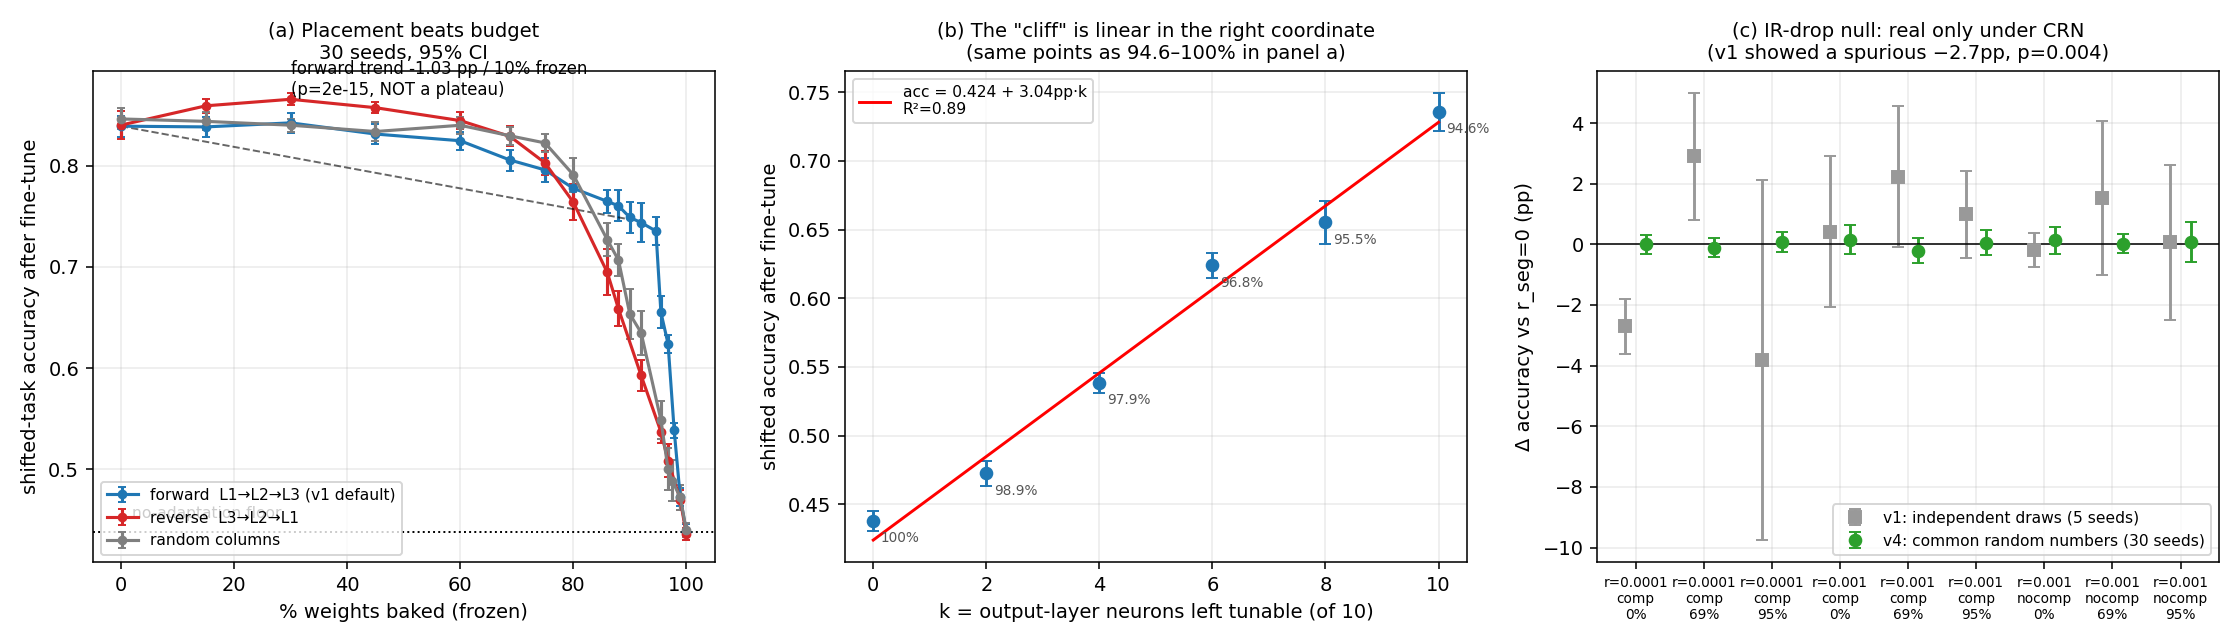

### scaling_multimodal_v8.png
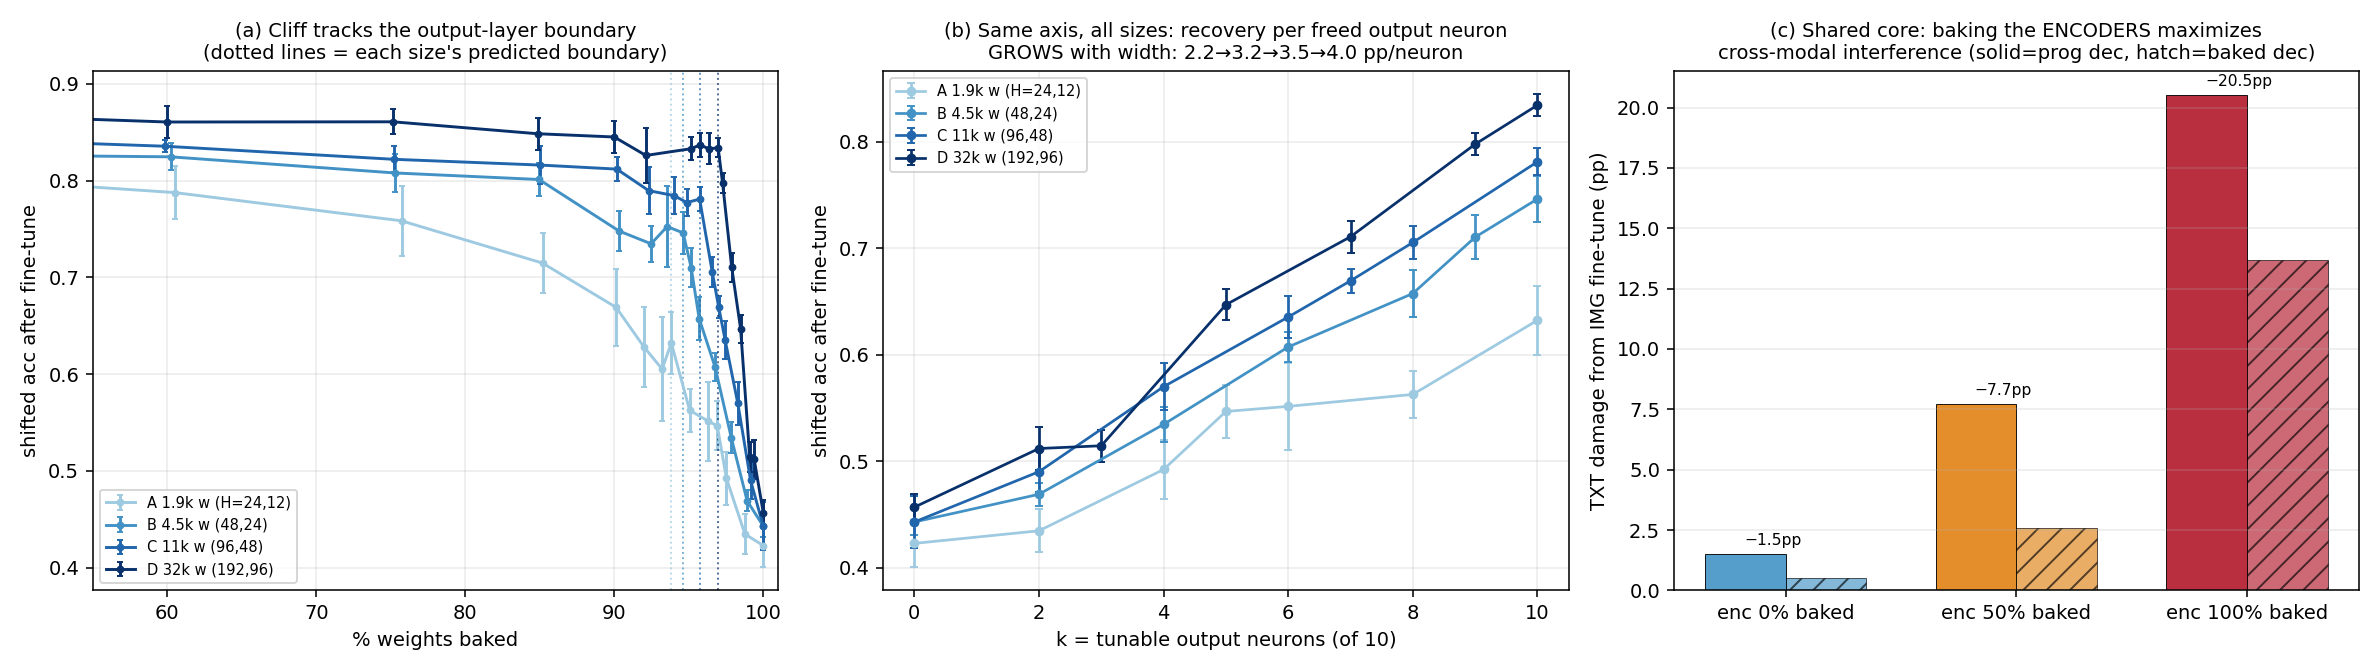